# 🔬 MBDA Assignment 1: EDA and Machine Learning Pipeline
## Dataset: BreastCancerData.csv | Models: XGBoost · Random Forest · SVM · ANN
---
**Pipeline Overview:**
> Data Loading → Quality Check → EDA (Histogram, Box Plot, Violin, Outlier) → Correlation Analysis → Feature Selection (Multicollinearity, model-aware threshold) → ANOVA/MI → Box-Cox Transformation → Post-Transform Distribution → PCA Visualization → Optimal Feature Count (CV) → Preprocessing (SMOTE, model-aware scaling) → Model Training (GPU) → Evaluation → Comparison

**Key Design Decisions:**
- 🌳 For tree-based models (RF, XGBoost): multicollinearity threshold = **0.99**, only drop near-perfectly redundant features; mathematically related features (area ≈ π·r², perimeter ≈ 2π·r) are **kept** as explicit polynomial features  
- 🔵 For SVM and ANN: same threshold (0.99), regularization (C, weight_decay, Dropout) handles residual redundancy  
- 📊 Post-Box-Cox distributions visualized **per class** (Benign vs Malignant) to verify class separability is preserved  
- 📝 Each section includes a rationale explaining **why** the step is performed  
- 🇬🇧 All code and documentation in **English**

## Section 0: Setup, Imports and GPU Detection

In [3]:
import warnings
warnings.filterwarnings('ignore')

# Core
import pandas as pd
import numpy as np
import math, time, copy

# Visualization
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Statistics & Preprocessing
import scipy.stats as stats
from scipy.stats import boxcox
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Imbalanced
from imblearn.over_sampling import SMOTE

# ML Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb

# Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

# Evaluation
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, precision_recall_curve,
    average_precision_score, accuracy_score,
    f1_score, precision_score, recall_score
)

# Optional GPU acceleration for RF/SVM
try:
    import cuml
    from cuml.ensemble import RandomForestClassifier as cuRF
    from cuml.svm import SVC as cuSVC
    CUML_AVAILABLE = True
    print("✅ cuML (RAPIDS GPU) available — RF & SVM will use GPU!")
except ImportError:
    CUML_AVAILABLE = False
    print("⚠️  cuML not available — RF & SVM will use sklearn (CPU)")

# Global style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.max_open_warning': 0,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.35,
    'axes.spines.top': False, 'axes.spines.right': False,
})

COLORS = ['#2ecc71', '#e74c3c']   # Benign=Green, Malignant=Red
SEED   = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print("✅ All imports successful!")

⚠️  cuML not available — RF & SVM will use sklearn (CPU)
✅ All imports successful!


In [4]:
import sys, os, re
import matplotlib.font_manager as fm

# Emoji-capable font detection
# matplotlib renders plot text using system fonts; most default fonts lack emoji
# glyphs. We probe for a known emoji-capable font and add it as a fallback.
_EMOJI_CANDIDATES = {
    'win32' : ['Segoe UI Emoji', 'Segoe UI Symbol'],
    'darwin': ['Apple Color Emoji', 'Arial Unicode MS'],
}
_EMOJI_CANDIDATES['linux'] = ['Noto Color Emoji', 'Noto Emoji',
                               'Twitter Color Emoji', 'Symbola']
_platform  = 'linux' if sys.platform.startswith('linux') else sys.platform
_avail     = {f.name for f in fm.fontManager.ttflist}
EMOJI_FONT = next(
    (f for f in _EMOJI_CANDIDATES.get(_platform, []) if f in _avail), None
)

if EMOJI_FONT:
    # Insert emoji font as glyph-fallback behind the primary sans-serif font.
    # matplotlib 3.3+ performs per-glyph fallback when a character is not in
    # the primary font, so regular Latin text still renders in DejaVu Sans.
    sans = plt.rcParams.get('font.sans-serif', ['DejaVu Sans'])
    if EMOJI_FONT not in sans:
        plt.rcParams['font.sans-serif'] = [sans[0], EMOJI_FONT] + sans[1:]
    print(f"✅ Emoji font configured : {EMOJI_FONT}")
    print(f"   Font stack (sans-serif): {plt.rcParams['font.sans-serif'][:3]}")
else:
    print("⚠️  No emoji font found. Emoji in plot titles may appear as empty boxes.")
    print("   Linux  : sudo apt install fonts-noto-color-emoji && fc-cache -fv")
    print("   Windows: Segoe UI Emoji should already be available.")
    print("   macOS  : Apple Color Emoji should already be available.")

# Helper: safe plot text
_EMOJI_RE = re.compile(
    r'[\U0001F000-\U0001FFFF\U00002600-\U000027BF\U0000FE00-\U0000FEFF]+'
)

def _pe(text: str) -> str:
    """Return text unchanged when emoji font is available, else strip emoji."""
    return text if EMOJI_FONT else _EMOJI_RE.sub('', text).strip(' \u2014|\n')

# Helper: saved models directory
MODELS_DIR = './saved_models'
os.makedirs(MODELS_DIR, exist_ok=True)
print(f"\n✅ Model save directory : {os.path.abspath(MODELS_DIR)}")

✅ Emoji font configured : Segoe UI Emoji
   Font stack (sans-serif): ['Arial', 'Segoe UI Emoji', 'DejaVu Sans']

✅ Model save directory : c:\Users\Sem 6\Multimodal Biomedical Data Analysis\5023231017_Jeremia Christ Immanuel Manalu_Assignment 1_MBDA\saved_models


In [5]:
# GPU Detection
print("=" * 60)
print("🔧  GPU DETECTION & DEVICE SETUP")
print("=" * 60)

CUDA_AVAILABLE = torch.cuda.is_available()
DEVICE         = torch.device('cuda' if CUDA_AVAILABLE else 'cpu')
print(f"PyTorch Device   : {DEVICE}")

if CUDA_AVAILABLE:
    gp = torch.cuda.get_device_properties(0)
    print(f"GPU Model        : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version     : {torch.version.cuda}")
    print(f"VRAM             : {gp.total_memory / 1e9:.2f} GB")
    XGB_DEVICE = 'cuda'
    print("\n✅ XGBoost  → GPU (device='cuda')")
    print("✅ ANN      → GPU (torch CUDA)")
else:
    XGB_DEVICE = 'cpu'
    print("⚠️  CUDA not detected. All models will run on CPU.")

torch.cuda.manual_seed_all(SEED) if CUDA_AVAILABLE else None
print("=" * 60)

🔧  GPU DETECTION & DEVICE SETUP
PyTorch Device   : cuda
GPU Model        : NVIDIA GeForce RTX 4050 Laptop GPU
CUDA Version     : 13.0
VRAM             : 6.44 GB

✅ XGBoost  → GPU (device='cuda')
✅ ANN      → GPU (torch CUDA)


## Section 1: Data Loading and Initial Inspection

In [6]:
FILE_PATH  = 'BreastCancerData (4).csv'
TARGET_COL = 'diagnosis'

df = pd.read_csv(FILE_PATH)

# Drop artefact columns
drop_cols = [c for c in df.columns if 'Unnamed' in str(c)]
if 'id' in df.columns:
    drop_cols.append('id')
if drop_cols:
    df.drop(columns=drop_cols, inplace=True)
    print(f"Dropped columns: {drop_cols}")

print(f"✅ Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head())
df.info()

Dropped columns: ['Unnamed: 32', 'id']
✅ Dataset loaded: 569 rows × 31 columns


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   diagnosis                569 non-null    str    
 1   radius_mean              569 non-null    float64
 2   texture_mean             569 non-null    float64
 3   perimeter_mean           569 non-null    float64
 4   area_mean                569 non-null    float64
 5   smoothness_mean          569 non-null    float64
 6   compactness_mean         569 non-null    float64
 7   concavity_mean           569 non-null    float64
 8   concave points_mean      569 non-null    float64
 9   symmetry_mean            569 non-null    float64
 10  fractal_dimension_mean   569 non-null    float64
 11  radius_se                569 non-null    float64
 12  texture_se               569 non-null    float64
 13  perimeter_se             569 non-null    float64
 14  area_se                  569 non-null

## Section 2: Data Quality Check

In [7]:
print("=" * 60)
print("🔍  DATA QUALITY CHECK")
print("=" * 60)

# Missing values
missing = df.isnull().sum()
print(f"\n[1] Missing values : {missing.sum()} total")
if missing.sum() > 0:
    print(missing[missing > 0])
    df.dropna(inplace=True)
else:
    print("    ✅ No missing values.")

# Duplicates
dupes = df.duplicated().sum()
print(f"[2] Duplicates     : {dupes}", "✅" if dupes == 0 else "→ dropped")
if dupes > 0:
    df.drop_duplicates(inplace=True)

feature_cols = [c for c in df.columns if c != TARGET_COL]
n_features   = len(feature_cols)
print(f"[3] Feature count  : {n_features}")

# Min values per feature (important for Box-Cox feasibility check later)
min_vals      = df[feature_cols].min()
zero_feats    = min_vals[min_vals == 0].index.tolist()
near_zero     = min_vals[(min_vals >= 0) & (min_vals < 1e-4)].index.tolist()
print(f"[4] Features with exact 0  : {zero_feats if zero_feats else 'None ✅'}")
print(f"    Features with value < 1e-4: {len(near_zero)} features")
print("    → Epsilon shift will be applied automatically during Box-Cox")

print("\n📋 Descriptive Statistics:")
display(df.describe().T.style
    .background_gradient(cmap='Blues', subset=['mean', 'std'])
    .format(precision=4)
)

🔍  DATA QUALITY CHECK

[1] Missing values : 0 total
    ✅ No missing values.
[2] Duplicates     : 0 ✅
[3] Feature count  : 30
[4] Features with exact 0  : ['concavity_mean', 'concave points_mean', 'concavity_se', 'concave points_se', 'concavity_worst', 'concave points_worst']
    Features with value < 1e-4: 6 features
    → Epsilon shift will be applied automatically during Box-Cox

📋 Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0000,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100
texture_mean,569.0000,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800
perimeter_mean,569.0000,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000
area_mean,569.0000,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000
smoothness_mean,569.0000,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634
compactness_mean,569.0000,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454
concavity_mean,569.0000,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268
concave points_mean,569.0000,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012
symmetry_mean,569.0000,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040
fractal_dimension_mean,569.0000,0.0628,0.0071,0.0500,0.0577,0.0615,0.0661,0.0974


## Section 3: Class Distribution Analysis

Benign (B)     : 357
Malignant (M)  : 212
Imbalance Ratio: 1.68x  → SMOTE recommended


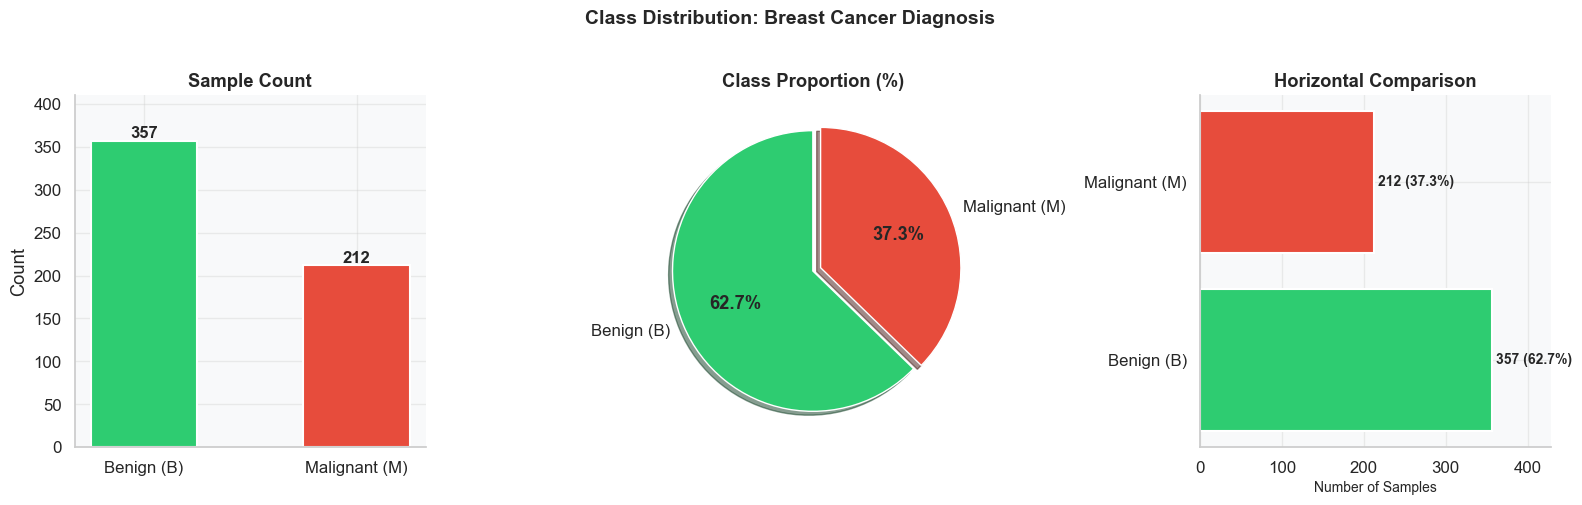

In [8]:
label_counts = df[TARGET_COL].value_counts().sort_index()
ir = label_counts.max() / label_counts.min()
print(f"Benign (B)     : {label_counts.get('B', 0)}")
print(f"Malignant (M)  : {label_counts.get('M', 0)}")
print(f"Imbalance Ratio: {ir:.2f}x  → {'SMOTE recommended' if ir > 1.5 else 'Acceptably balanced'}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Class Distribution: Breast Cancer Diagnosis",
             fontsize=14, fontweight='bold', y=1.01)

# Count bar
bars = axes[0].bar(['Benign (B)', 'Malignant (M)'],
                   label_counts.values, color=COLORS,
                   edgecolor='white', linewidth=1.5, width=0.5)
axes[0].set_title('Sample Count', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, v in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 3, str(v),
                 ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, label_counts.max() * 1.15)

# Pie
wedges, texts, autotexts = axes[1].pie(
    label_counts.values,
    labels=['Benign (B)', 'Malignant (M)'],
    autopct='%1.1f%%', colors=COLORS,
    startangle=90, explode=(0, 0.06), shadow=True)
[at.set_fontweight('bold') for at in autotexts]
axes[1].set_title('Class Proportion (%)', fontweight='bold')

# Horizontal bar
axes[2].barh(['Benign (B)', 'Malignant (M)'],
             label_counts.values, color=COLORS,
             edgecolor='white', linewidth=1.5)
for i, v in enumerate(label_counts.values):
    axes[2].text(v + 5, i, f'{v} ({v/len(df)*100:.1f}%)',
                 va='center', fontweight='bold', fontsize=10)
axes[2].set_xlabel('Count')
axes[2].set_title('Horizontal Comparison', fontweight='bold')
axes[2].set_xlabel('Number of Samples', fontsize=10)
axes[2].set_xlim(0, label_counts.max() * 1.2)

plt.tight_layout()
plt.show()

## Section 4: Feature Distribution (Histogram + KDE by Class)

**Why this visualization?**  
Each feature is visualized as an overlapping histogram with KDE curves, one per class (Benign vs Malignant).  
This reveals two key properties:
- **Separability**: how well a feature discriminates between the two classes. Wide gap between peaks → strong predictor.
- **Distribution shape**: right-skewed, multi-modal, or approximately Gaussian, informs which transformation is appropriate later (Box-Cox).

Features where Benign and Malignant KDE peaks overlap heavily are weaker predictors (linear sense). However, even those can carry non-linear discriminative power detectable by XGBoost, RF, and ANN.

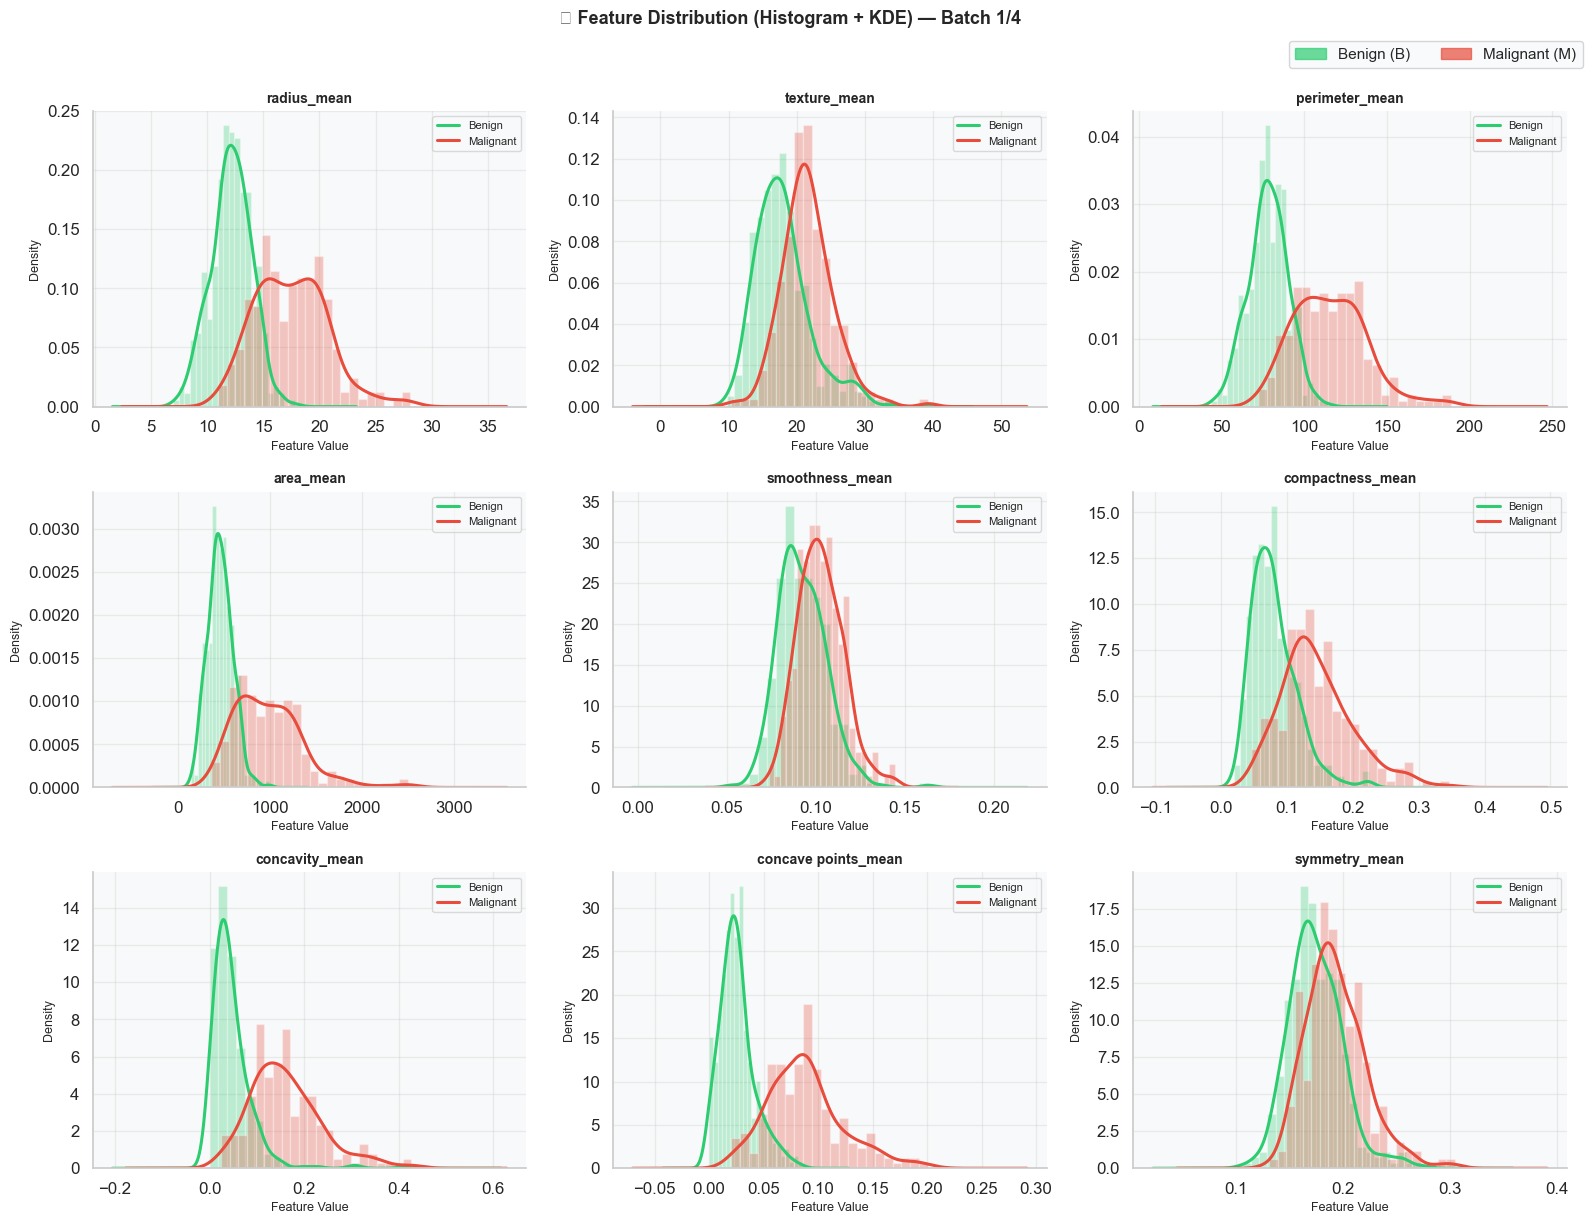

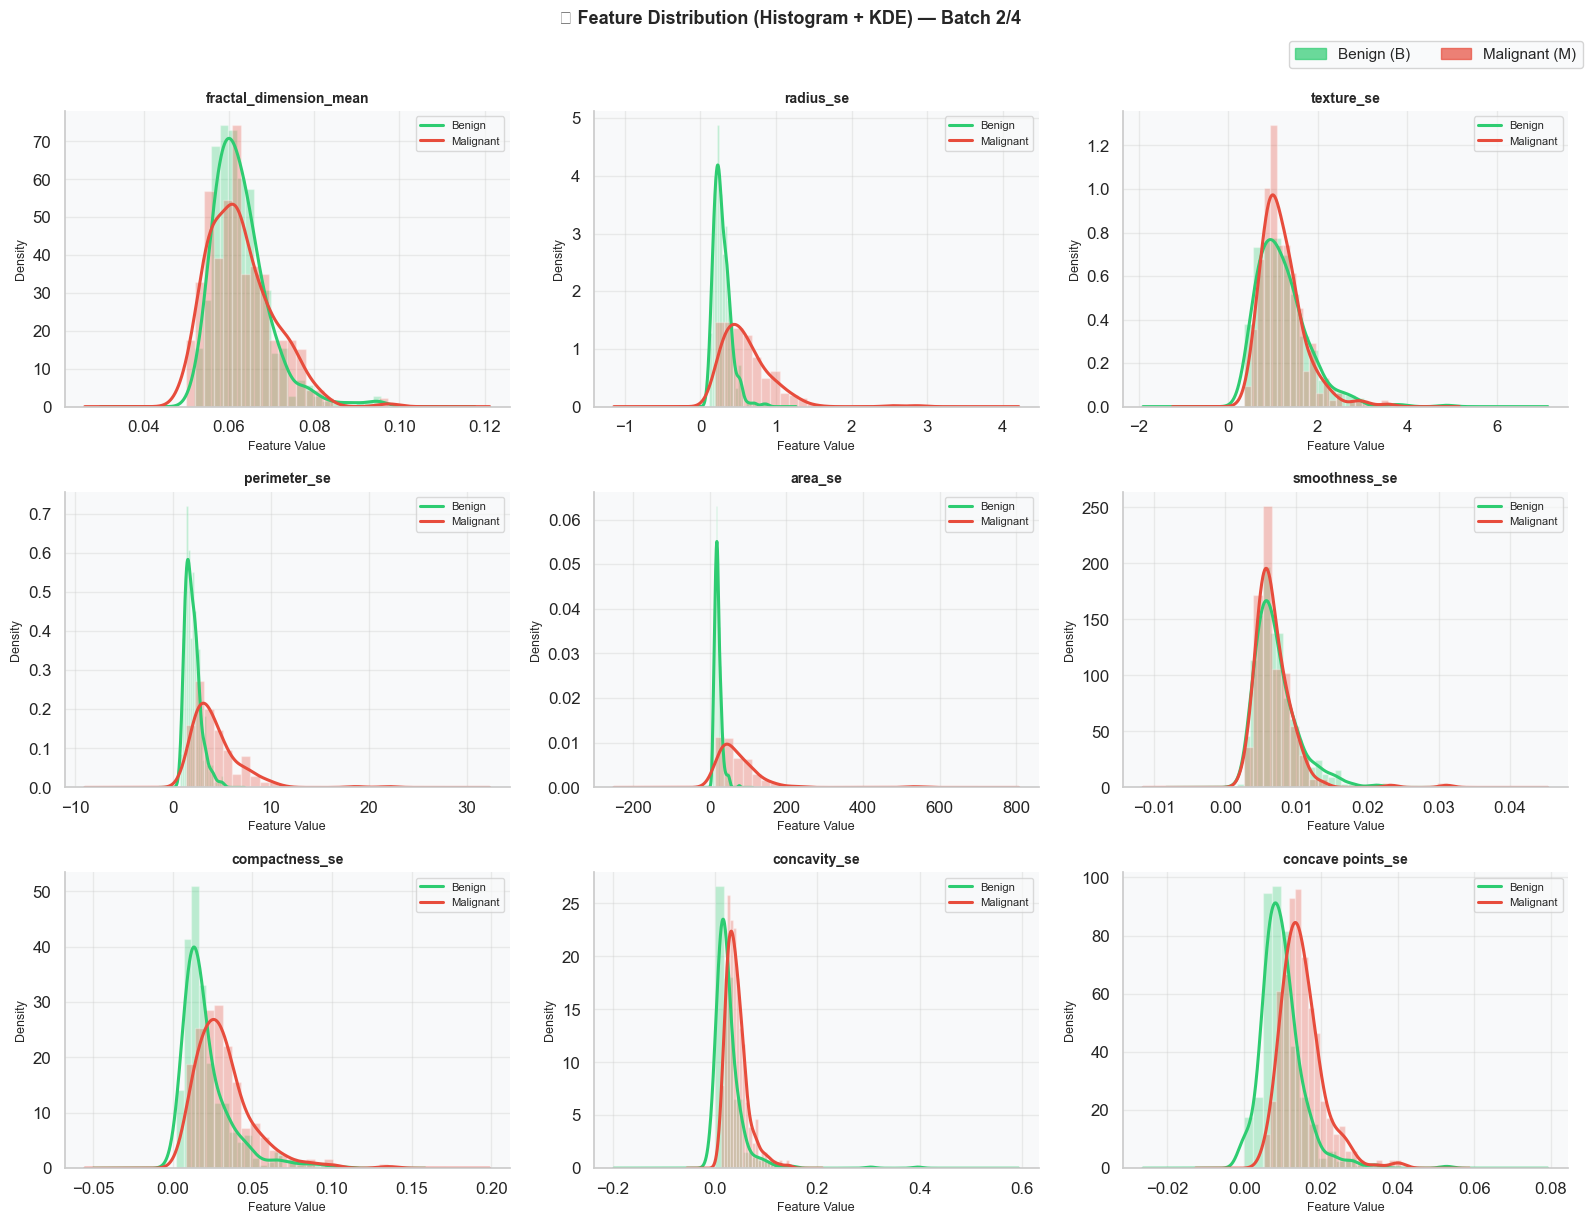

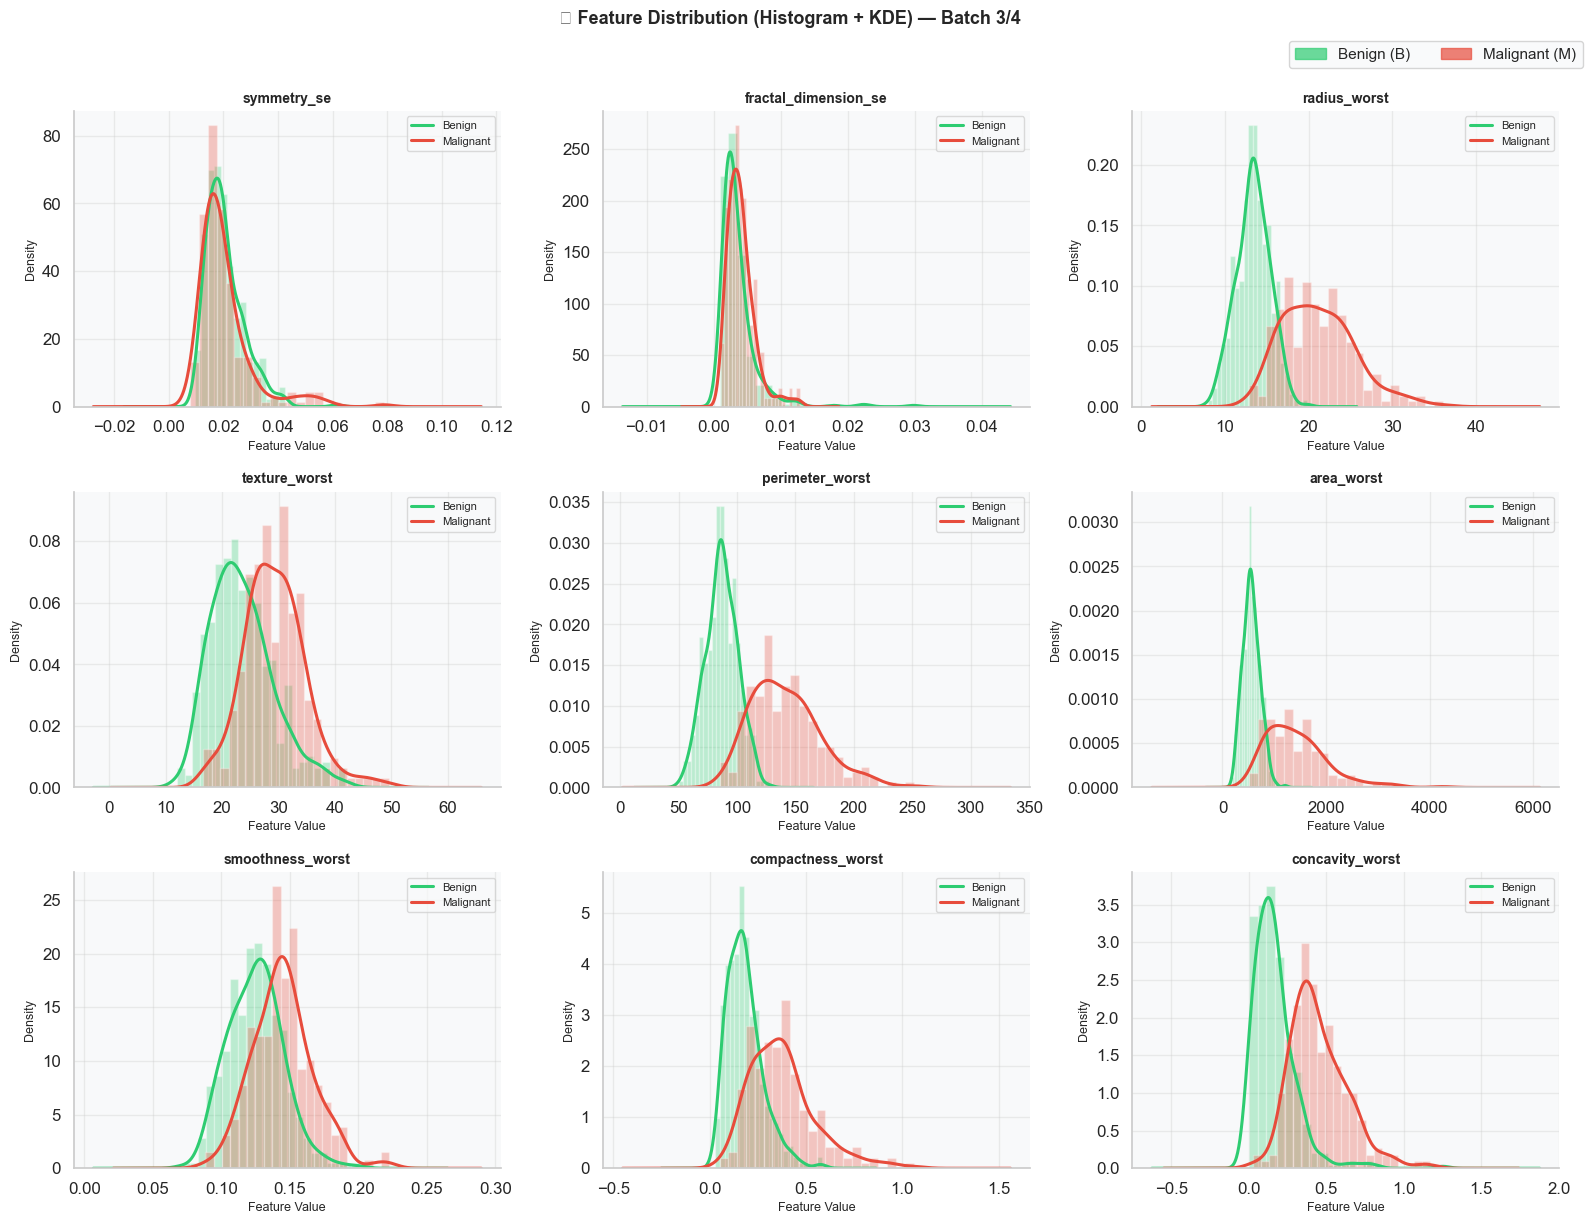

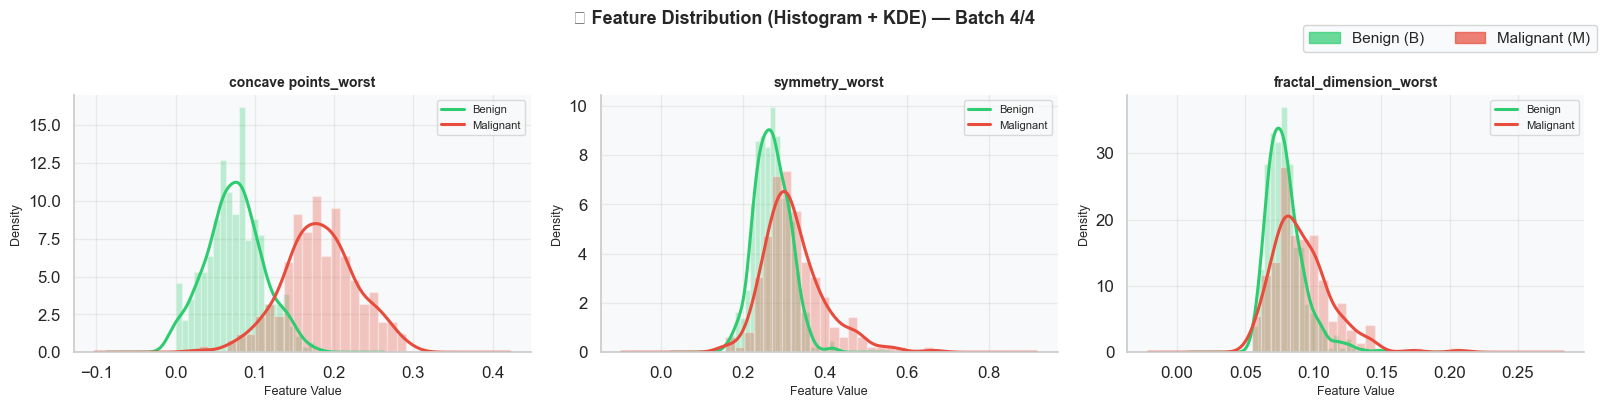

✅ Histogram + KDE plots complete.


In [9]:
batch_size = 9
n_batches  = math.ceil(n_features / batch_size)

for bi in range(n_batches):
    batch = feature_cols[bi * batch_size : (bi + 1) * batch_size]
    nr    = math.ceil(len(batch) / 3)
    fig, axes = plt.subplots(nr, 3, figsize=(16, nr * 4))
    axes = np.array(axes).flatten()

    for j, feat in enumerate(batch):
        ax = axes[j]
        for cls, col, lbl in zip(['B','M'], COLORS, ['Benign','Malignant']):
            sub = df[df[TARGET_COL] == cls][feat]
            ax.hist(sub, bins=22, density=True, alpha=0.30,
                    color=col, edgecolor='white')
            sub.plot.kde(ax=ax, color=col, linewidth=2.2, label=lbl)
        ax.set_title(feat, fontsize=10, fontweight='bold')
        ax.set_xlabel('Feature Value', fontsize=9)
        ax.set_ylabel('Density', fontsize=9)
        ax.legend(fontsize=8, framealpha=0.7)

    for k in range(len(batch), len(axes)):
        fig.delaxes(axes[k])

    patches = [mpatches.Patch(color=COLORS[0], alpha=0.7, label='Benign (B)'),
               mpatches.Patch(color=COLORS[1], alpha=0.7, label='Malignant (M)')]
    fig.legend(handles=patches, loc='upper right', ncol=2, fontsize=11,
               framealpha=0.8, bbox_to_anchor=(1.0, 1.0))
    fig.suptitle(f"📊 Feature Distribution (Histogram + KDE) — Batch {bi+1}/{n_batches}",
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

print("✅ Histogram + KDE plots complete.")

## Section 5: Box Plot Analysis (by Class, with Jitter)

**Why Box Plots?**  
Box plots compactly show the median, IQR (Q1–Q3), whiskers (1.5×IQR), and outlier points for each class.  
Overlaid jitter (scattered individual points) prevents the box from hiding the actual data density.  
The **notch** represents a 95% confidence interval around the median, if two notches do not overlap, the medians are significantly different.

**What to look for:**  
- Non-overlapping boxes → strong class discriminator  
- Many outlier points (hollow circles beyond whiskers) → high-outlier features that will benefit from Box-Cox transformation

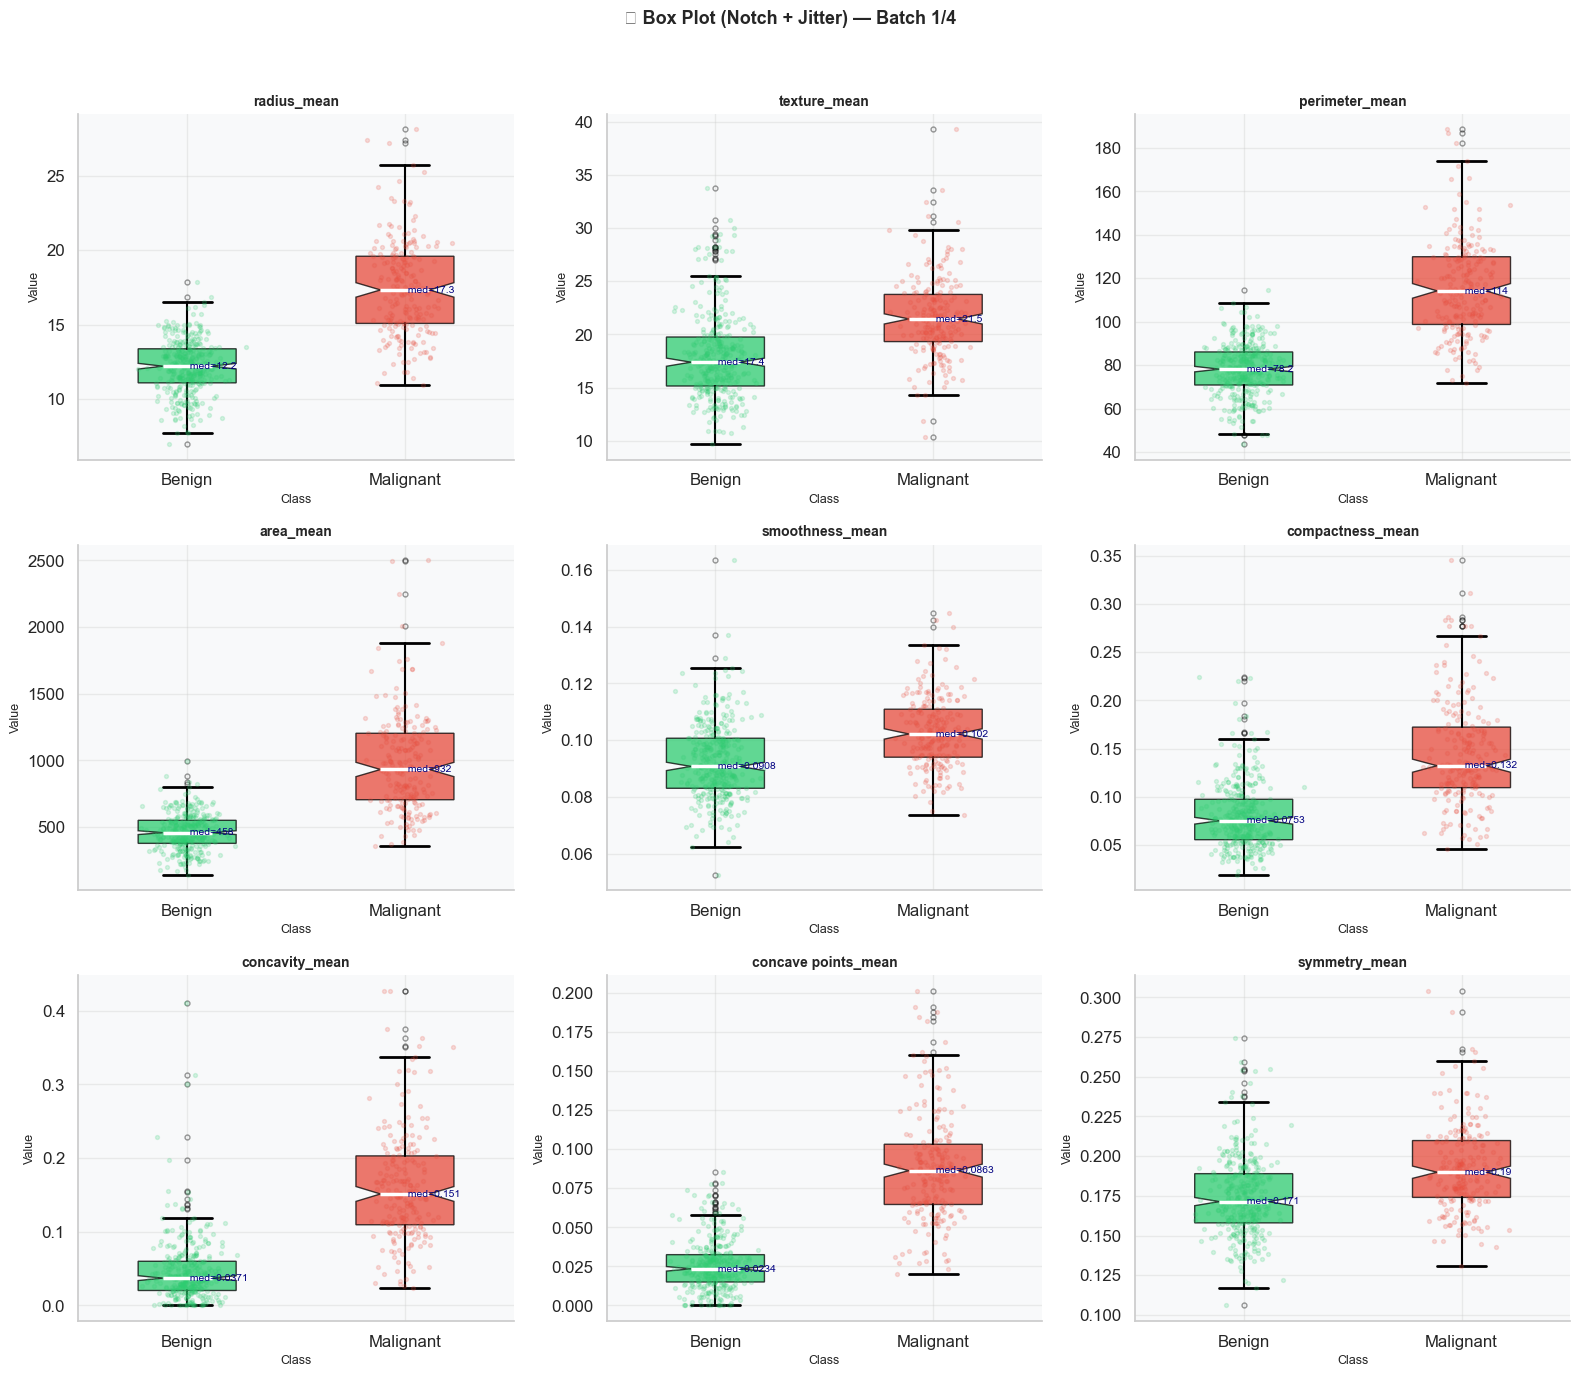

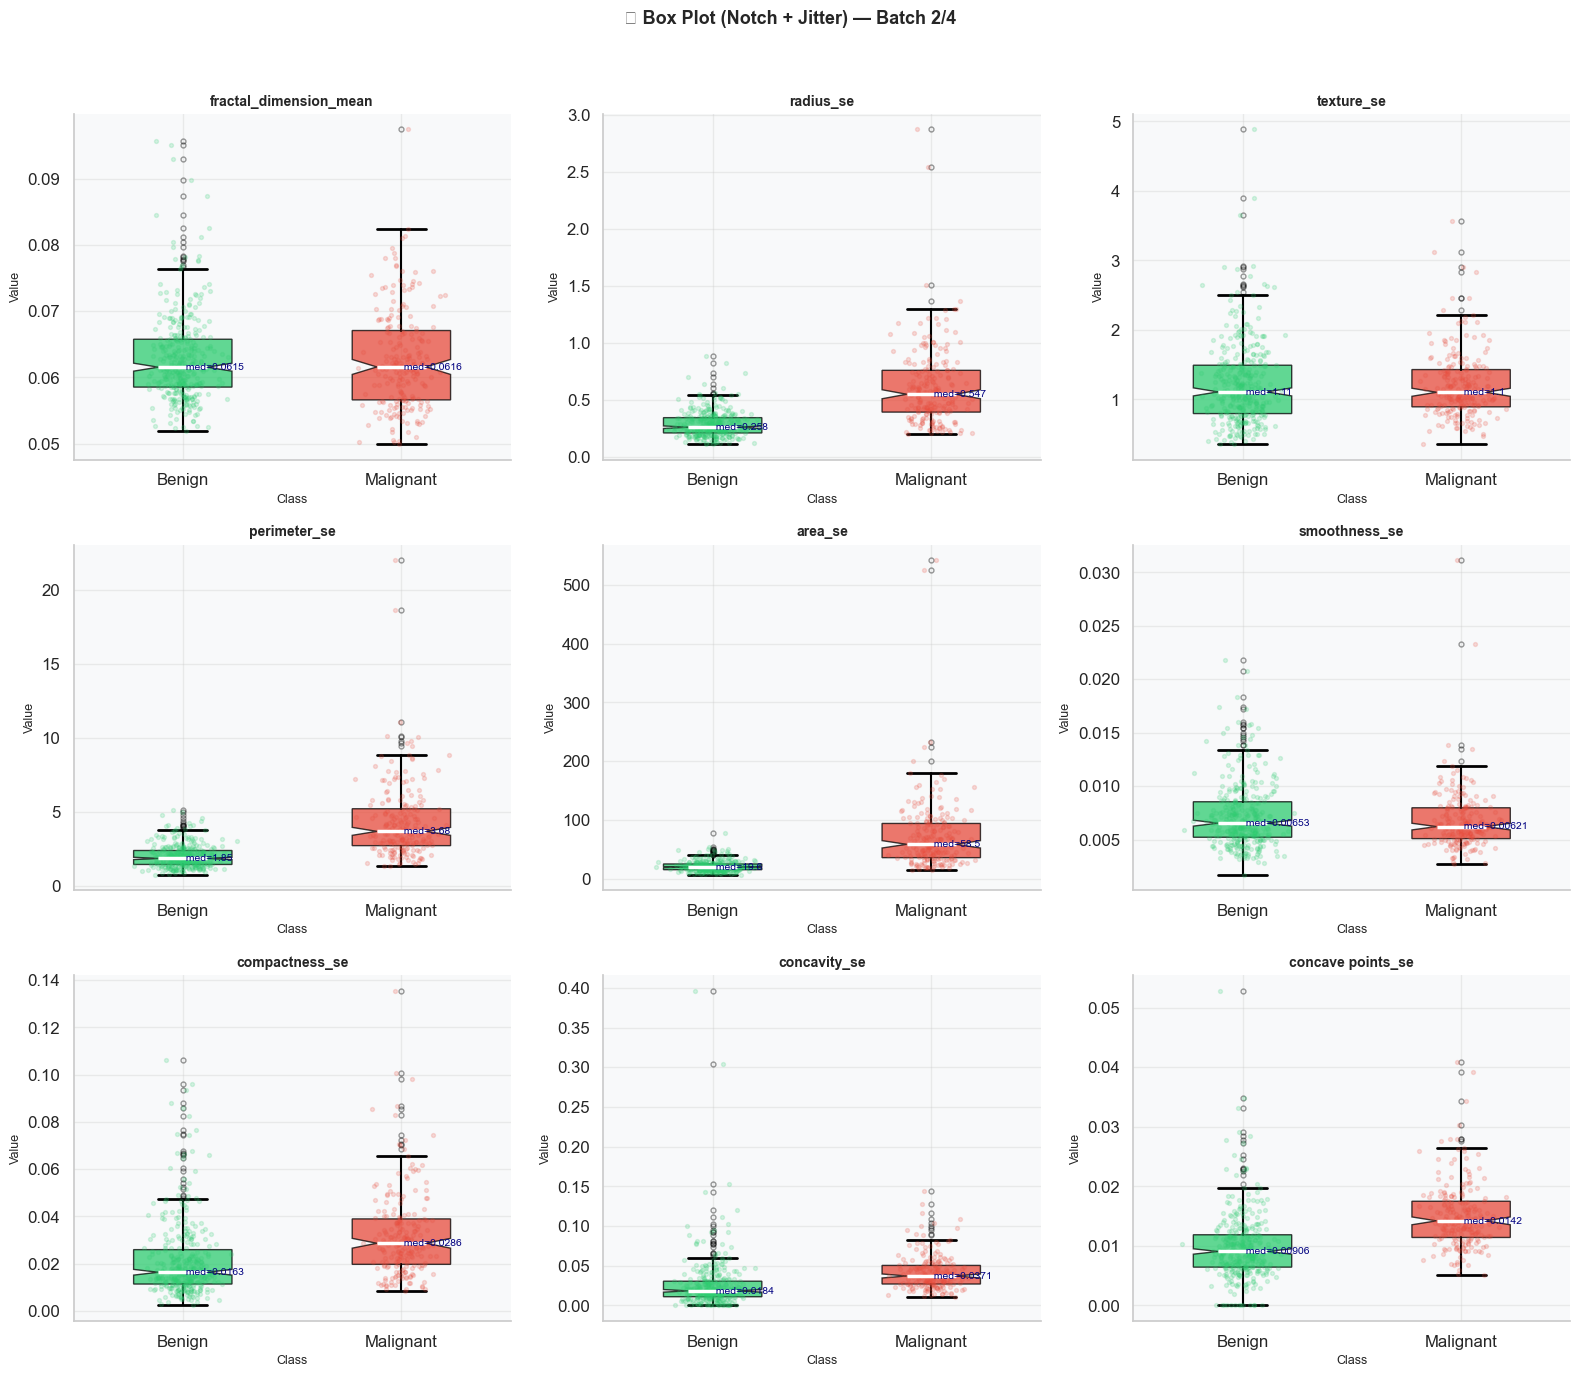

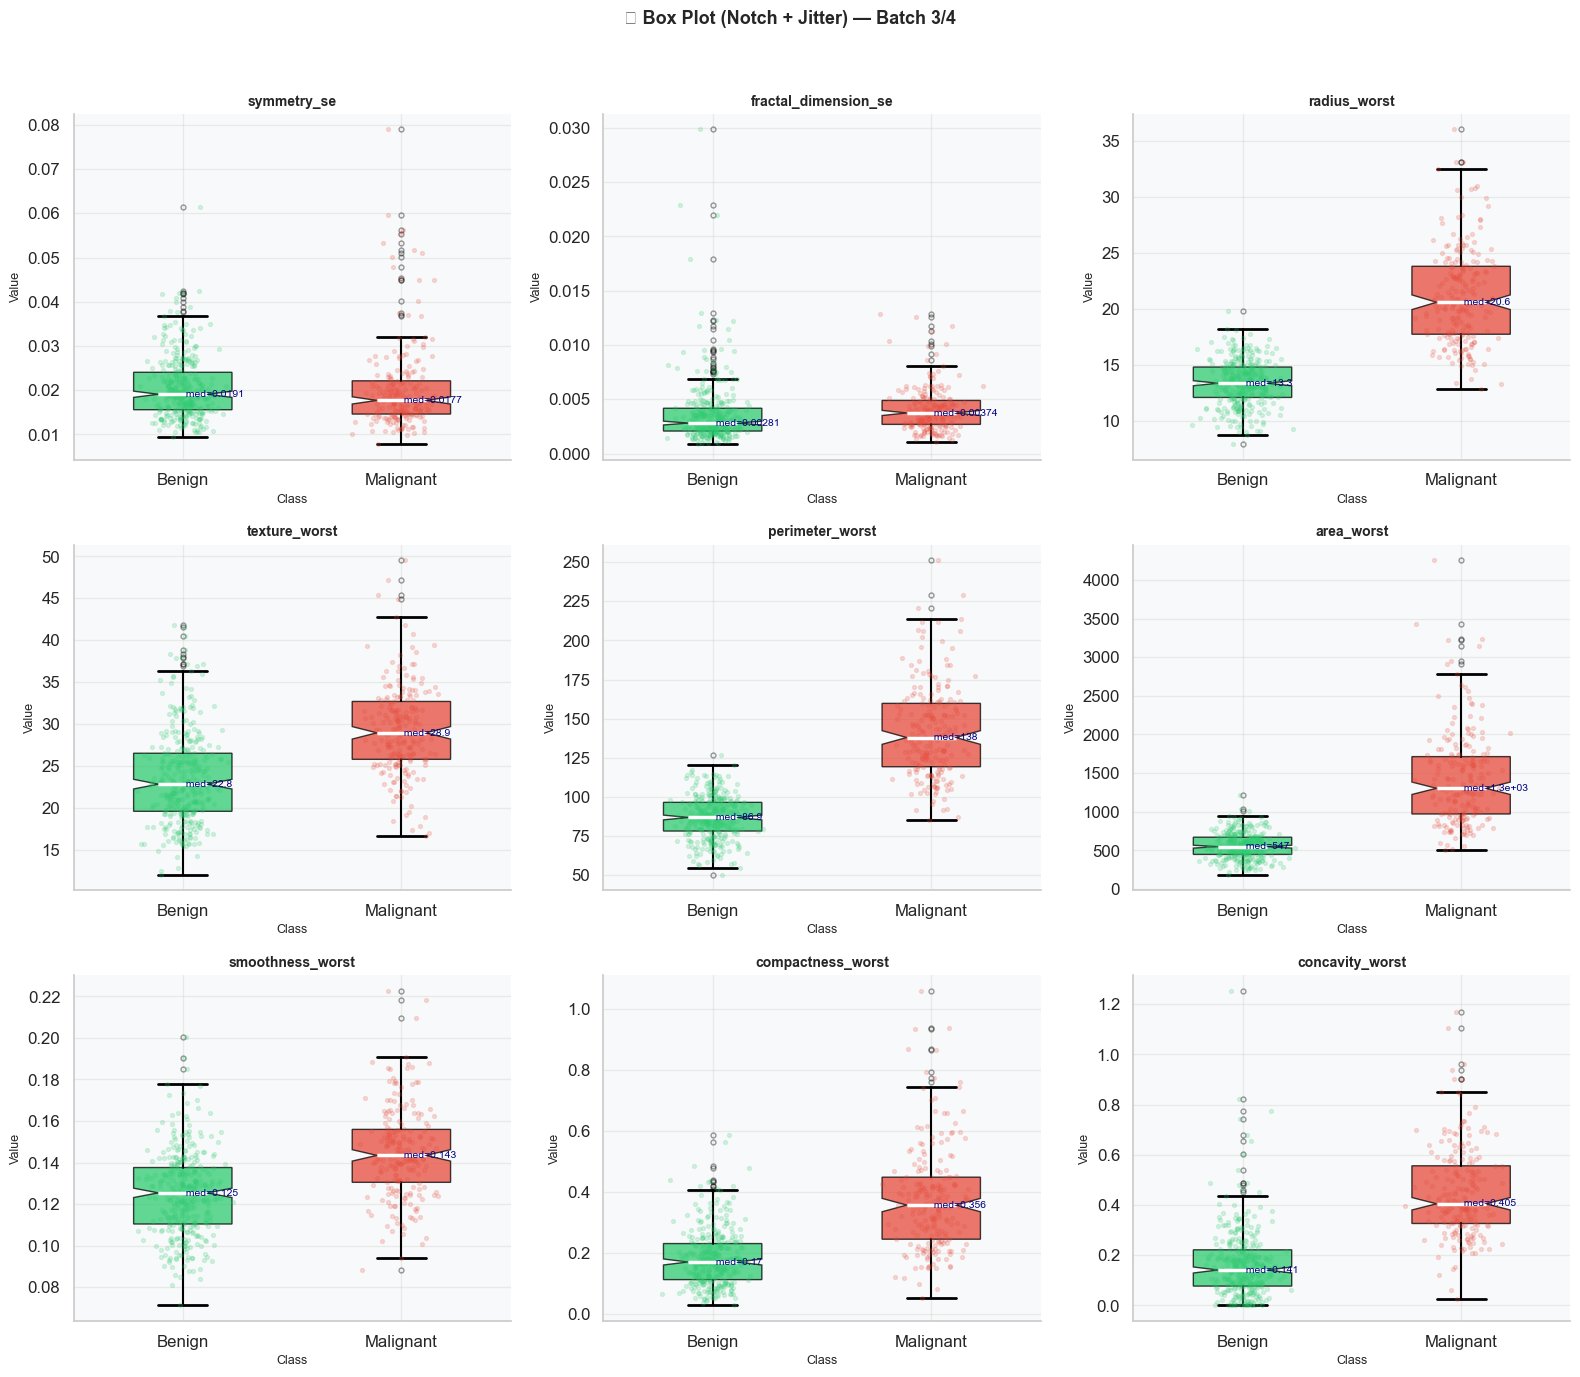

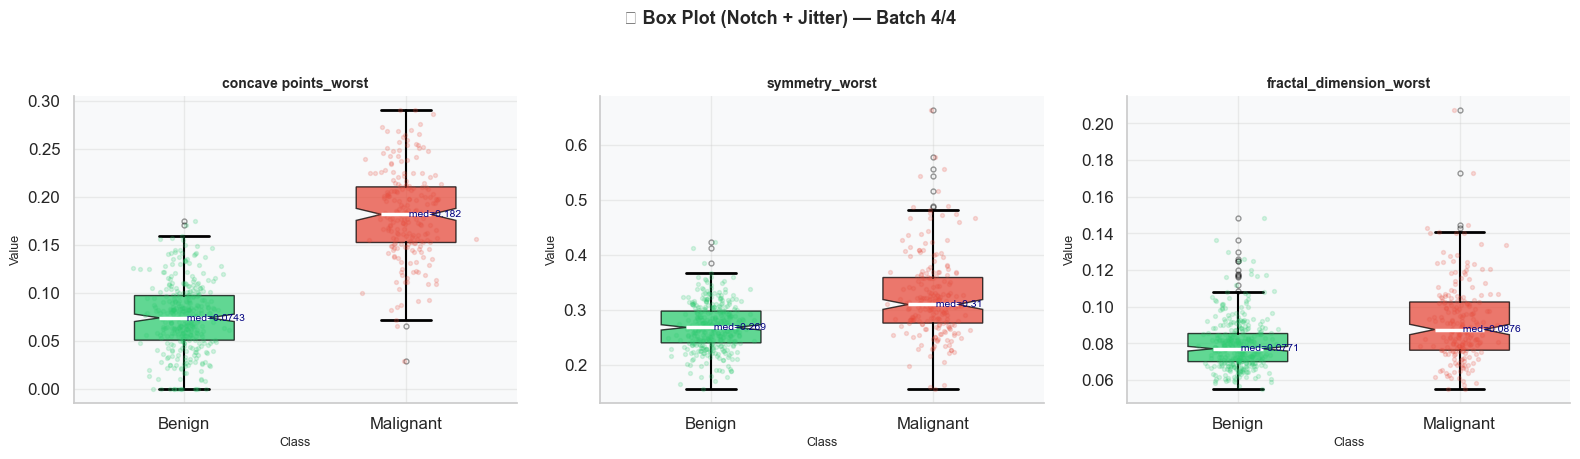

✅ Box plots complete.


In [10]:
for bi in range(n_batches):
    batch = feature_cols[bi * batch_size : (bi + 1) * batch_size]
    nr    = math.ceil(len(batch) / 3)
    fig, axes = plt.subplots(nr, 3, figsize=(16, nr * 4.5))
    axes = np.array(axes).flatten()

    for j, feat in enumerate(batch):
        ax    = axes[j]
        dB    = df[df[TARGET_COL] == 'B'][feat]
        dM    = df[df[TARGET_COL] == 'M'][feat]
        bp    = ax.boxplot(
            [dB, dM], labels=['Benign', 'Malignant'],
            patch_artist=True, notch=True, widths=0.45,
            medianprops=dict(color='white', linewidth=2.5),
            flierprops=dict(marker='o', markersize=3.5, alpha=0.40),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=2)
        )
        for patch, c in zip(bp['boxes'], COLORS):
            patch.set_facecolor(c); patch.set_alpha(0.75)
        for xi, (sub, c) in enumerate([(dB, COLORS[0]), (dM, COLORS[1])], 1):
            jitter = np.random.normal(xi, 0.07, size=len(sub))
            ax.scatter(jitter, sub, alpha=0.18, s=8, color=c, zorder=2)
            ax.text(xi, sub.median(),
                    f' med={sub.median():.3g}',
                    ha='left', va='center', fontsize=7.5, color='navy')
        ax.set_title(feat, fontsize=10, fontweight='bold')
        ax.set_xlabel('Class', fontsize=9)
        ax.set_ylabel('Value', fontsize=9)

    for k in range(len(batch), len(axes)):
        fig.delaxes(axes[k])

    fig.suptitle(f"📦 Box Plot (Notch + Jitter) — Batch {bi+1}/{n_batches}",
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show(); plt.close(fig)

print("✅ Box plots complete.")

## Section 6: Violin Plot Analysis (by Class)

**Why Violin Plots over Box Plots?**  
A violin plot adds Kernel Density Estimation (KDE) to the box plot summary. The **width** of the violin at any given value represents the **density of data** at that point.  

Key advantages over box plots:
- Reveals **bimodal distributions** (two peaks), a box plot would mask this entirely
- Shows whether data is concentrated near the median (thin waist) or spread out (thick body)
- The embedded mini box plot (inner='box') still shows quartile information

**What this means for your models:**  
Features with a bimodal distribution in one class (e.g., Malignant) indicate two distinct sub-populations within that class, tree-based models can leverage this through multiple split levels.

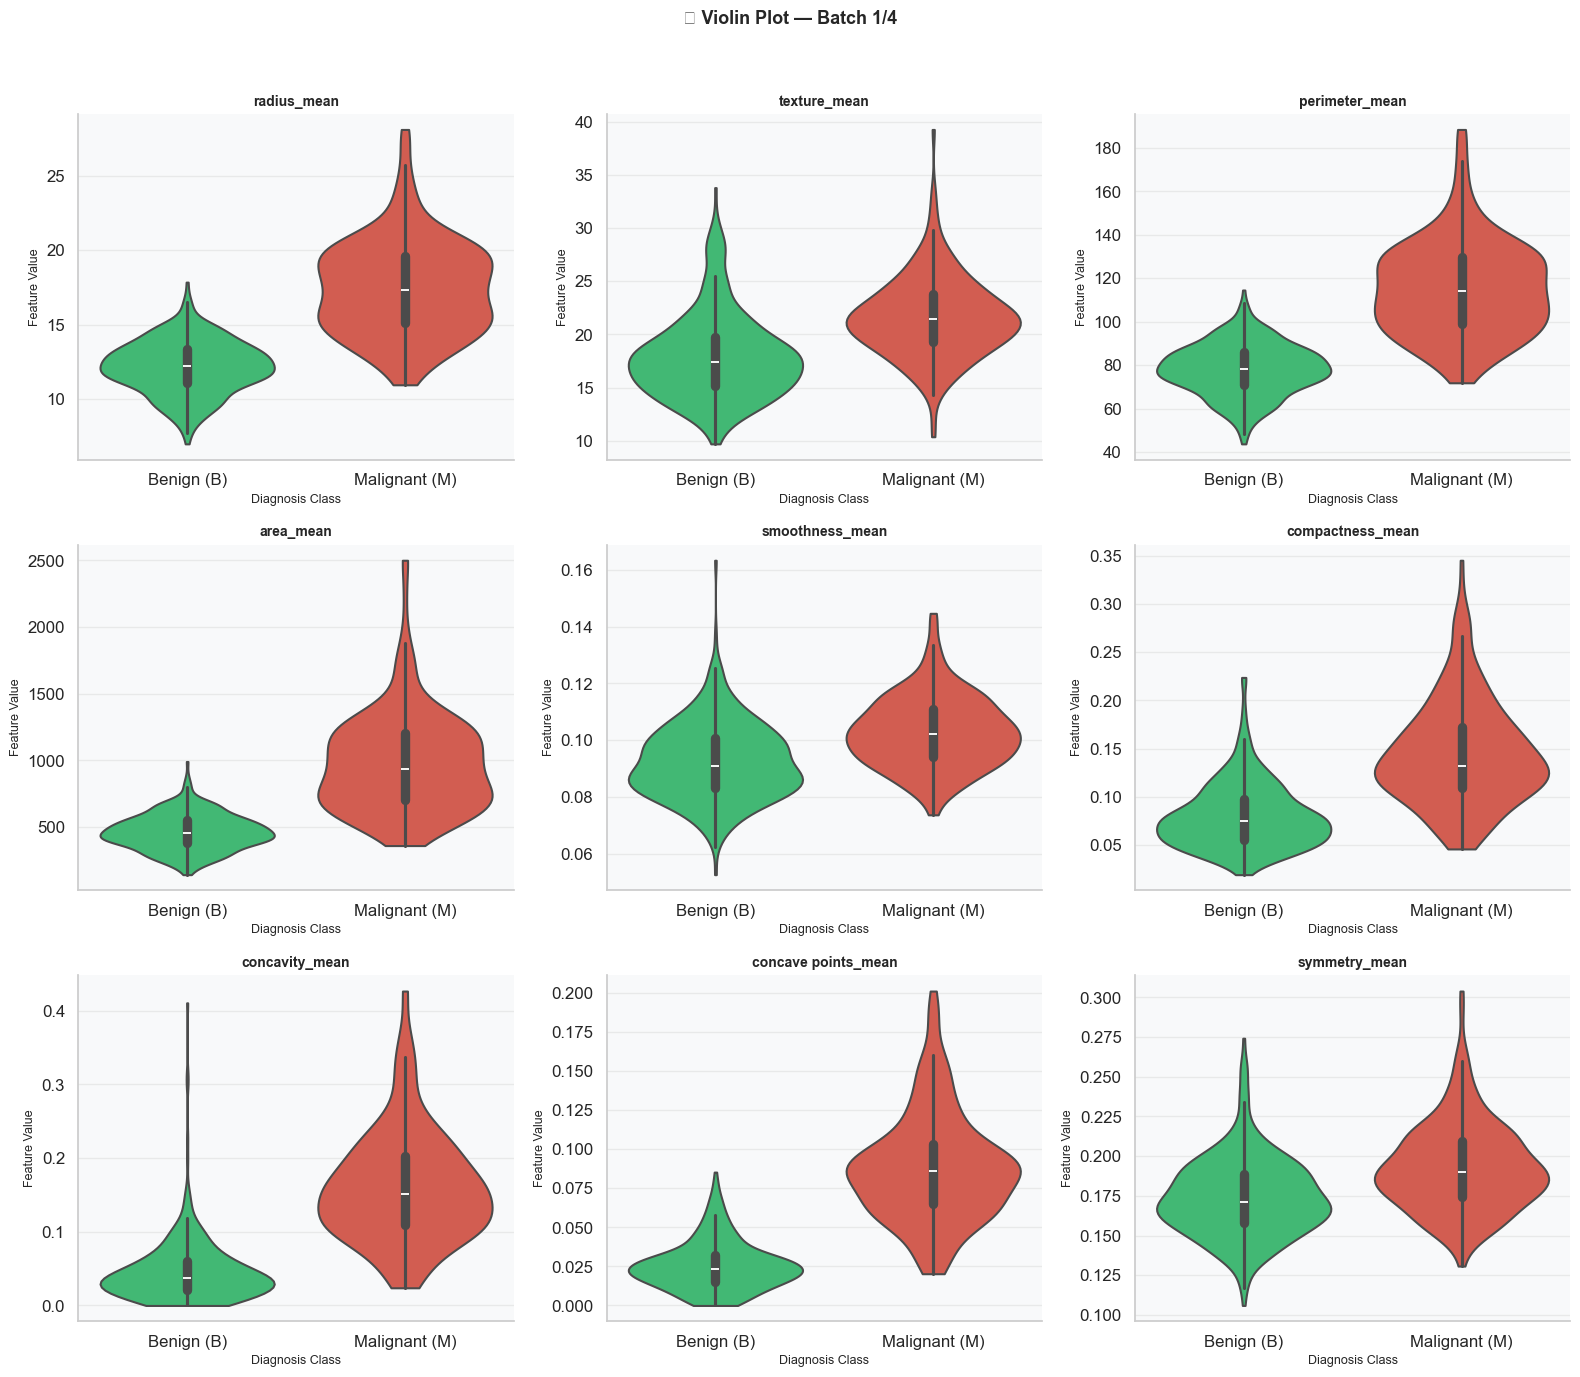

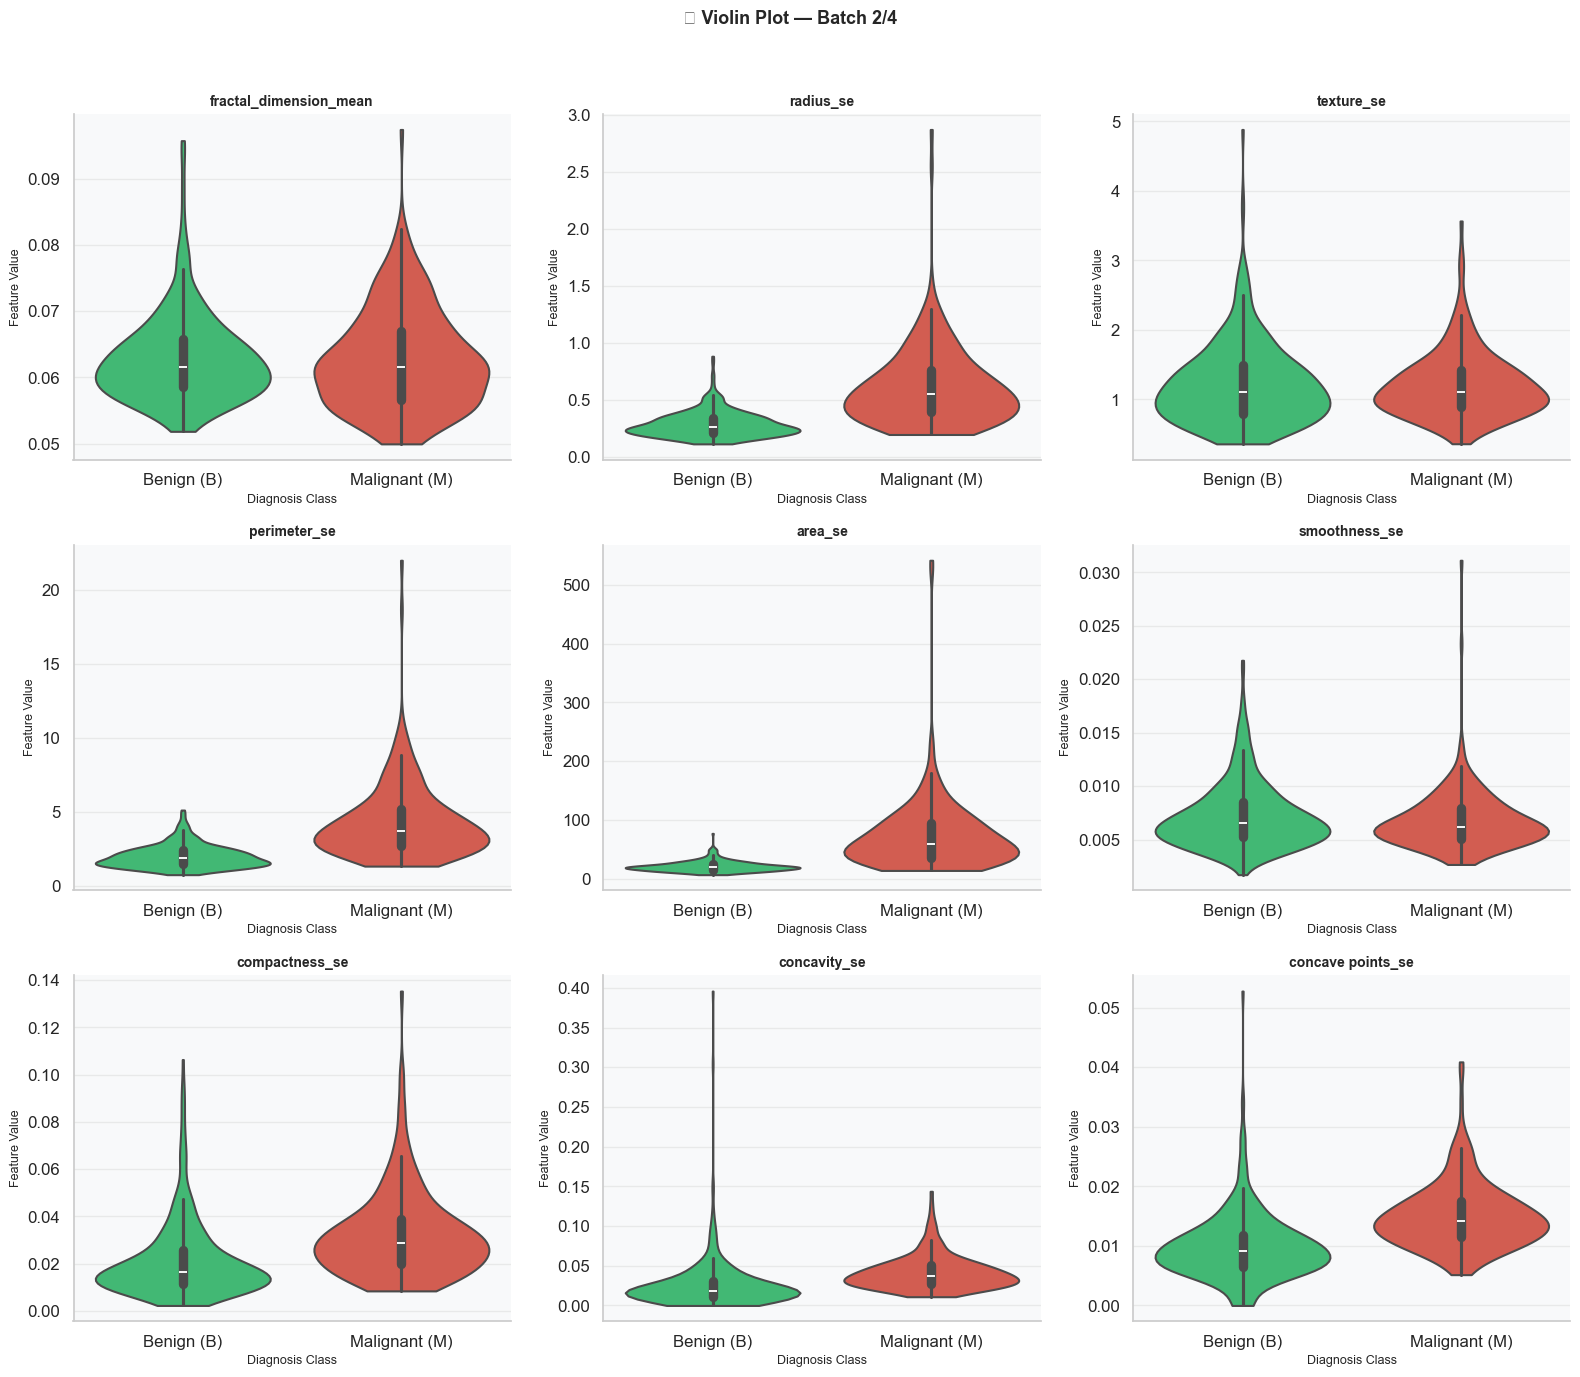

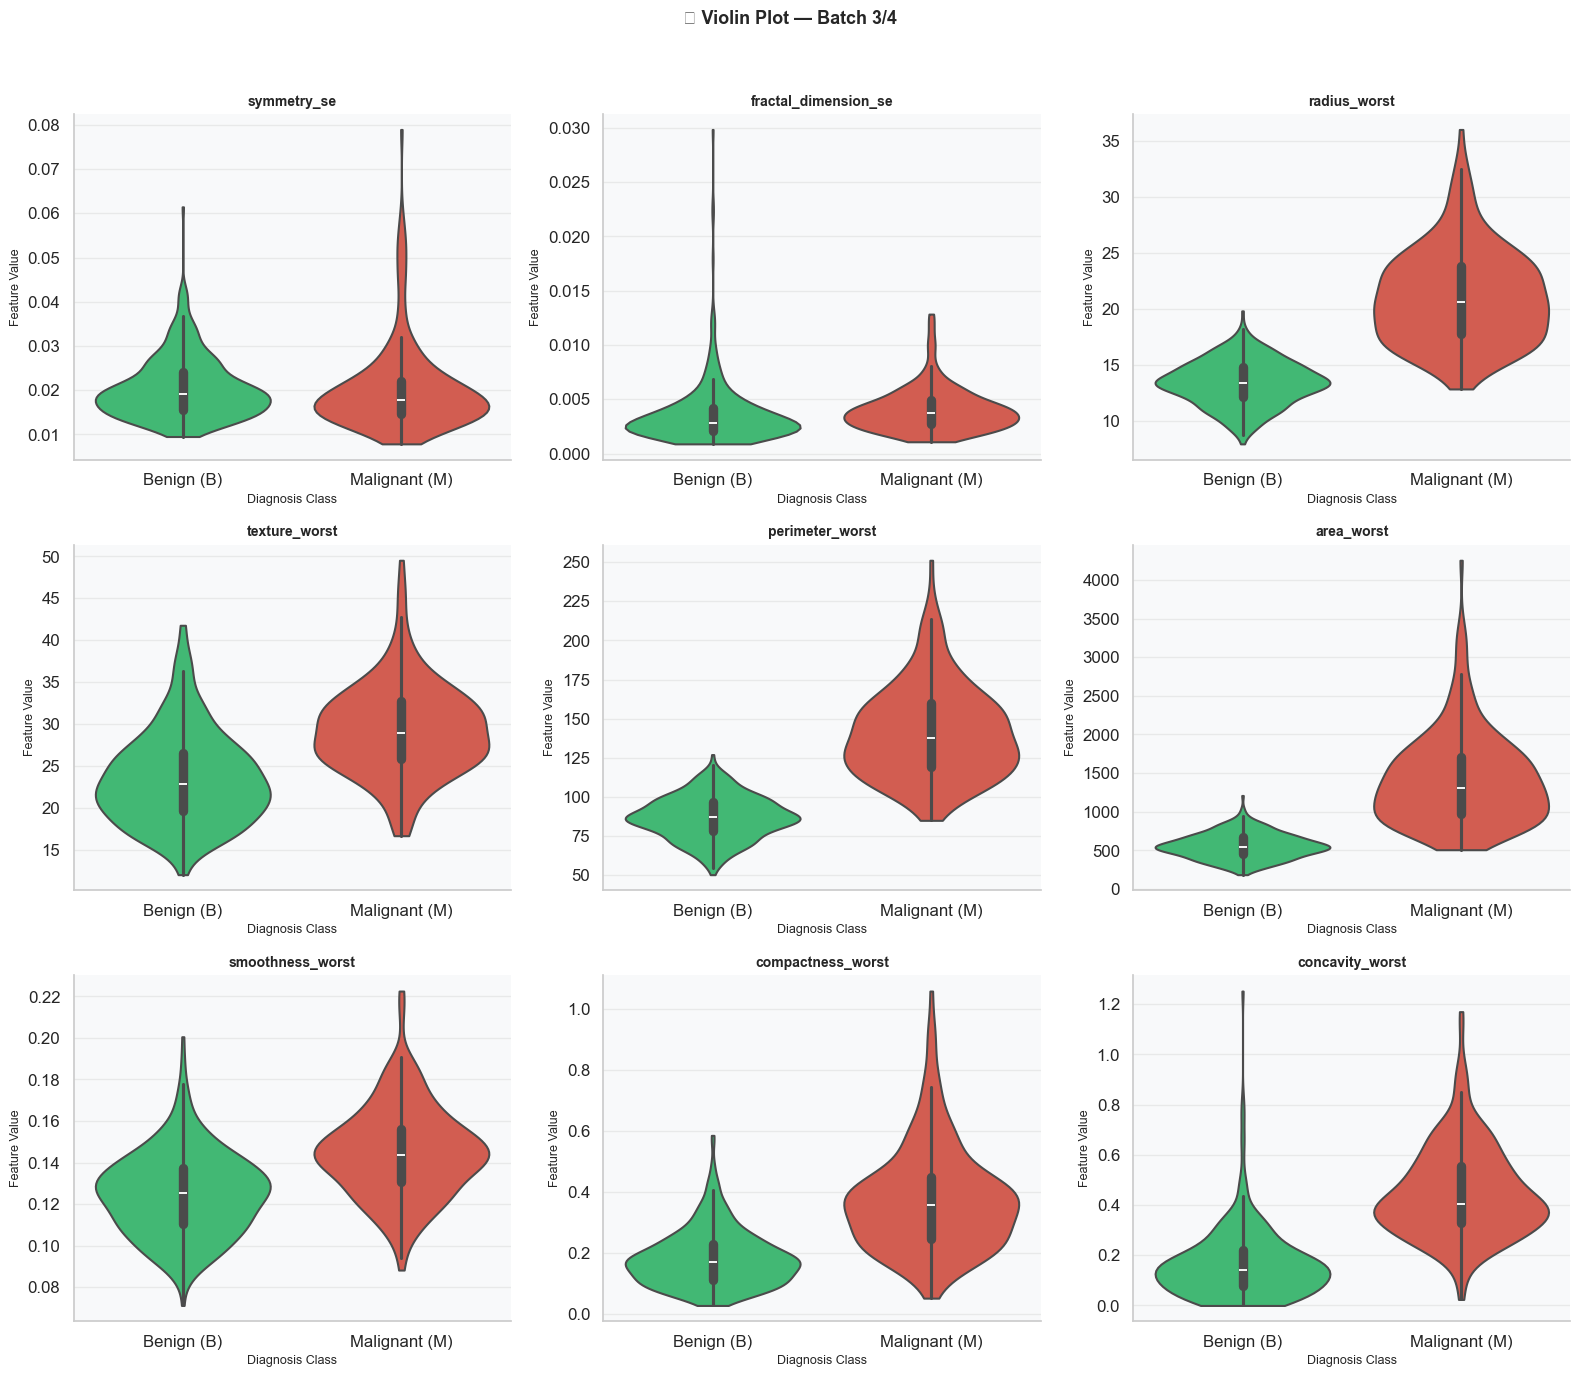

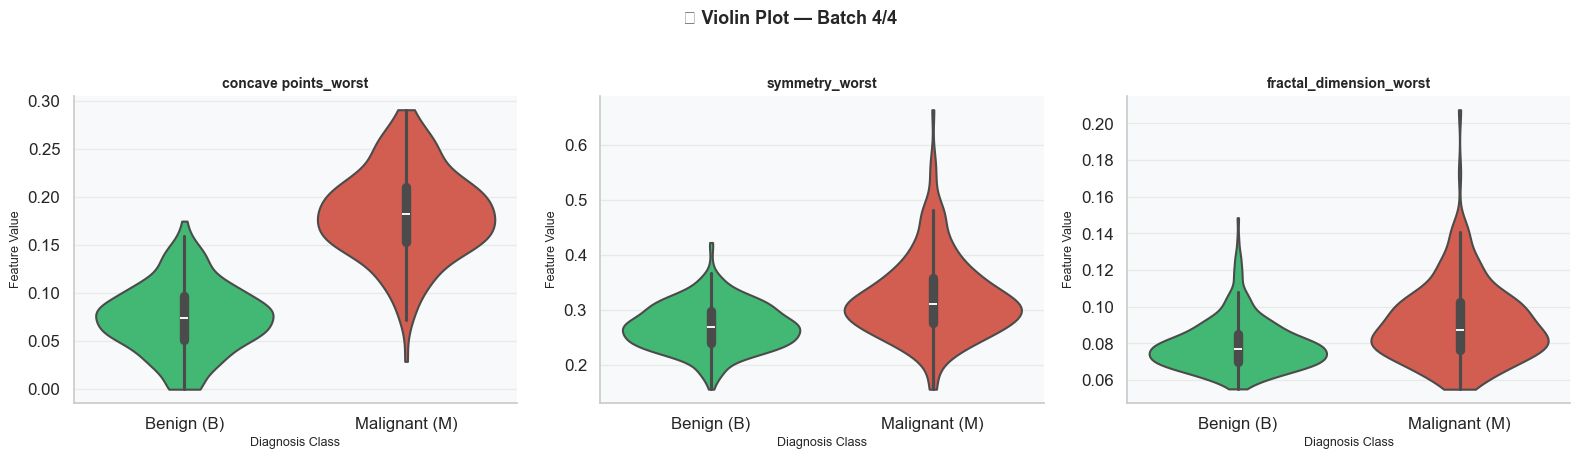

✅ Violin plots complete.


In [11]:
for bi in range(n_batches):
    batch = feature_cols[bi * batch_size : (bi + 1) * batch_size]
    nr    = math.ceil(len(batch) / 3)
    fig, axes = plt.subplots(nr, 3, figsize=(16, nr * 4.5))
    axes = np.array(axes).flatten()

    for j, feat in enumerate(batch):
        sns.violinplot(
            data=df[[TARGET_COL, feat]], x=TARGET_COL, y=feat,
            palette={'B': COLORS[0], 'M': COLORS[1]},
            inner='box', cut=0, linewidth=1.5,
            ax=axes[j], order=['B', 'M']
        )
        axes[j].set_xticklabels(['Benign (B)', 'Malignant (M)'])
        axes[j].set_title(feat, fontsize=10, fontweight='bold')
        axes[j].set_xlabel('Diagnosis Class', fontsize=9)
        axes[j].set_ylabel('Feature Value', fontsize=9)

    for k in range(len(batch), len(axes)):
        fig.delaxes(axes[k])

    fig.suptitle(f"🎻 Violin Plot — Batch {bi+1}/{n_batches}",
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show(); plt.close(fig)

print("✅ Violin plots complete.")

## Section 7: Outlier Detection (IQR Method)

**Why detect outliers?**  
High outlier rates confirm that features are right-skewed with extreme values. This directly justifies applying Box-Cox transformation in Section 11.  
Outliers are **not removed** from the dataset here; instead, the transformation will compress them toward the main distribution.  

The IQR rule flags any point beyond Q1 − 1.5·IQR or Q3 + 1.5·IQR as an outlier.

Top 12 features by outlier count:


,Feature,N_Outlier,Pct (%)
13,area_se,65,11.42%
10,radius_se,38,6.68%
12,perimeter_se,38,6.68%
23,area_worst,35,6.15%
14,smoothness_se,30,5.27%
19,fractal_dimension_se,28,4.92%
15,compactness_se,28,4.92%
18,symmetry_se,27,4.75%
3,area_mean,25,4.39%
29,fractal_dimension_worst,24,4.22%


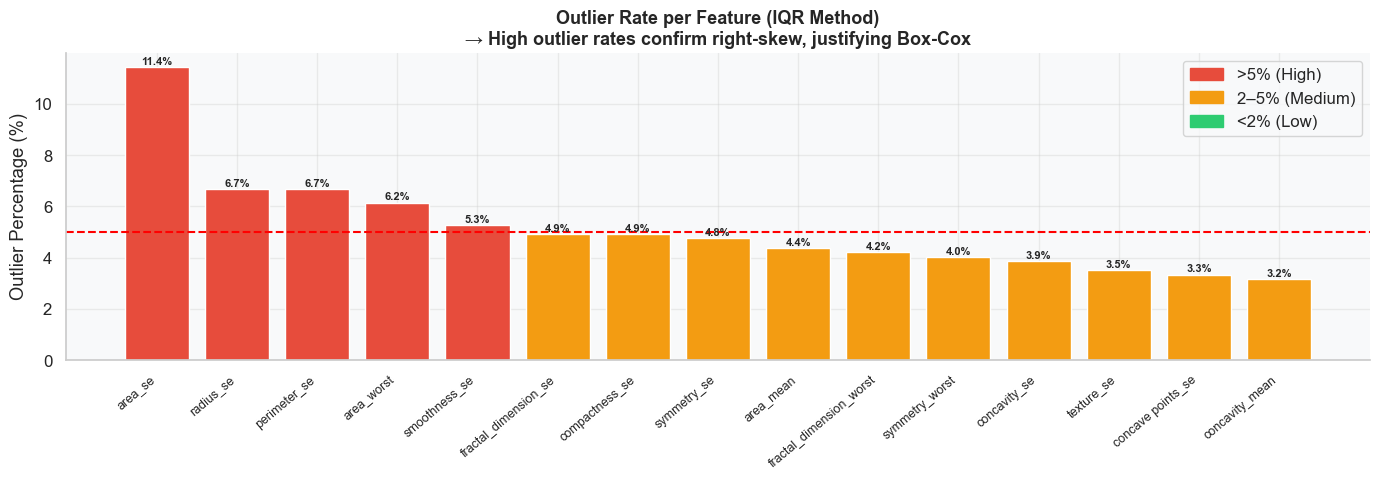

✅ Outlier analysis complete.


In [12]:
outlier_rows = []
for feat in feature_cols:
    Q1, Q3 = df[feat].quantile(0.25), df[feat].quantile(0.75)
    IQR    = Q3 - Q1
    n_out  = ((df[feat] < Q1 - 1.5*IQR) | (df[feat] > Q3 + 1.5*IQR)).sum()
    outlier_rows.append({'Feature': feat, 'N_Outlier': n_out,
                         'Pct (%)': round(n_out / len(df) * 100, 2)})

out_df = pd.DataFrame(outlier_rows).sort_values('N_Outlier', ascending=False)

print("Top 12 features by outlier count:")
display(out_df.head(12).style
    .background_gradient(cmap='Reds', subset=['N_Outlier', 'Pct (%)'])
    .format({'Pct (%)': '{:.2f}%'})
)

# Bar chart
top = out_df.head(15)
fig, ax = plt.subplots(figsize=(14, 5))
cols = ['#e74c3c' if p > 5 else '#f39c12' if p > 2 else '#2ecc71'
        for p in top['Pct (%)']]
bars = ax.bar(top['Feature'], top['Pct (%)'], color=cols, edgecolor='white')
for bar, v in zip(bars, top['Pct (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
ax.axhline(5, color='red', linestyle='--', linewidth=1.5, label='5% threshold')
ax.set_xticklabels(top['Feature'], rotation=40, ha='right', fontsize=9)
ax.set_title('Outlier Rate per Feature (IQR Method)\n'
             '→ High outlier rates confirm right-skew, justifying Box-Cox',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Outlier Percentage (%)')
patches = [mpatches.Patch(color='#e74c3c', label='>5% (High)'),
           mpatches.Patch(color='#f39c12', label='2–5% (Medium)'),
           mpatches.Patch(color='#2ecc71', label='<2% (Low)')]
ax.legend(handles=patches, loc='upper right')
plt.tight_layout(); plt.show()
print("✅ Outlier analysis complete.")

## Section 8: Pearson Correlation Heatmap (All Features)

**Why Pearson correlation?**  
The Pearson heatmap reveals **linear relationships** between every pair of features and between each feature and the target (diagnosis).

Two key observations expected in this dataset:
1. **Geometric cluster**: `radius`, `perimeter`, `area` features will show very high inter-correlation (r > 0.95) because they are mathematically related (area ≈ π·r²). This is *structural*, not coincidental.
2. **_worst/_mean/_se clusters**: Measurements taken at the worst (largest) cell, mean cell, and standard error tend to track each other.

These observations will inform the multicollinearity elimination strategy in Section 9.

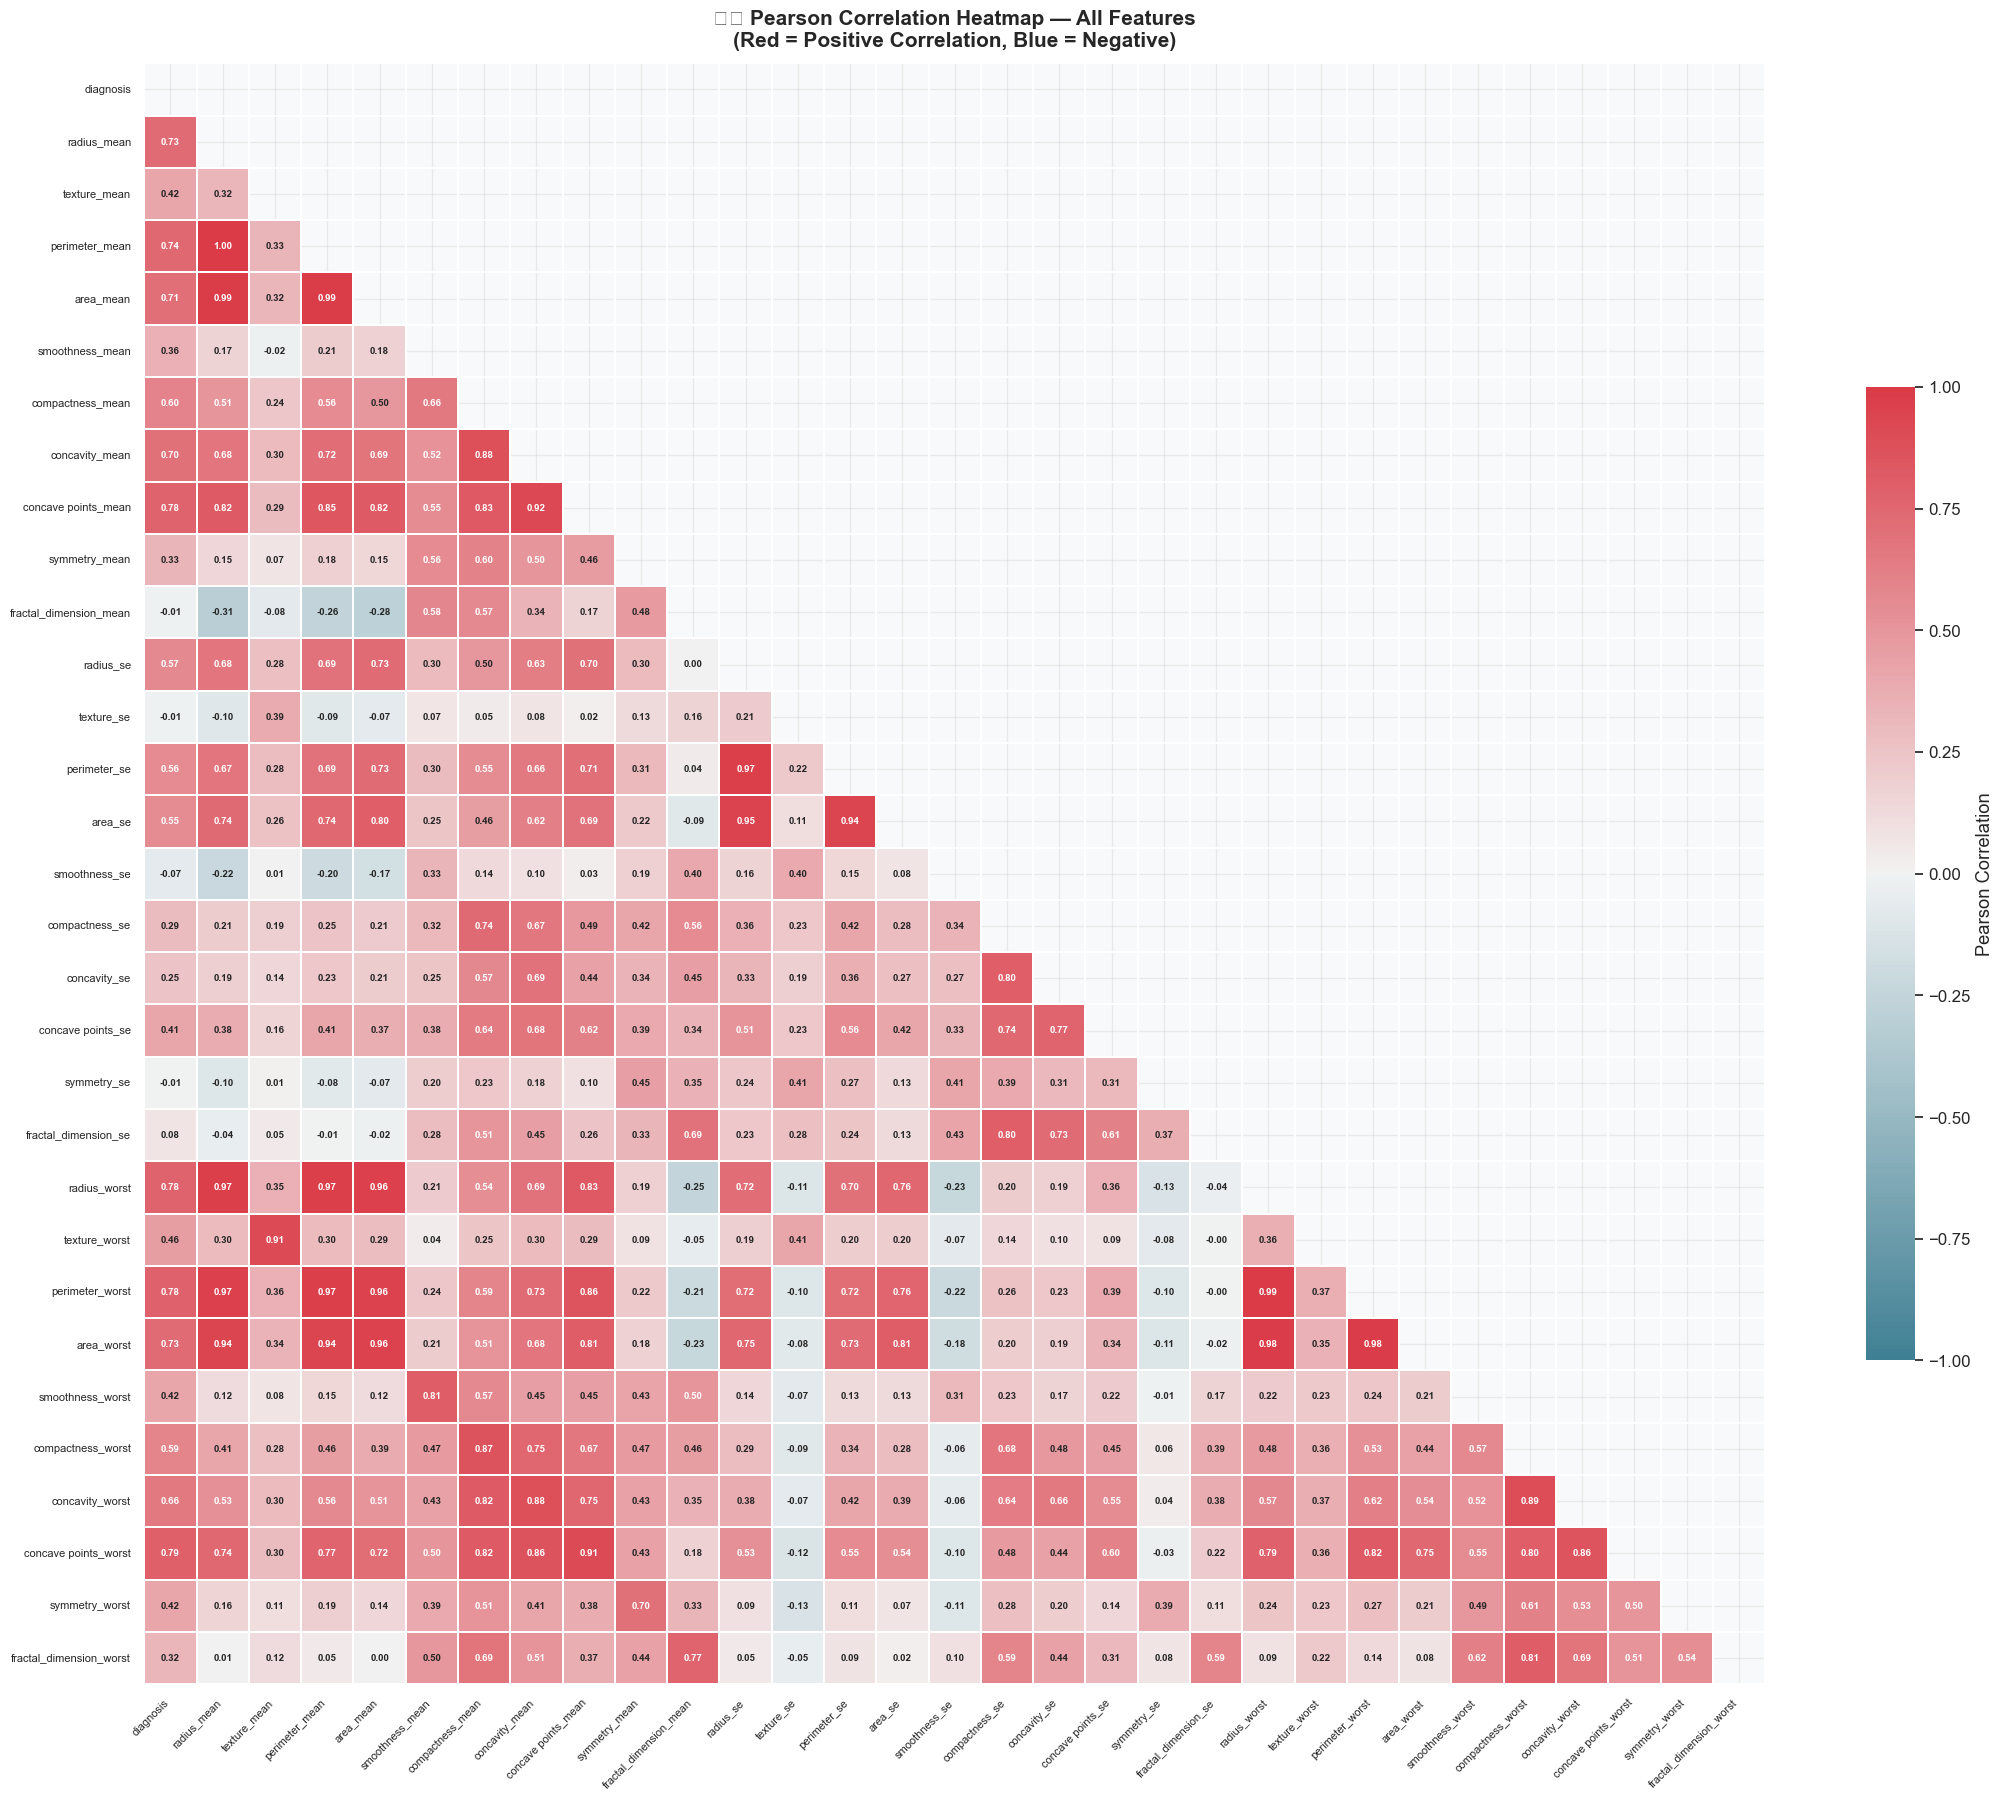

✅ Full correlation heatmap complete.


In [13]:
le = LabelEncoder()
df_enc = df.copy()
df_enc[TARGET_COL] = le.fit_transform(df[TARGET_COL])   # B=0, M=1

corr_all = df_enc.corr(method='pearson')
abs_corr  = corr_all.abs()

mask = np.zeros_like(abs_corr, dtype=bool)
mask[np.triu_indices_from(mask)] = True

fig, ax = plt.subplots(figsize=(22, 18))
sns.heatmap(
    corr_all, mask=mask,
    cmap=sns.diverging_palette(220, 10, as_cmap=True),
    vmin=-1, vmax=1, center=0,
    square=True, annot=True, fmt='.2f',
    annot_kws={'size': 7, 'weight': 'bold'},
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.6},
    ax=ax
)
ax.set_title('🌡️ Pearson Correlation Heatmap — All Features\n'
             '(Red = Positive Correlation, Blue = Negative)',
             fontsize=15, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout(); plt.show()
print("✅ Full correlation heatmap complete.")

## Section 9: Feature Ranking and Multicollinearity Elimination

### Feature Ranking
Ranking by absolute Pearson correlation with target gives a fast linear-based importance measure.  
Features with low correlation here may still be powerful non-linear predictors, this will be verified in Section 10 (ANOVA vs Mutual Information).

### Multicollinearity Elimination — The Correct Threshold
**Key principle**: the threshold must be calibrated to the model type:

| Model | Problem from multicollinearity | Correct threshold |
|---|---|---|
| OLS / Logistic Regression | $(X^TX)$ becomes singular; coefficients unstable | r > 0.80 |
| **XGBoost / RF (Tree-based)** | **None** — trees split on one feature at a time | r > **0.99** (near-perfect only) |
| **SVM (kernel RBF)** | Kernel maps to higher-dim space implicitly; minor effect | r > **0.99** |
| **ANN** | Weights self-distribute; Dropout handles redundancy | r > **0.99** |

**Why keeping geometric features (radius, perimeter, area) is correct for your models:**  
- `area_mean ≈ π × radius_mean²`: area IS a polynomial (quadratic) term of radius  
- `perimeter_mean ≈ 2π × radius_mean`: perimeter is a linear term of radius  
- For tree-based models, providing explicit `area_mean` gives the model a **pre-computed polynomial feature** at no cost  
- Dropping `area_mean` forces the tree to approximate the same relationship through extra splits  
- The regularization parameters (`reg_alpha`, `reg_lambda`, `gamma` in XGBoost; `max_depth`, `max_features` in RF) prevent overfitting on the correlated pair  

**We only drop features where r > 0.99**: truly near-identical measurements that carry zero additional information.

🏆 FEATURE RANKING — Absolute Pearson Correlation with Diagnosis
------------------------------------------------------------
   1. concave points_worst             0.7936  🔴 Strong
   2. perimeter_worst                  0.7829  🔴 Strong
   3. concave points_mean              0.7766  🔴 Strong
   4. radius_worst                     0.7765  🔴 Strong
   5. perimeter_mean                   0.7426  🔴 Strong
   6. area_worst                       0.7338  🔴 Strong
   7. radius_mean                      0.7300  🔴 Strong
   8. area_mean                        0.7090  🔴 Strong
   9. concavity_mean                   0.6964  🟡 Moderate
  10. concavity_worst                  0.6596  🟡 Moderate
  11. compactness_mean                 0.5965  🟡 Moderate
  12. compactness_worst                0.5910  🟡 Moderate
  13. radius_se                        0.5671  🟡 Moderate
  14. perimeter_se                     0.5561  🟡 Moderate
  15. area_se                          0.5482  🟡 Moderate
  16. texture_worst  

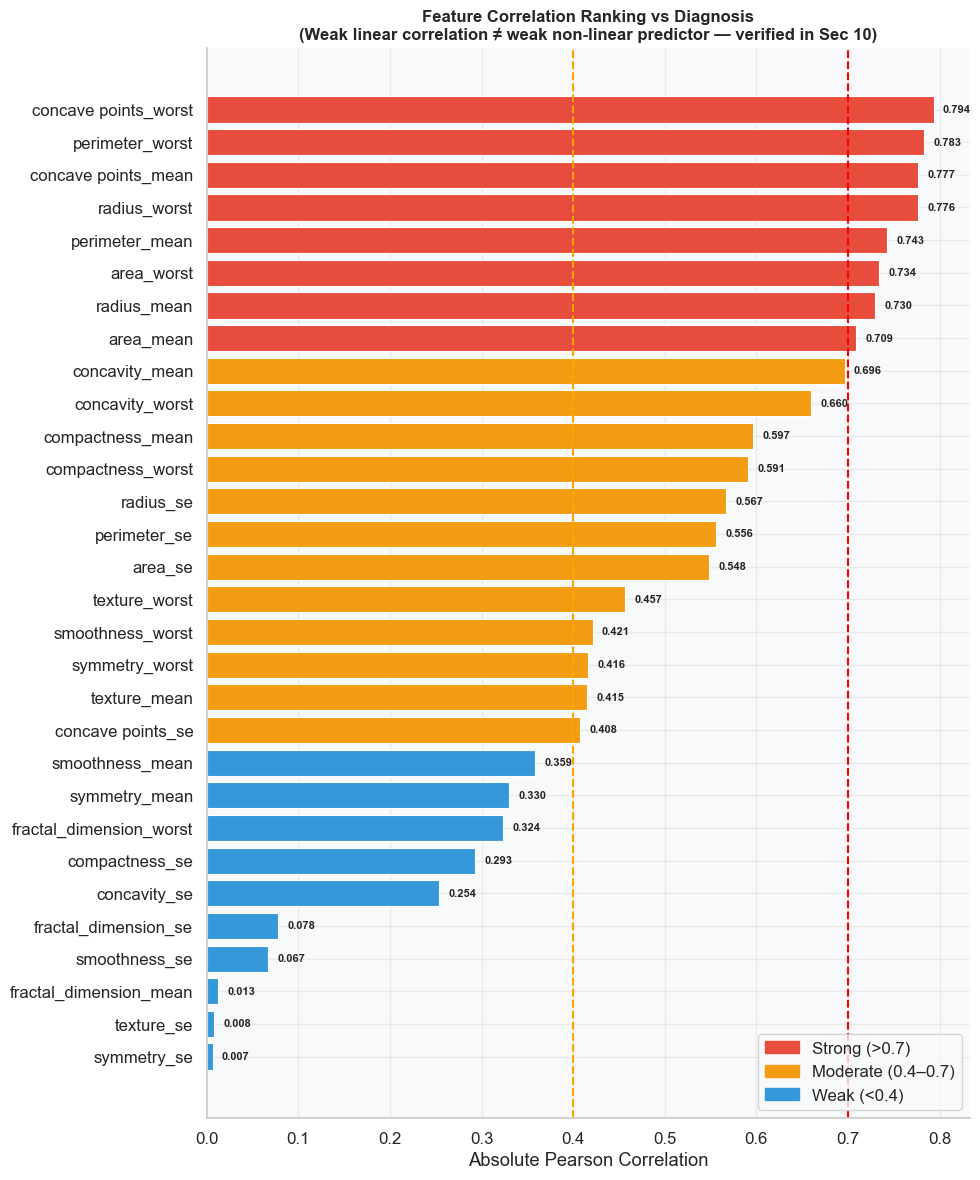

In [14]:
# Correlation of each feature with target (sorted descending)
target_corr = abs_corr[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)

print("🏆 FEATURE RANKING — Absolute Pearson Correlation with Diagnosis")
print("-" * 60)
for i, (feat, val) in enumerate(target_corr.items(), 1):
    tag = "🔴 Strong" if val > 0.7 else "🟡 Moderate" if val > 0.4 else "🔵 Weak"
    print(f"  {i:2d}. {feat:<32} {val:.4f}  {tag}")

# Ranking bar chart
fig, ax = plt.subplots(figsize=(10, 12))
cols_rank = ['#e74c3c' if v > 0.7 else '#f39c12' if v > 0.4 else '#3498db'
             for v in target_corr]
ax.barh(target_corr.index[::-1], target_corr.values[::-1],
        color=cols_rank[::-1], edgecolor='white', linewidth=0.8)
ax.axvline(0.4, color='orange', linestyle='--', linewidth=1.5,
           label='0.4 — Moderate threshold')
ax.axvline(0.7, color='red', linestyle='--', linewidth=1.5,
           label='0.7 — Strong threshold')
ax.set_title("Feature Correlation Ranking vs Diagnosis\n"
             "(Weak linear correlation ≠ weak non-linear predictor — verified in Sec 10)",
             fontsize=12, fontweight='bold')
ax.set_xlabel('Absolute Pearson Correlation')
for i, (feat, val) in enumerate(zip(target_corr.index[::-1],
                                    target_corr.values[::-1])):
    ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=8, fontweight='bold')
patches = [mpatches.Patch(color='#e74c3c', label='Strong (>0.7)'),
           mpatches.Patch(color='#f39c12', label='Moderate (0.4–0.7)'),
           mpatches.Patch(color='#3498db', label='Weak (<0.4)')]
ax.legend(handles=patches, loc='lower right')
plt.tight_layout(); plt.show()

In [15]:
# Multicollinearity elimination (threshold = 0.99 for all models)
MULTICOL_THRESHOLD = 0.99
sorted_feats  = target_corr.index.tolist()
feats_to_drop = set()

print(f"🧹 MULTICOLLINEARITY ELIMINATION — threshold = {MULTICOL_THRESHOLD}")
print("   Policy: keep BOTH features if mathematically related (area ≈ π·r²)")
print("   Drop only if r > 0.99 (near-perfectly redundant)")
print("-" * 65)

for i in range(len(sorted_feats)):
    f1 = sorted_feats[i]
    if f1 in feats_to_drop:
        continue
    for j in range(i + 1, len(sorted_feats)):
        f2 = sorted_feats[j]
        if f2 in feats_to_drop:
            continue
        r = abs(corr_all.loc[f1, f2])
        if r > MULTICOL_THRESHOLD:
            feats_to_drop.add(f2)
            print(f"  ❌ Drop  '{f2:<30}' "
                  f"(r={r:.4f} with '{f1}'  |  target_corr={target_corr[f2]:.4f})")

selected_features = [f for f in sorted_feats if f not in feats_to_drop]

print("\n" + "=" * 65)
print(f"  Features before : {len(sorted_feats)}")
print(f"  Features dropped : {len(feats_to_drop)} (near-perfect redundancy only)")
print(f"  Features SELECTED: {len(selected_features)}")
print("=" * 65)
print("\n💎 Selected features (all models will use this set):")
for r_i, f in enumerate(selected_features, 1):
    tag = "🔴" if target_corr[f] > 0.7 else "🟡" if target_corr[f] > 0.4 else "🔵"
    print(f"  {r_i:2d}. {f:<34} {target_corr[f]:.4f}  {tag}")

🧹 MULTICOLLINEARITY ELIMINATION — threshold = 0.99
   Policy: keep BOTH features if mathematically related (area ≈ π·r²)
   Drop only if r > 0.99 (near-perfectly redundant)
-----------------------------------------------------------------
  ❌ Drop  'radius_worst                  ' (r=0.9937 with 'perimeter_worst'  |  target_corr=0.7765)
  ❌ Drop  'radius_mean                   ' (r=0.9979 with 'perimeter_mean'  |  target_corr=0.7300)

  Features before : 30
  Features dropped : 2 (near-perfect redundancy only)
  Features SELECTED: 28

💎 Selected features (all models will use this set):
   1. concave points_worst               0.7936  🔴
   2. perimeter_worst                    0.7829  🔴
   3. concave points_mean                0.7766  🔴
   4. perimeter_mean                     0.7426  🔴
   5. area_worst                         0.7338  🔴
   6. area_mean                          0.7090  🔴
   7. concavity_mean                     0.6964  🟡
   8. concavity_worst                    0.6596  🟡

### Optional: Drop Weakly Correlated Features

After removing near-perfectly redundant features (r > 0.99), there is an **optional** second filter:  
dropping features whose absolute Pearson correlation with Diagnosis falls below a minimum threshold.

**When is this appropriate?**
- Features with |r| < 0.05 carry almost no linear signal, even for non-linear models, a near-zero  
  correlation usually indicates a truly uninformative feature rather than a hidden non-linear relationship
- Removing them reduces dimensionality and training time with negligible accuracy trade-off

**How to configure:**
```python
WEAK_CORR_THRESHOLD = 0.10   # drop features with |r_target| < 0.10
WEAK_CORR_THRESHOLD = None   # disable this filter entirely
```
Set `None` to keep all features that survived the multicollinearity step.

In [16]:
# Optional weak-correlation filter
# Set to None to disable; any value 0–1 activates the filter
WEAK_CORR_THRESHOLD = 0.10

if WEAK_CORR_THRESHOLD is not None:
    weak_feats = [f for f in selected_features
                  if target_corr[f] < WEAK_CORR_THRESHOLD]
    if weak_feats:
        print(f"⚠️  WEAK CORRELATION FILTER  (threshold |r| < {WEAK_CORR_THRESHOLD})")
        print(f"   Dropped {len(weak_feats)} feature(s):")
        for f in weak_feats:
            print(f"   ❌  {f:<34}  |r| = {target_corr[f]:.4f}")
        selected_features = [f for f in selected_features if f not in weak_feats]
        print(f"\n   Features remaining after weak-corr filter: {len(selected_features)}")
    else:
        print(f"✅ No features below weak correlation threshold ({WEAK_CORR_THRESHOLD}).")
else:
    print("ℹ️  Weak correlation filter disabled (WEAK_CORR_THRESHOLD = None).")

print(f"\n📋 Final selected_features ({len(selected_features)} total):")
for i, f in enumerate(selected_features, 1):
    tag = "🔴" if target_corr[f] > 0.7 else "🟡" if target_corr[f] > 0.4 else "🔵"
    print(f"  {i:2d}. {f:<34} |r| = {target_corr[f]:.4f}  {tag}")

⚠️  WEAK CORRELATION FILTER  (threshold |r| < 0.1)
   Dropped 5 feature(s):
   ❌  fractal_dimension_se                |r| = 0.0780
   ❌  smoothness_se                       |r| = 0.0670
   ❌  fractal_dimension_mean              |r| = 0.0128
   ❌  texture_se                          |r| = 0.0083
   ❌  symmetry_se                         |r| = 0.0065

   Features remaining after weak-corr filter: 23

📋 Final selected_features (23 total):
   1. concave points_worst               |r| = 0.7936  🔴
   2. perimeter_worst                    |r| = 0.7829  🔴
   3. concave points_mean                |r| = 0.7766  🔴
   4. perimeter_mean                     |r| = 0.7426  🔴
   5. area_worst                         |r| = 0.7338  🔴
   6. area_mean                          |r| = 0.7090  🔴
   7. concavity_mean                     |r| = 0.6964  🟡
   8. concavity_worst                    |r| = 0.6596  🟡
   9. compactness_mean                   |r| = 0.5965  🟡
  10. compactness_worst                  |r| = 

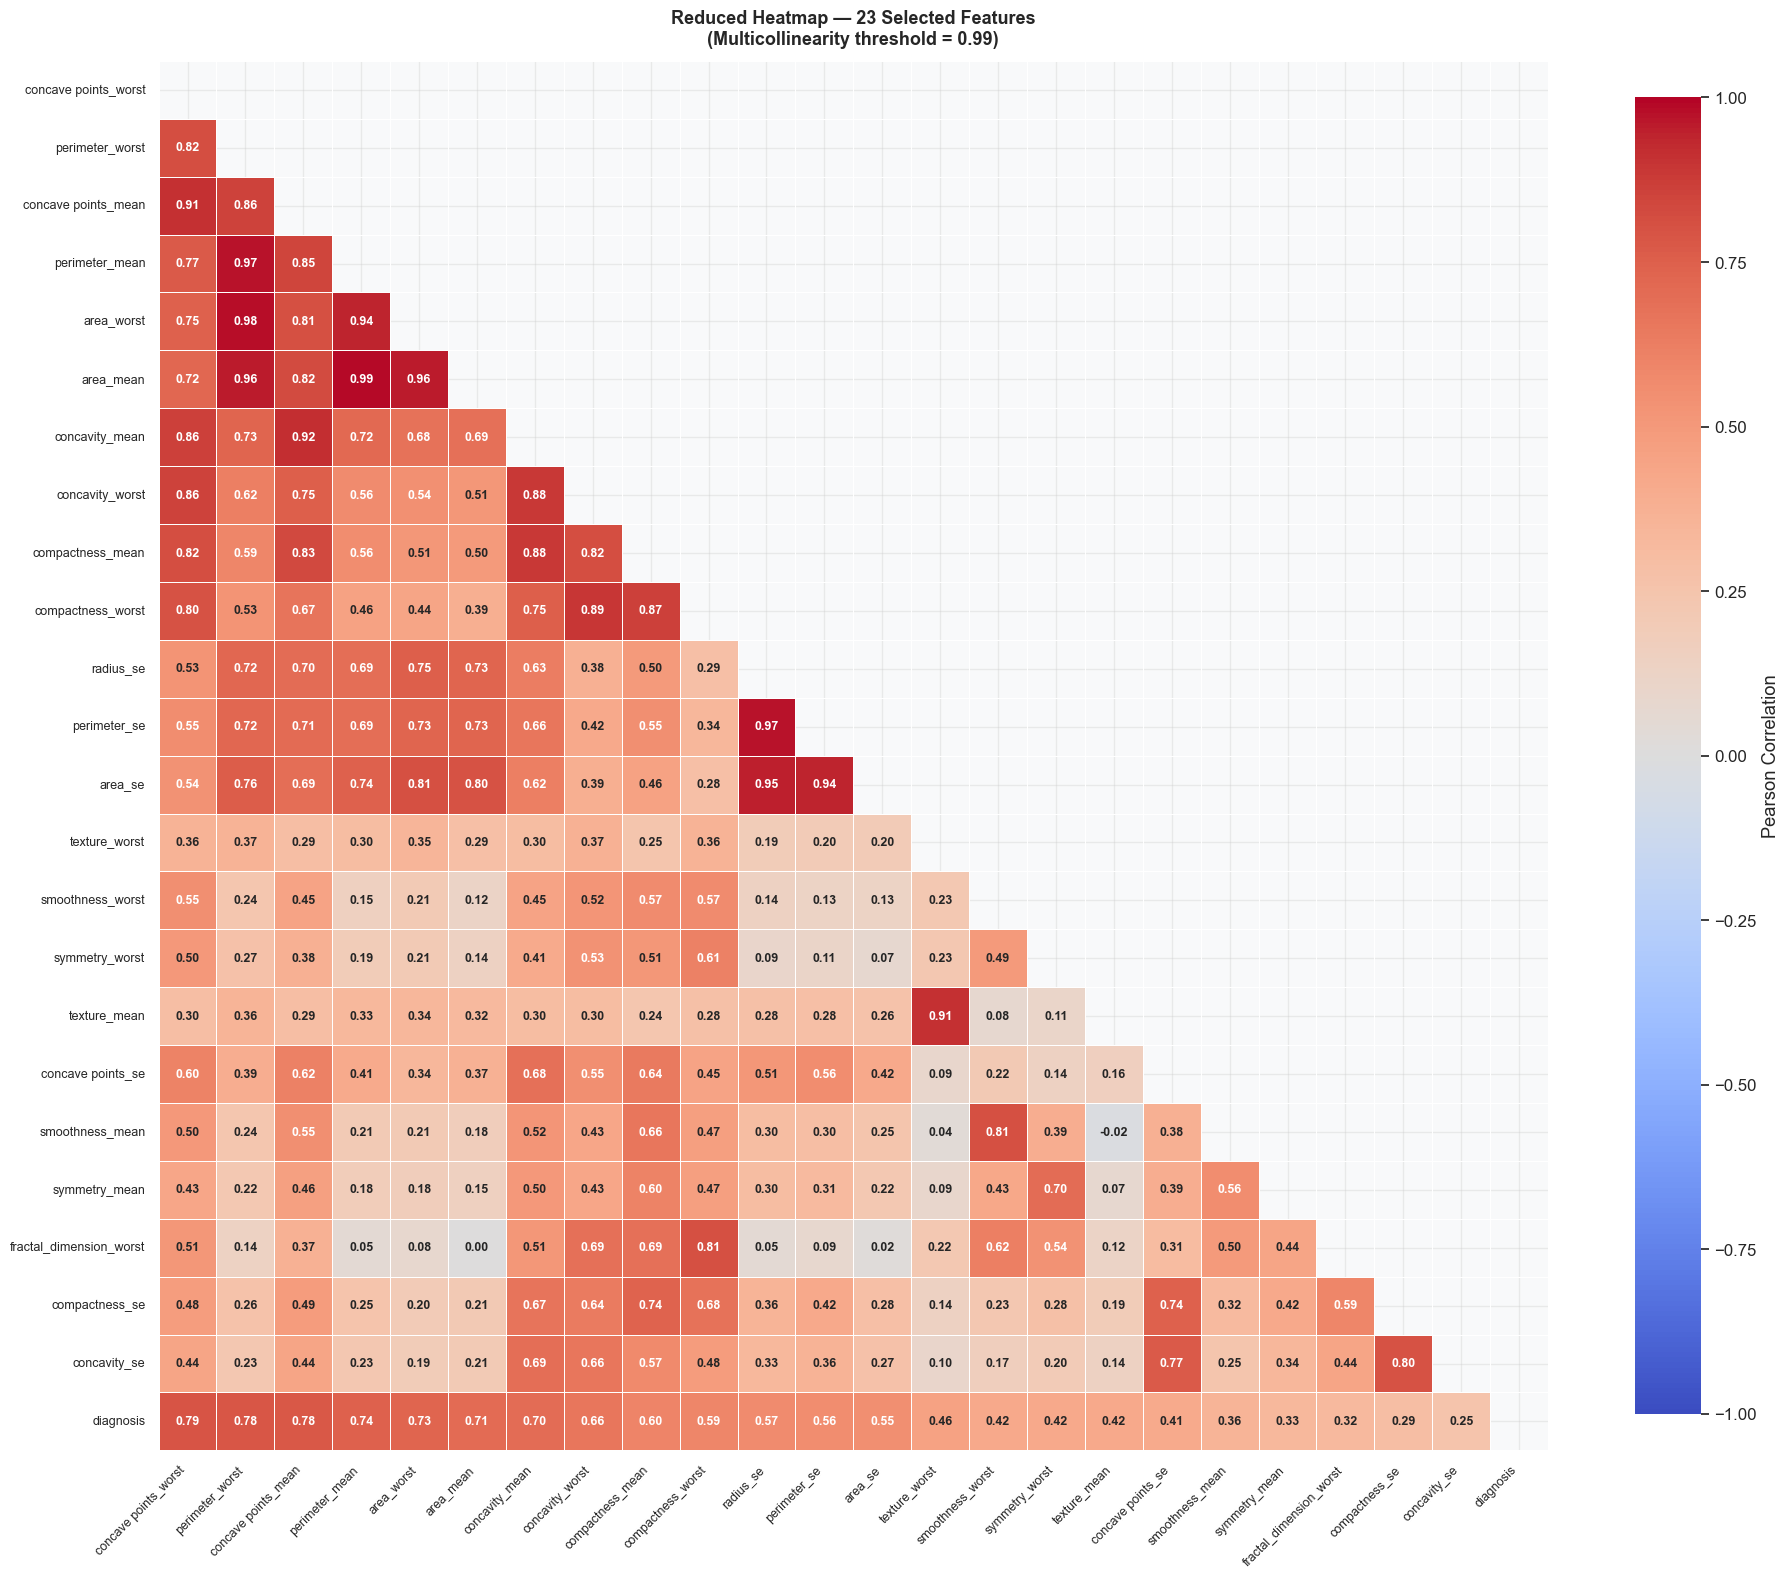

In [17]:
# Reduced heatmap — selected features only
df_sel_enc = df_enc[selected_features + [TARGET_COL]]
corr_sel   = df_sel_enc.corr(method='pearson')
mask_sel   = np.zeros_like(corr_sel, dtype=bool)
mask_sel[np.triu_indices_from(mask_sel)] = True

sz = max(10, len(selected_features) * 0.75 + 2)
fig, ax = plt.subplots(figsize=(sz, sz * 0.9))
sns.heatmap(
    corr_sel, mask=mask_sel,
    cmap='coolwarm', vmin=-1, vmax=1, center=0,
    square=True, annot=True, fmt='.2f',
    annot_kws={'size': 9, 'weight': 'bold'},
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
    ax=ax
)
ax.set_title(f'Reduced Heatmap — {len(selected_features)} Selected Features\n'
             f'(Multicollinearity threshold = {MULTICOL_THRESHOLD})',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout(); plt.show()

## Section 10: ANOVA F-Test vs Mutual Information

**Why both ANOVA and Mutual Information (MI)?**

| Method | What it measures | Limitation |
|---|---|---|
| **ANOVA F-test** | Linear class separability (difference of class means) | Blind to non-linear relationships |
| **Mutual Information** | Any statistical dependency, linear AND non-linear | Computationally heavier; depends on bins/k-neighbors |

**Reading the scatter plot:**
- **Top-right quadrant**: strong predictor by BOTH metrics → high-value feature for all models  
- **Top-left quadrant** (high MI, low ANOVA): strong **non-linear** predictor → especially valuable for XGBoost, RF, ANN  
- **Bottom-right quadrant** (high ANOVA, low MI): mostly linear predictor → better suited for SVM  
- **Bottom-left**: weak by both metrics → regularization will downweight these

A feature with low ANOVA but high MI should **never** be dropped based on Pearson correlation alone.

Feature scores sorted by Mutual Information:


,Feature,ANOVA_F,p_value,MI_Score
0,perimeter_worst,897.94,0.0000,0.4768
1,area_worst,661.60,0.0000,0.4634
2,concave points_mean,861.68,0.0000,0.4405
3,concave points_worst,964.39,0.0000,0.4385
4,perimeter_mean,697.24,0.0000,0.4039
5,concavity_mean,533.79,0.0000,0.3723
6,area_mean,573.06,0.0000,0.3608
7,area_se,243.65,0.0000,0.3404
8,concavity_worst,436.69,0.0000,0.3154
9,perimeter_se,253.90,0.0000,0.2748


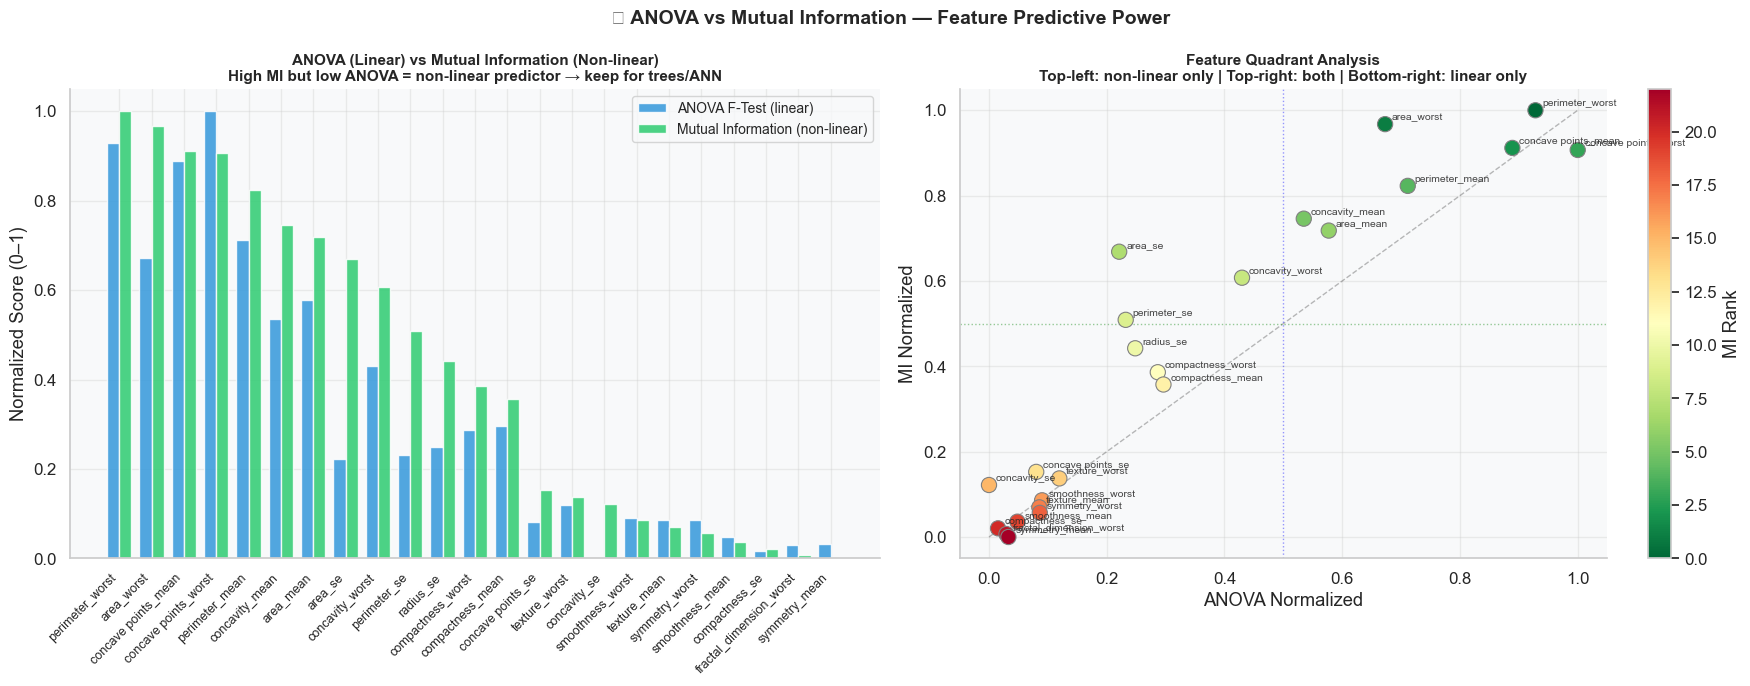

✅ ANOVA/MI analysis complete.


In [18]:
X_mi = df_enc[selected_features]
y_mi = df_enc[TARGET_COL]

f_vals, p_vals = f_classif(X_mi, y_mi)
mi_vals        = mutual_info_classif(X_mi, y_mi, random_state=SEED)

score_df = pd.DataFrame({
    'Feature'  : selected_features,
    'ANOVA_F'  : f_vals,
    'p_value'  : p_vals,
    'MI_Score' : mi_vals
})
mm = MinMaxScaler()
score_df[['ANOVA_norm', 'MI_norm']] = mm.fit_transform(
    score_df[['ANOVA_F', 'MI_Score']])
score_df = score_df.sort_values('MI_Score', ascending=False).reset_index(drop=True)

print("Feature scores sorted by Mutual Information:")
display(score_df[['Feature', 'ANOVA_F', 'p_value', 'MI_Score']].style
    .background_gradient(cmap='Greens', subset=['MI_Score'])
    .background_gradient(cmap='Blues',  subset=['ANOVA_F'])
    .format({'ANOVA_F': '{:.2f}', 'p_value': '{:.4f}', 'MI_Score': '{:.4f}'})
)

x_pos = np.arange(len(score_df))
w     = 0.38
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

ax = axes[0]
ax.bar(x_pos - w/2, score_df['ANOVA_norm'], w,
       label='ANOVA F-Test (linear)', color='#3498db', alpha=0.85, edgecolor='white')
ax.bar(x_pos + w/2, score_df['MI_norm'], w,
       label='Mutual Information (non-linear)', color='#2ecc71', alpha=0.85, edgecolor='white')
ax.set_xticks(x_pos)
ax.set_xticklabels(score_df['Feature'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Normalized Score (0–1)')
ax.set_title('ANOVA (Linear) vs Mutual Information (Non-linear)\n'
             'High MI but low ANOVA = non-linear predictor → keep for trees/ANN',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=10)

ax2 = axes[1]
sc = ax2.scatter(score_df['ANOVA_norm'], score_df['MI_norm'],
                 c=np.arange(len(score_df)), cmap='RdYlGn_r',
                 s=120, edgecolors='gray', linewidths=0.8, zorder=3)
for _, row in score_df.iterrows():
    ax2.annotate(row['Feature'], (row['ANOVA_norm'], row['MI_norm']),
                 xytext=(5, 3), textcoords='offset points', fontsize=7.5, alpha=0.85)
ax2.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1, label='y=x')
ax2.axvline(0.5, color='blue',  linestyle=':', alpha=0.4, linewidth=1)
ax2.axhline(0.5, color='green', linestyle=':', alpha=0.4, linewidth=1)
ax2.set_xlabel('ANOVA Normalized'); ax2.set_ylabel('MI Normalized')
ax2.set_title('Feature Quadrant Analysis\n'
              'Top-left: non-linear only | Top-right: both | Bottom-right: linear only',
              fontsize=11, fontweight='bold')
plt.colorbar(sc, ax=ax2, label='MI Rank')

fig.suptitle('🔬 ANOVA vs Mutual Information — Feature Predictive Power',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print("✅ ANOVA/MI analysis complete.")

## Section 11: Box-Cox Transformation

**Why Box-Cox?**  
The histograms in Section 4 showed right-skewed distributions with high outlier rates (confirmed in Section 7). Box-Cox transformation addresses this by finding an optimal power parameter λ per feature:

$$x_{\text{transformed}} = \frac{x^\lambda - 1}{\lambda} \quad (\lambda \neq 0), \quad \ln(x) \quad (\lambda = 0)$$

| Criterion | Box-Cox | Yeo-Johnson |
|---|---|---|
| Data requirement | Strictly positive (x > 0) | Any real value |
| Effectiveness on right-skewed, positive data | **More aggressive**, optimal for this dataset | Effective but more conservative |
| Result with λ ≈ 0 | Approaches log-transform, strongly compresses right tail | Similar |

**Why Box-Cox is applied AFTER feature selection (not before)?**  
Two reasons:
1. **Efficiency**: λ is estimated via maximum likelihood on each feature, no point fitting unused features  
2. **Integrity**: transformation parameters (λ, epsilon shift) belong to the selected feature set only; keeping them separate avoids any conceptual coupling with dropped features

**Epsilon shift for near-zero values**: Box-Cox requires x > 0 strictly. For any feature with min ≤ 0, an epsilon offset (ε = |min| + 10⁻⁶) is added before transformation and recorded.

In [19]:
print("⏳ Applying Box-Cox transformation to selected features...")
print("   (Automatic epsilon shift applied if any value ≤ 0)")
print()

X_raw   = df[selected_features].copy()
y_label = df[TARGET_COL].copy()

X_boxcox     = pd.DataFrame(index=X_raw.index)
lambda_dict  = {}   # optimal λ per feature
epsilon_dict = {}   # epsilon shift per feature

skew_rows = []
for feat in selected_features:
    col = X_raw[feat].copy()
    eps = 0.0
    if col.min() <= 0:
        eps = abs(col.min()) + 1e-6
        col = col + eps
        print(f"  ⚠️  {feat:<34} min={X_raw[feat].min():.2e} → +{eps:.2e} applied")
    epsilon_dict[feat] = eps
    transformed, lam   = boxcox(col)
    lambda_dict[feat]  = lam
    X_boxcox[feat]     = transformed
    skew_rows.append({
        'Feature'            : feat,
        'Skew Before'        : round(X_raw[feat].skew(), 4),
        'Skew After (Box-Cox)': round(pd.Series(transformed).skew(), 4),
        'Lambda (λ)'         : round(lam, 4),
        'Improvement'        : round(abs(X_raw[feat].skew()) - abs(pd.Series(transformed).skew()), 4)
    })

df_transformed = X_boxcox.copy()
df_transformed[TARGET_COL] = y_label.values

skew_df = pd.DataFrame(skew_rows).sort_values('Skew Before', ascending=False)
print(f"\n✅ Box-Cox complete for {len(selected_features)} features.")
print("\n📊 Skewness Before vs After:")
display(skew_df.style
    .background_gradient(cmap='RdYlGn', subset=['Improvement'])
    .background_gradient(cmap='Reds_r', subset=['Skew Before'])
    .background_gradient(cmap='Greens_r', subset=['Skew After (Box-Cox)'])
    .format(precision=4)
)

⏳ Applying Box-Cox transformation to selected features...
   (Automatic epsilon shift applied if any value ≤ 0)

  ⚠️  concave points_worst               min=0.00e+00 → +1.00e-06 applied
  ⚠️  concave points_mean                min=0.00e+00 → +1.00e-06 applied
  ⚠️  concavity_mean                     min=0.00e+00 → +1.00e-06 applied
  ⚠️  concavity_worst                    min=0.00e+00 → +1.00e-06 applied
  ⚠️  concave points_se                  min=0.00e+00 → +1.00e-06 applied
  ⚠️  concavity_se                       min=0.00e+00 → +1.00e-06 applied

✅ Box-Cox complete for 23 features.

📊 Skewness Before vs After:


,Feature,Skew Before,Skew After (Box-Cox),Lambda (λ),Improvement
12,area_se,5.4472,0.0585,-0.4357,5.3887
22,concavity_se,5.1105,0.1655,0.3833,4.9450
11,perimeter_se,3.4436,0.0316,-0.4294,3.4120
10,radius_se,3.0886,0.0303,-0.3976,3.0583
21,compactness_se,1.9022,-0.0000,0.0021,1.9022
4,area_worst,1.8594,0.0266,-0.3315,1.8328
20,fractal_dimension_worst,1.6626,0.0249,-1.3446,1.6377
5,area_mean,1.6457,0.0051,-0.2111,1.6406
9,compactness_worst,1.4736,-0.0057,0.1293,1.4679
17,concave points_se,1.4447,0.0335,0.5848,1.4112


📊 Before vs After Box-Cox comparison (per class)...


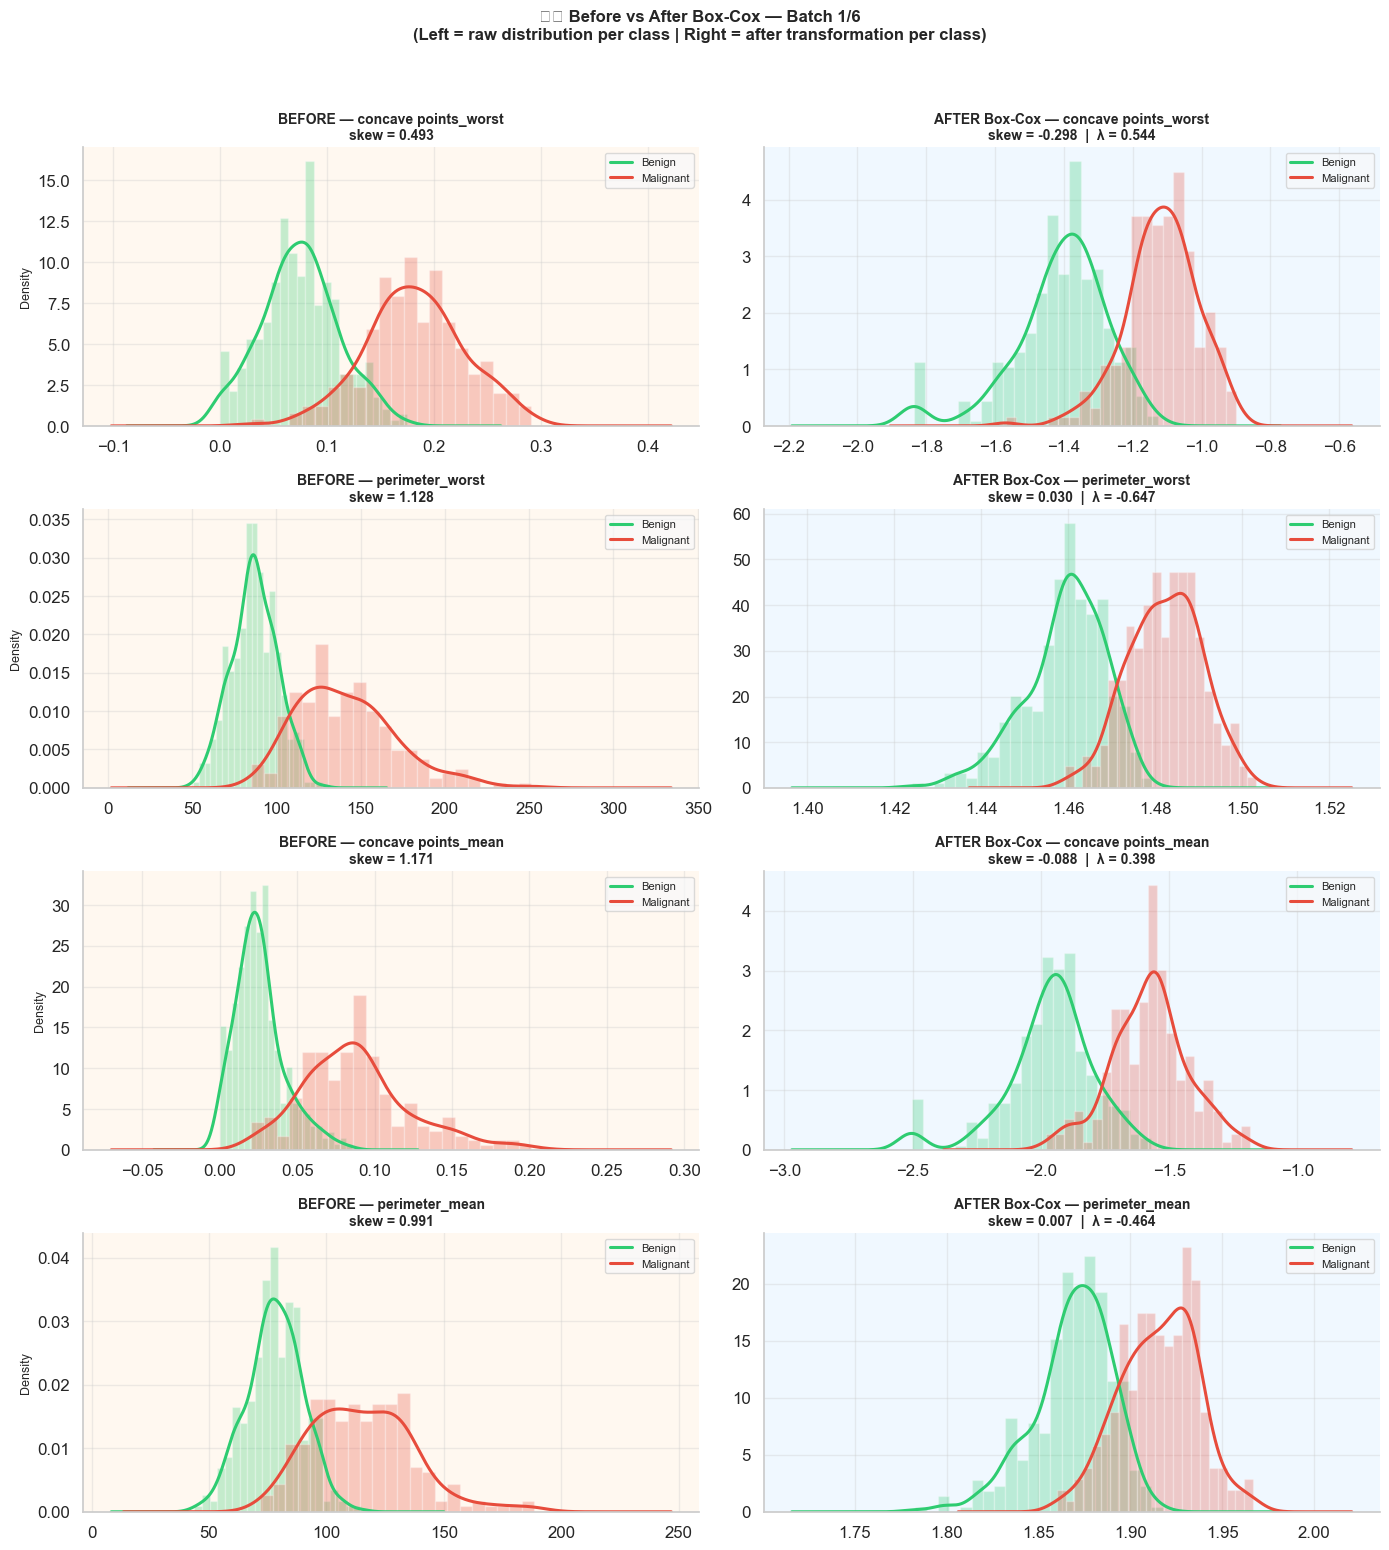

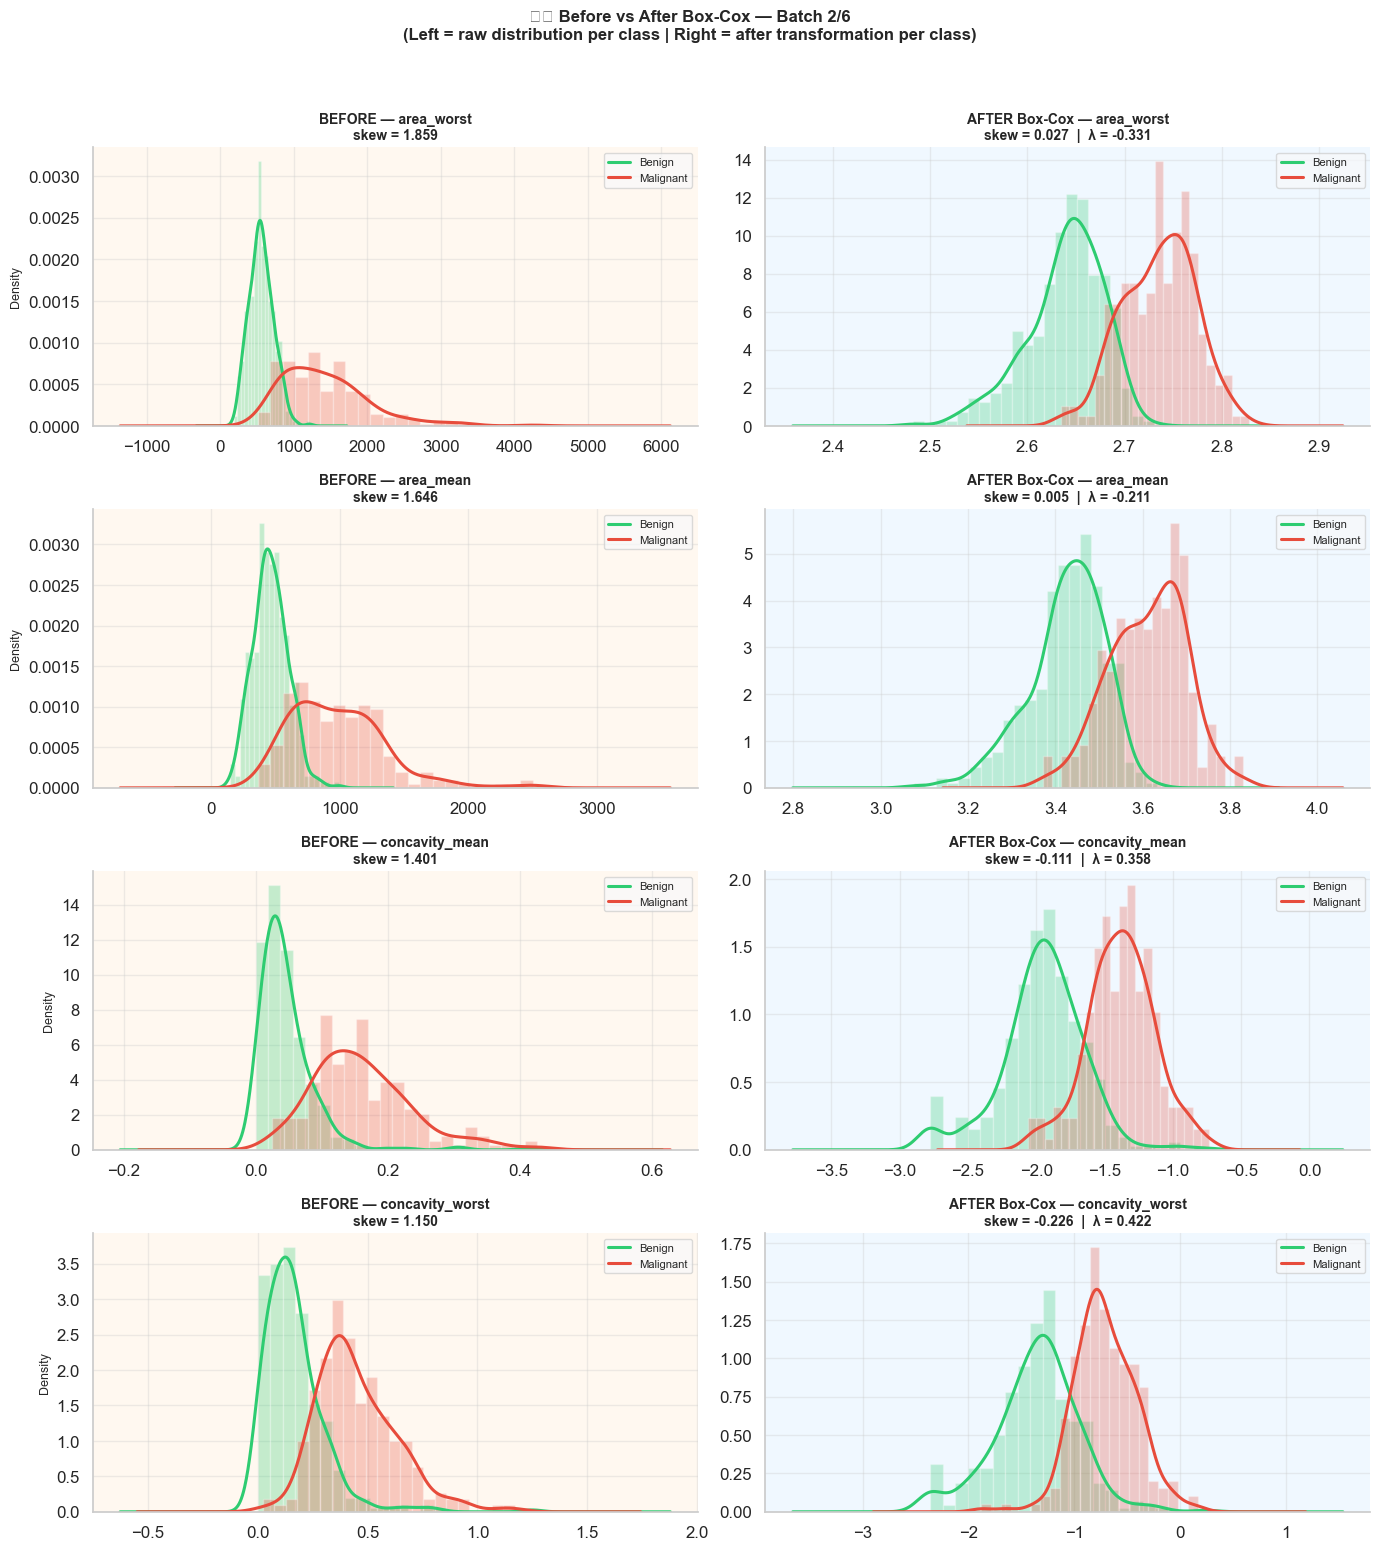

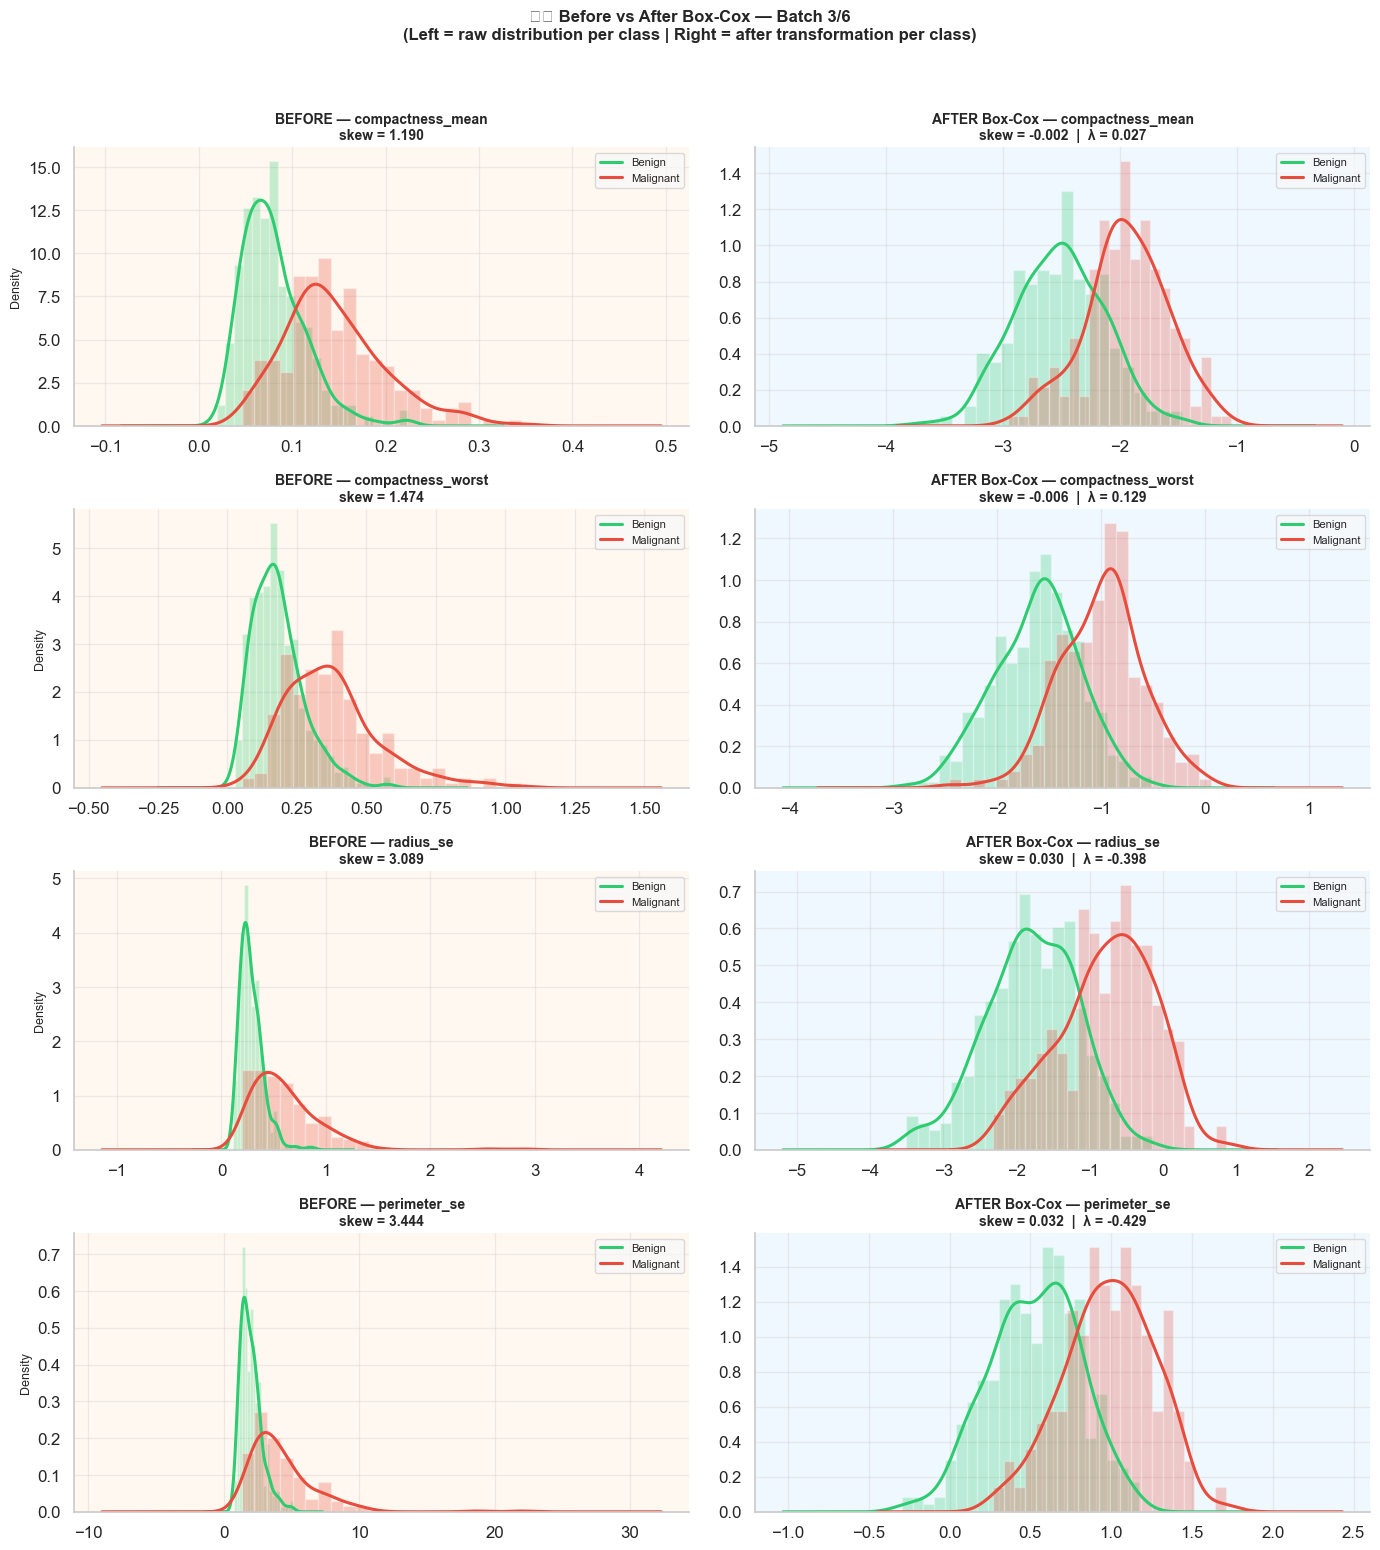

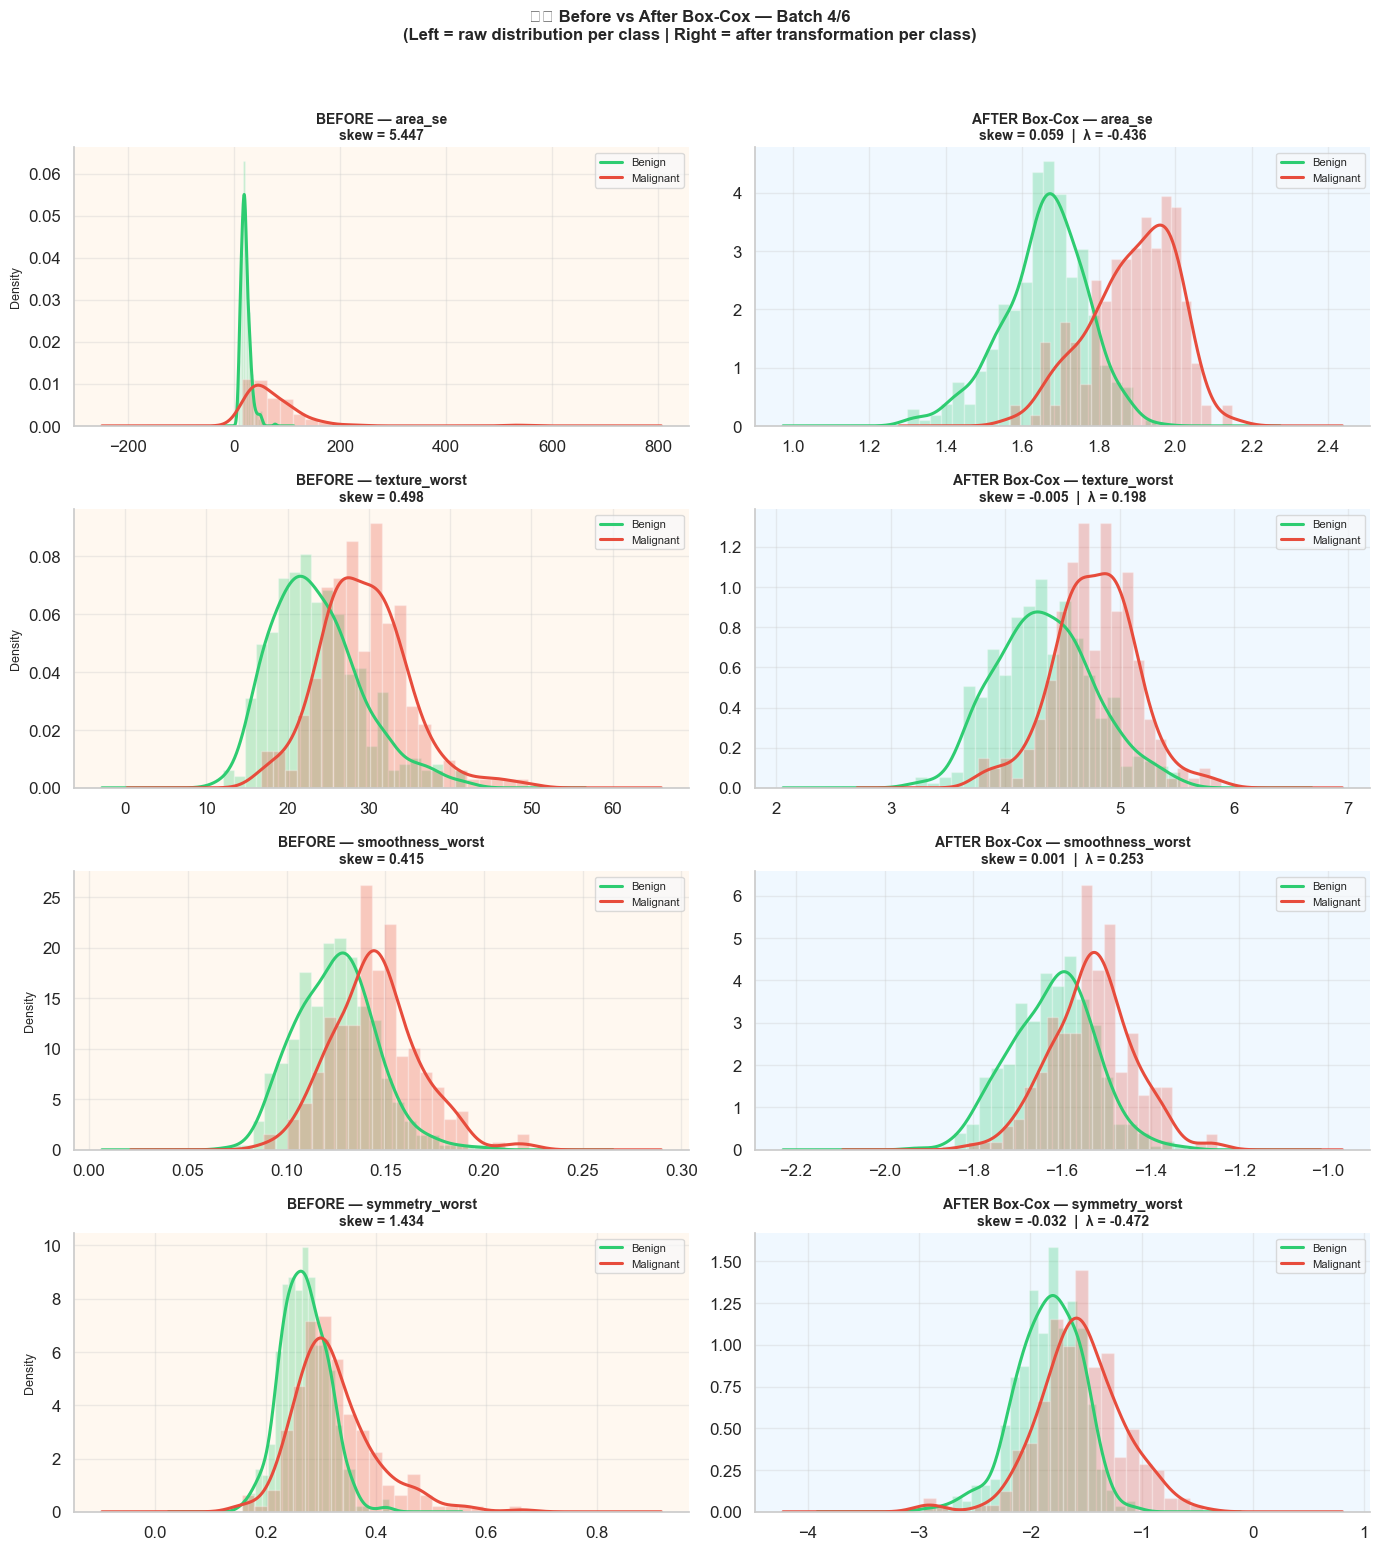

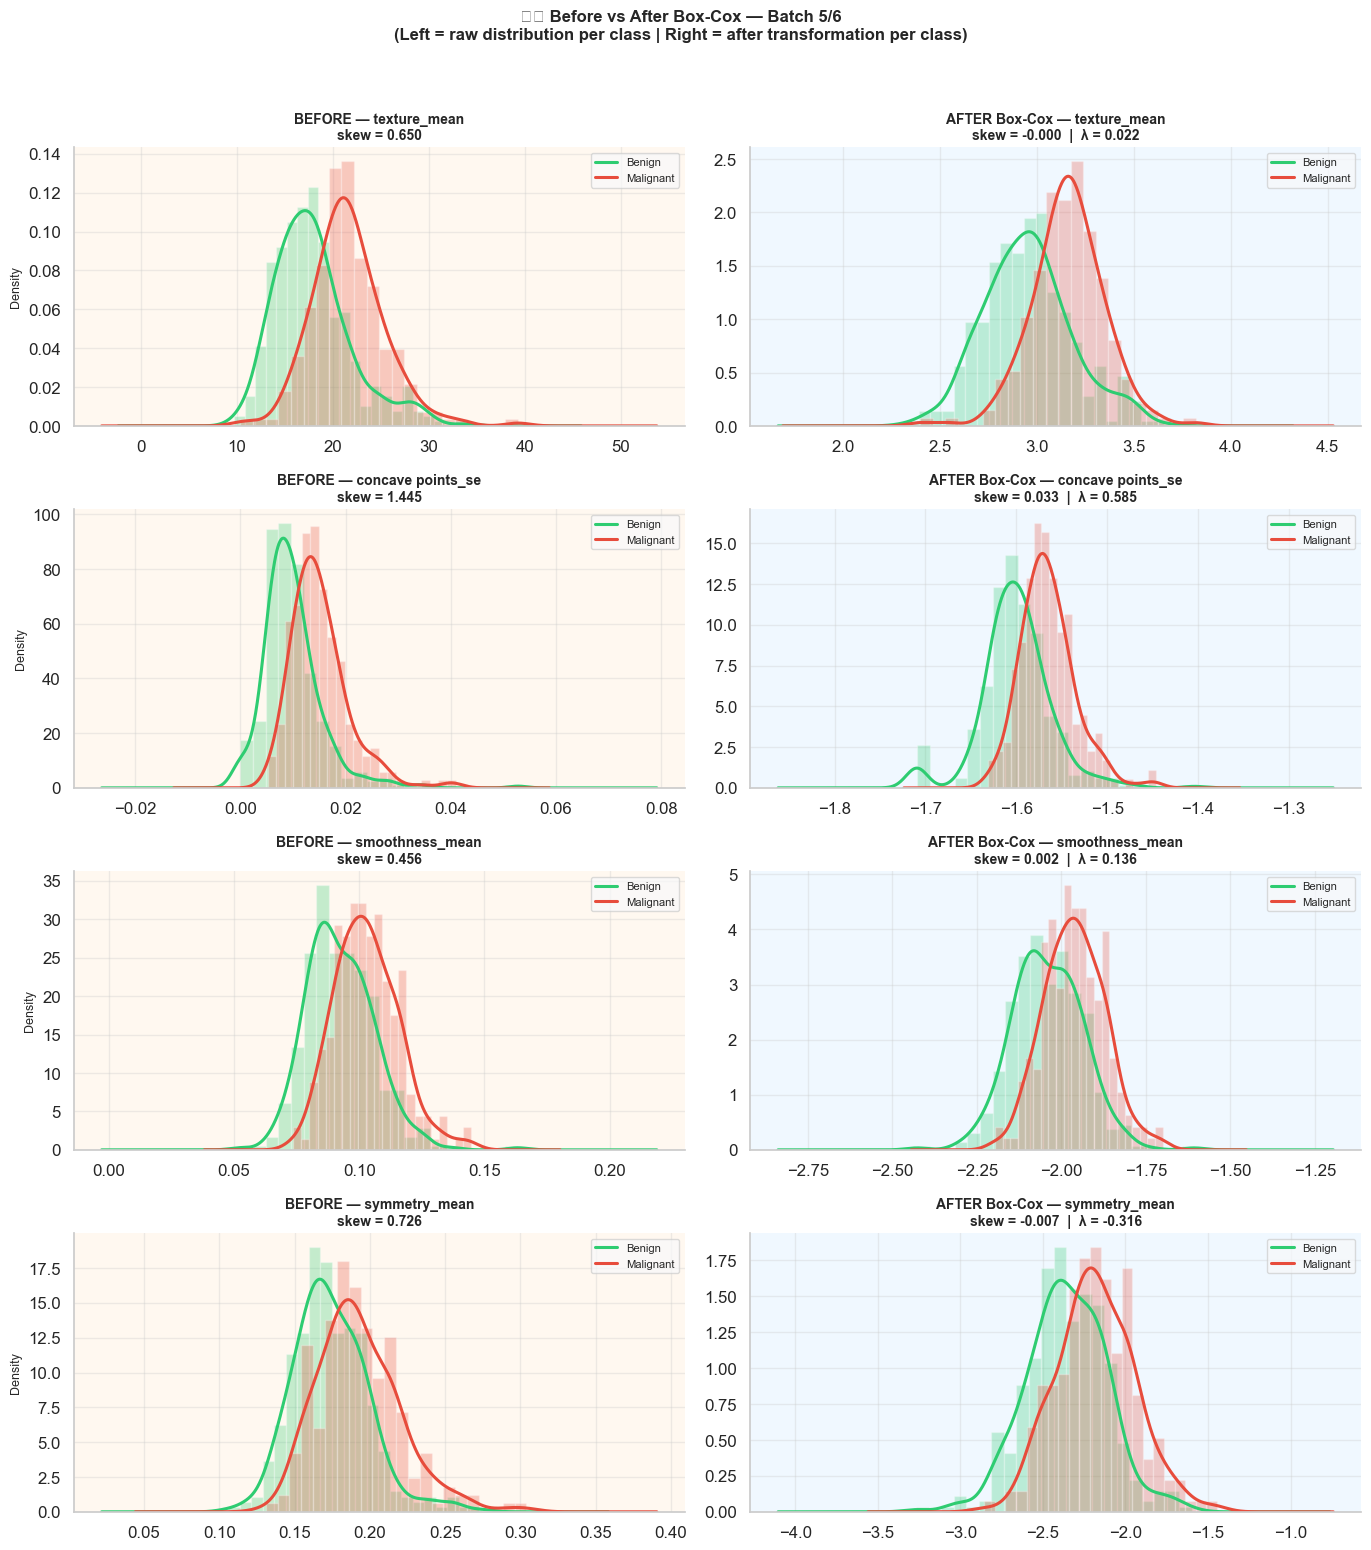

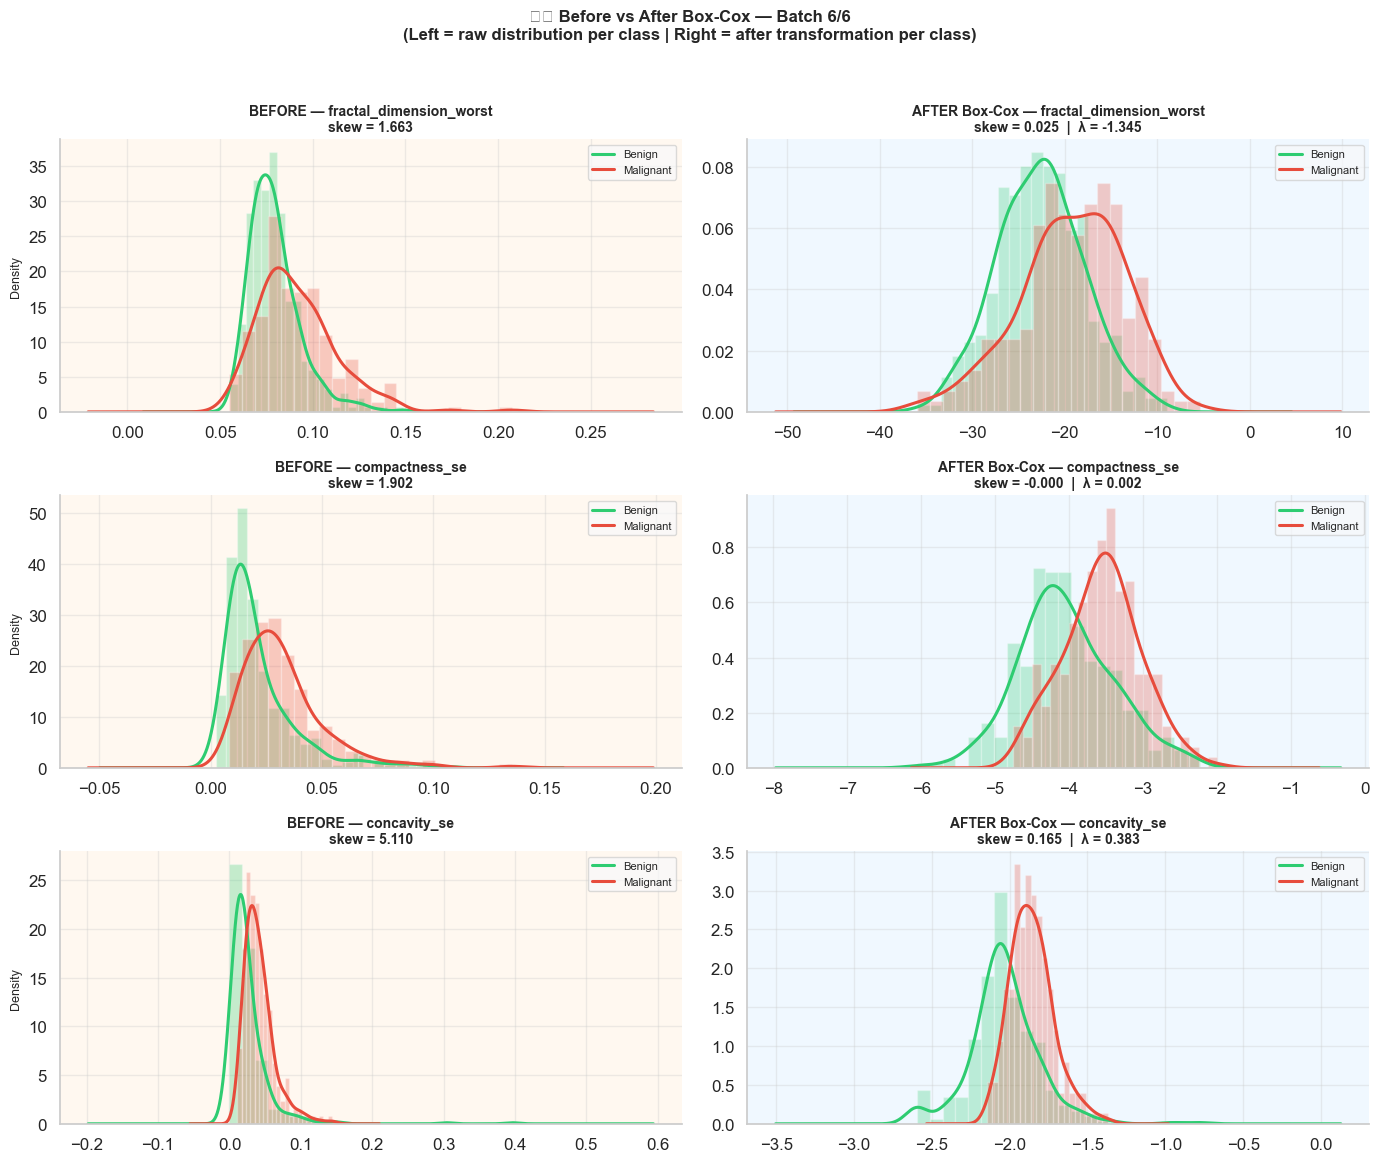

✅ Before/After Box-Cox comparison complete.


In [20]:
# Before vs After Box-Cox: side-by-side distribution per class
print("📊 Before vs After Box-Cox comparison (per class)...")

comp_batch = 4
comp_nbat  = math.ceil(len(selected_features) / comp_batch)

for bi in range(comp_nbat):
    batch = selected_features[bi * comp_batch : (bi + 1) * comp_batch]
    nb_f  = len(batch)
    fig, axes = plt.subplots(nb_f, 2, figsize=(14, 3.8 * nb_f))
    if nb_f == 1:
        axes = np.array([axes])

    for j, feat in enumerate(batch):
        lam       = lambda_dict[feat]
        sk_before = X_raw[feat].skew()
        sk_after  = df_transformed[feat].skew()

        # LEFT — BEFORE Box-Cox, split by class
        ax_b = axes[j, 0]
        for cls, col, lbl in zip(['B','M'], COLORS, ['Benign','Malignant']):
            sub = X_raw[df[TARGET_COL] == cls][feat]
            ax_b.hist(sub, bins=22, density=True, alpha=0.28, color=col, edgecolor='white')
            sub.plot.kde(ax=ax_b, color=col, linewidth=2.2, label=lbl)
        ax_b.set_title(f"BEFORE — {feat}\nskew = {sk_before:.3f}",
                       fontweight='bold', fontsize=10)
        ax_b.set_ylabel('Density', fontsize=9)
        ax_b.legend(fontsize=8, framealpha=0.7)
        ax_b.set_facecolor('#fff8f0')   # warm tint = before

        # RIGHT, AFTER Box-Cox, split by class
        ax_a = axes[j, 1]
        for cls, col, lbl in zip(['B','M'], COLORS, ['Benign','Malignant']):
            sub = df_transformed[df_transformed[TARGET_COL] == cls][feat]
            ax_a.hist(sub, bins=22, density=True, alpha=0.28, color=col, edgecolor='white')
            sub.plot.kde(ax=ax_a, color=col, linewidth=2.2, label=lbl)
        ax_a.set_title(f"AFTER Box-Cox — {feat}\nskew = {sk_after:.3f}  |  λ = {lam:.3f}",
                       fontweight='bold', fontsize=10)
        ax_a.set_ylabel('', fontsize=9)
        ax_a.legend(fontsize=8, framealpha=0.7)
        ax_a.set_facecolor('#f0f8ff')   # cool tint = after

    fig.suptitle(
        f"⚗️ Before vs After Box-Cox — Batch {bi+1}/{comp_nbat}\n"
        "(Left = raw distribution per class | Right = after transformation per class)",
        fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

print("✅ Before/After Box-Cox comparison complete.")

## Section 12: Post-Box-Cox Feature Distribution (by Class)

**Why visualize distributions AFTER transformation per class?**  
The before/after skewness table in Section 11 only shows the marginal distribution (all samples combined).  
This section answers a critical additional question: **has class separability been preserved after transformation?**

A good transformation should:
- Normalize the distribution shape (reduce skewness) ✅
- **Maintain or improve** the separation between Benign and Malignant peaks ✅  
- Not merge the two class distributions into one indistinguishable blob ❌ (bad)

If two class distributions that were previously separable now overlap significantly after transformation, it may indicate that λ is too aggressive for that feature.

📊 Visualizing Post-Box-Cox distributions by class...


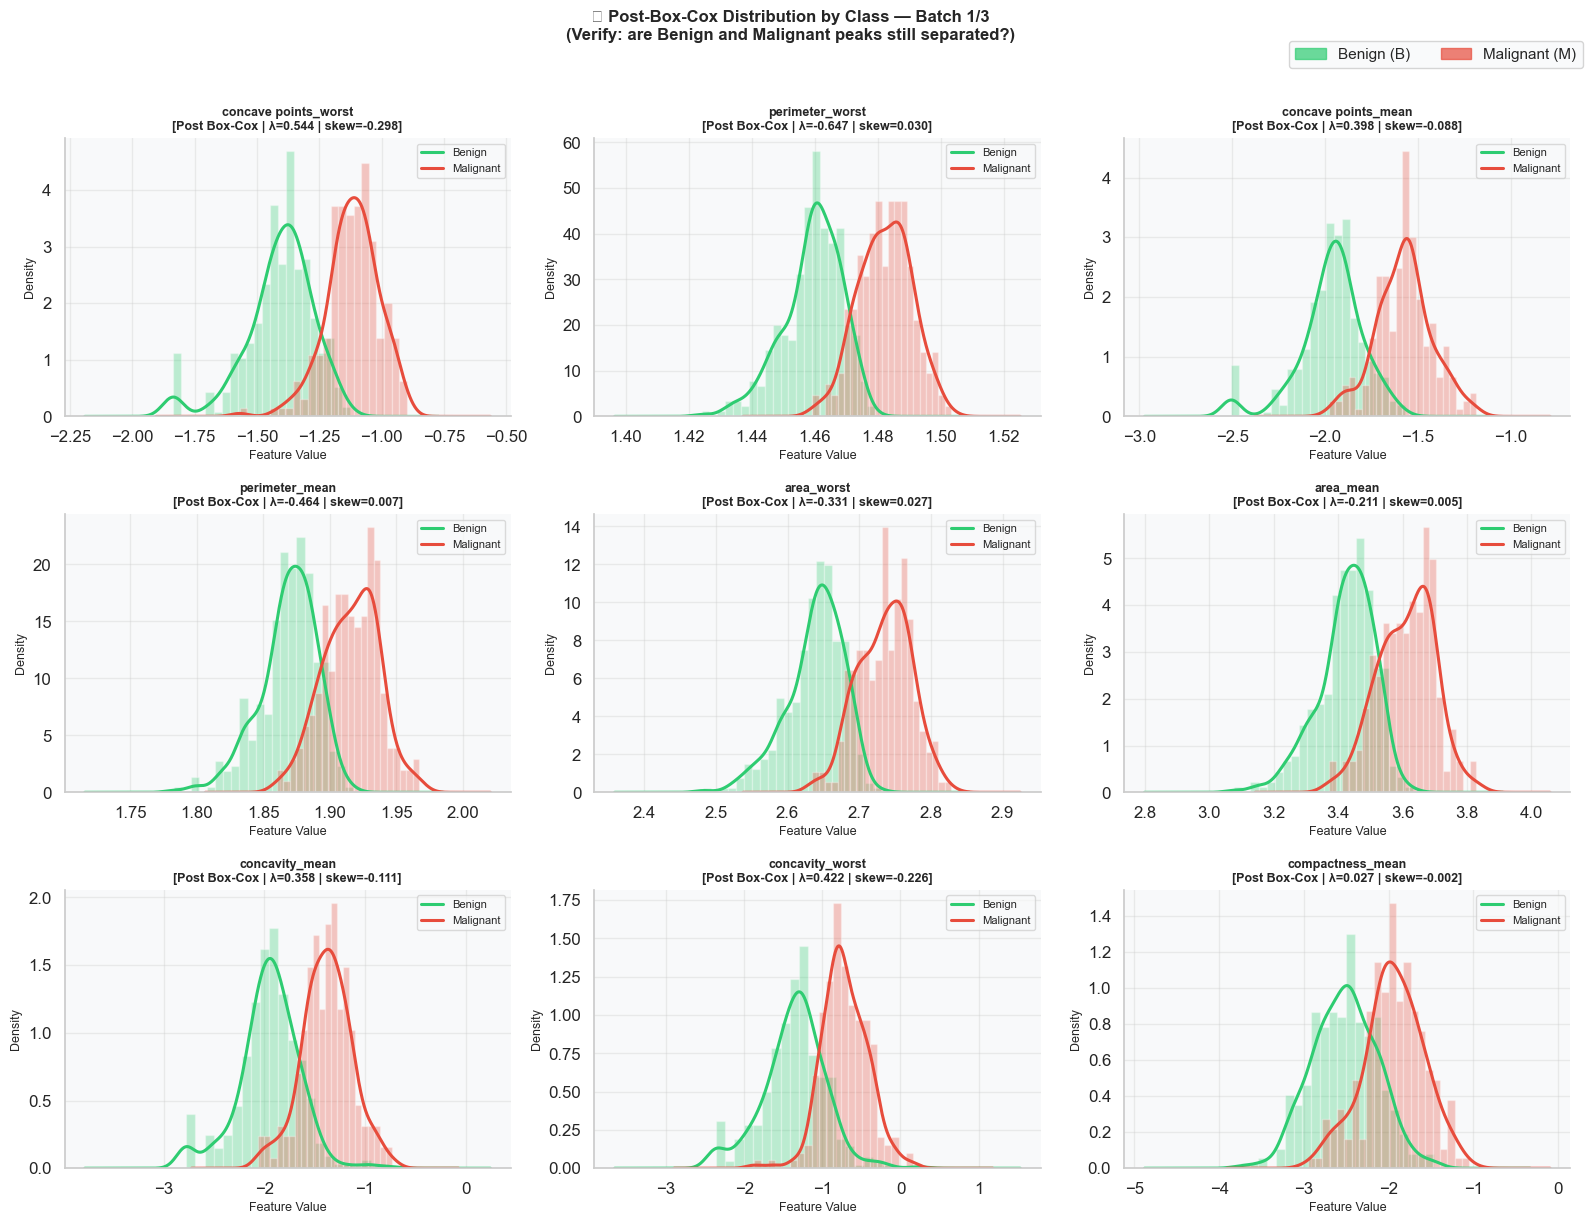

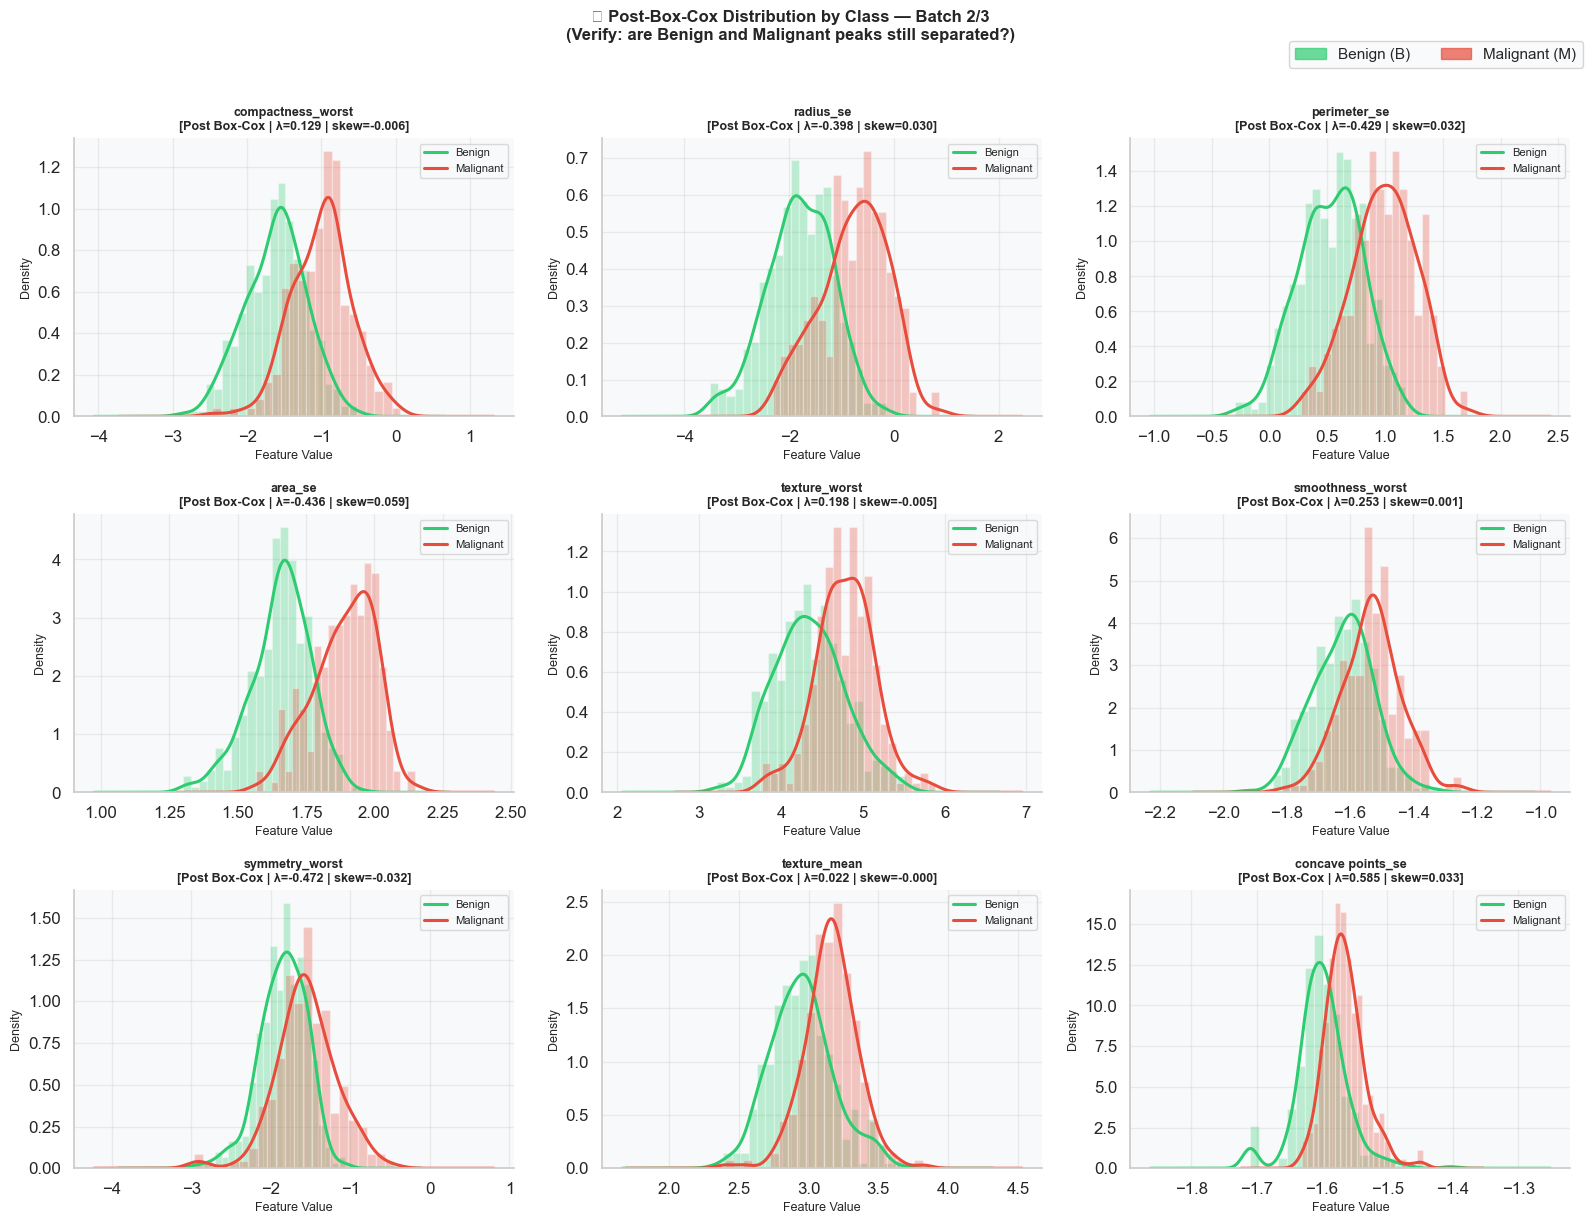

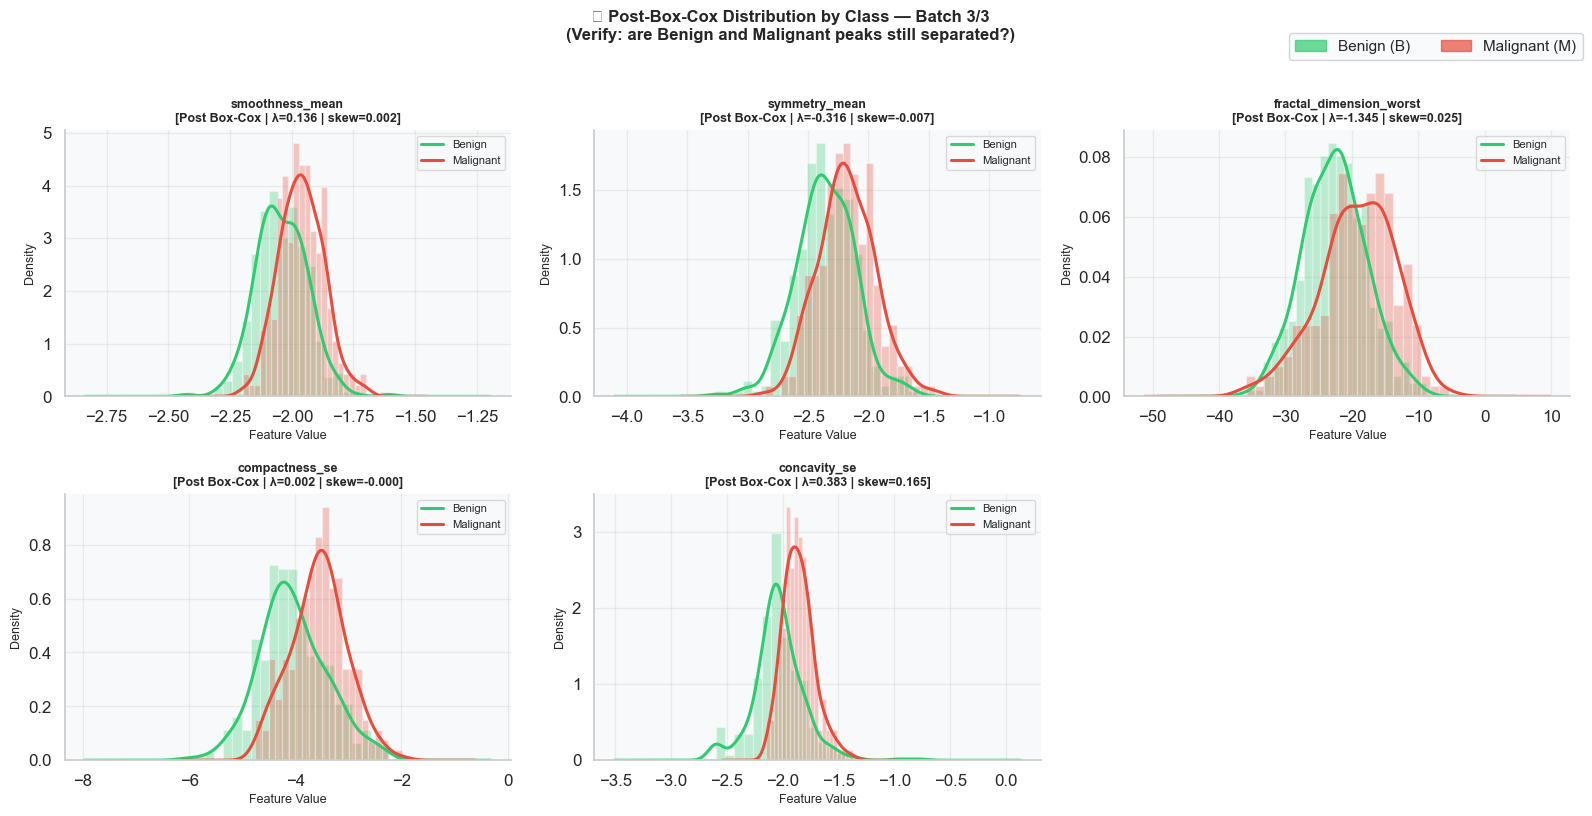

✅ Post-transformation distributions complete.


In [21]:
print("📊 Visualizing Post-Box-Cox distributions by class...")

bc_batch_size = 9
bc_n_batches  = math.ceil(len(selected_features) / bc_batch_size)

for bi in range(bc_n_batches):
    batch = selected_features[bi * bc_batch_size : (bi + 1) * bc_batch_size]
    nr    = math.ceil(len(batch) / 3)
    fig, axes = plt.subplots(nr, 3, figsize=(16, nr * 4))
    axes = np.array(axes).flatten()

    for j, feat in enumerate(batch):
        ax  = axes[j]
        lam = lambda_dict[feat]
        for cls, col, lbl in zip(['B', 'M'], COLORS, ['Benign', 'Malignant']):
            sub = df_transformed[df_transformed[TARGET_COL] == cls][feat]
            ax.hist(sub, bins=22, density=True, alpha=0.30, color=col, edgecolor='white')
            sub.plot.kde(ax=ax, color=col, linewidth=2.2, label=lbl)

        skew_val = df_transformed[feat].skew()
        ax.set_title(f"{feat}\n[Post Box-Cox | λ={lam:.3f} | skew={skew_val:.3f}]",
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Feature Value', fontsize=9)
        ax.set_ylabel('Density', fontsize=9)
        ax.legend(fontsize=8, framealpha=0.7)

    for k in range(len(batch), len(axes)):
        fig.delaxes(axes[k])

    patches = [mpatches.Patch(color=COLORS[0], alpha=0.7, label='Benign (B)'),
               mpatches.Patch(color=COLORS[1], alpha=0.7, label='Malignant (M)')]
    fig.legend(handles=patches, loc='upper right', ncol=2, fontsize=11,
               framealpha=0.8, bbox_to_anchor=(1.0, 1.0))
    fig.suptitle(f"📊 Post-Box-Cox Distribution by Class — Batch {bi+1}/{bc_n_batches}\n"
                 "(Verify: are Benign and Malignant peaks still separated?)",
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout(); plt.show(); plt.close(fig)

print("✅ Post-transformation distributions complete.")

## Section 13: PCA Visualization

**What is PCA used for here?**  
Principal Component Analysis (PCA) is used here **purely as an exploratory visualization tool**, NOT for feature selection or as input to the ML models.

PCA projects the high-dimensional feature space (N features) into 2D or 3D by finding orthogonal axes (principal components) that maximize explained variance.

**What PCA can tell you:**
- Whether the two classes (Benign/Malignant) are linearly separable in the reduced space
- How much of the total variance is captured by the first few components (Scree Plot)
- The centroid distance between classes

**What PCA CANNOT do for this pipeline:**
- PCA components are **linear combinations of ALL input features**, they are not individual features
- A high explained-variance PC does not mean you should keep only the top-N original features
- Using PC scores as model input discards interpretability entirely

**How to determine the optimal number of input features (for each model)?**  
PCA is not the right tool. The correct approach is in Section 14: **cross-validation over feature subsets ranked by Mutual Information score**.

PC1=53.18%  PC2=15.62%  PC3=7.54%  Total=76.34%


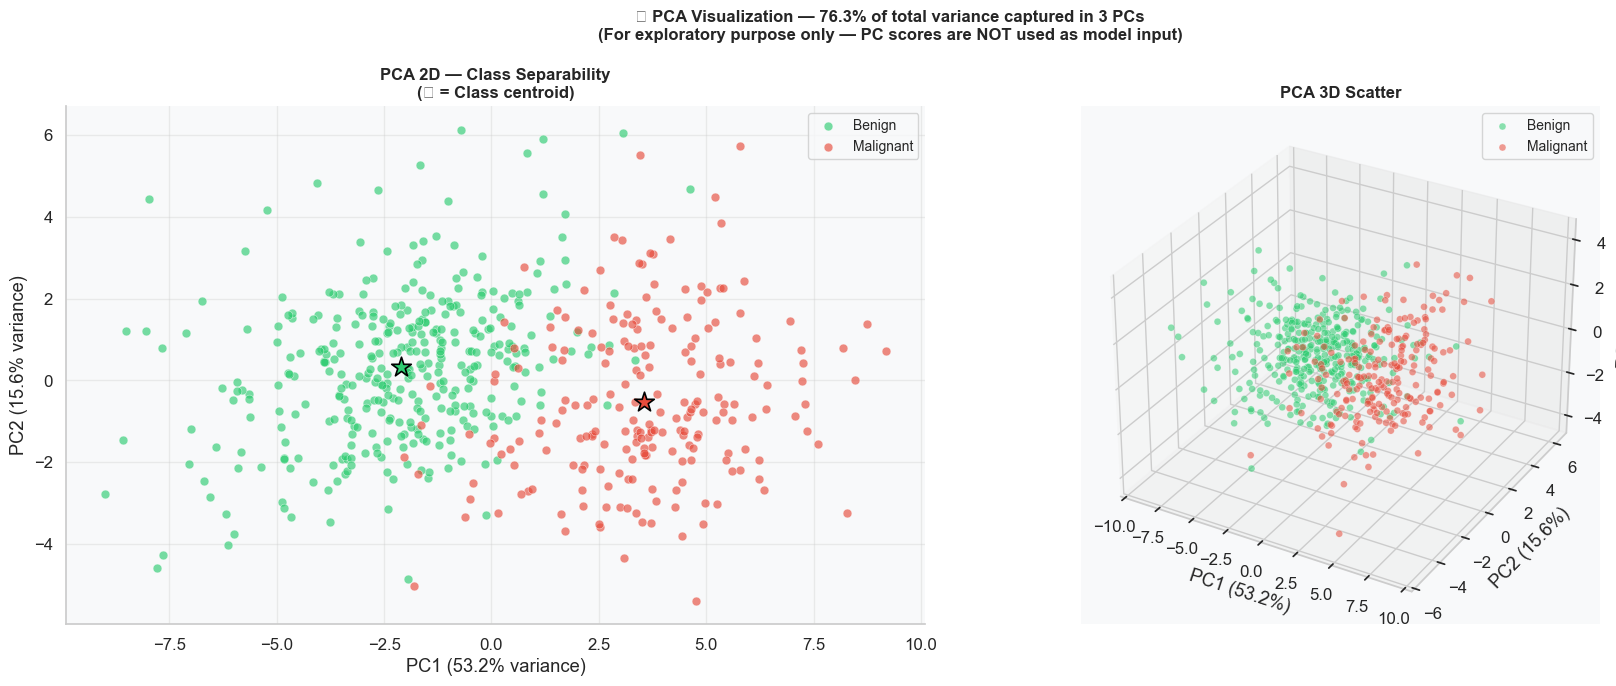

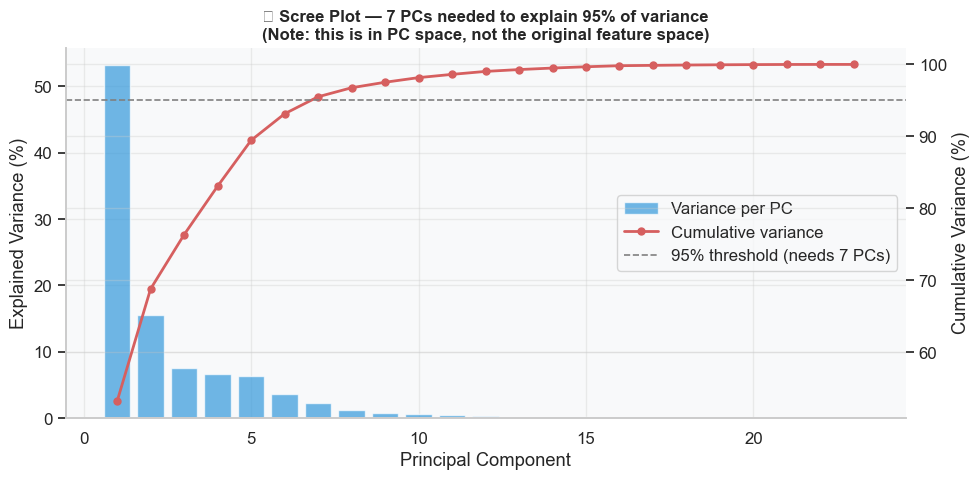

✅ PCA visualization complete.


In [22]:
# Standardize before PCA (PCA is sensitive to scale)
scaler_pca = StandardScaler()
X_for_pca  = scaler_pca.fit_transform(df_transformed[selected_features].values)
y_pca      = df_transformed[TARGET_COL].map({'B': 0, 'M': 1}).values

pca3 = PCA(n_components=3, random_state=SEED)
X_p3 = pca3.fit_transform(X_for_pca)
ev   = pca3.explained_variance_ratio_ * 100
print(f"PC1={ev[0]:.2f}%  PC2={ev[1]:.2f}%  PC3={ev[2]:.2f}%  Total={sum(ev):.2f}%")

fig = plt.figure(figsize=(18, 7))

# 2D scatter
ax1 = fig.add_subplot(121)
for lv, ln, c in [(0, 'Benign', COLORS[0]), (1, 'Malignant', COLORS[1])]:
    m = y_pca == lv
    ax1.scatter(X_p3[m, 0], X_p3[m, 1], c=c, label=ln,
                alpha=0.65, s=40, edgecolors='white', linewidths=0.4)
    ax1.scatter(X_p3[m, 0].mean(), X_p3[m, 1].mean(),
                c=c, s=220, marker='*', zorder=5, edgecolors='black', linewidths=1.2)
ax1.set_xlabel(f'PC1 ({ev[0]:.1f}% variance)'); ax1.set_ylabel(f'PC2 ({ev[1]:.1f}% variance)')
ax1.set_title('PCA 2D — Class Separability\n(★ = Class centroid)',
              fontsize=12, fontweight='bold')
ax1.legend(fontsize=10)

# 3D scatter
ax2 = fig.add_subplot(122, projection='3d')
for lv, ln, c in [(0, 'Benign', COLORS[0]), (1, 'Malignant', COLORS[1])]:
    m = y_pca == lv
    ax2.scatter(X_p3[m, 0], X_p3[m, 1], X_p3[m, 2], c=c,
                label=ln, alpha=0.55, s=25, edgecolors='white', linewidths=0.3)
ax2.set_xlabel(f'PC1 ({ev[0]:.1f}%)'); ax2.set_ylabel(f'PC2 ({ev[1]:.1f}%)')
ax2.set_zlabel(f'PC3 ({ev[2]:.1f}%)')
ax2.set_title('PCA 3D Scatter', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)

fig.suptitle(f'🔵 PCA Visualization — {sum(ev):.1f}% of total variance captured in 3 PCs\n'
             '(For exploratory purpose only — PC scores are NOT used as model input)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Scree plot
pca_full = PCA(random_state=SEED).fit(X_for_pca)
cumv     = np.cumsum(pca_full.explained_variance_ratio_ * 100)
n95      = np.argmax(cumv >= 95) + 1

fig2, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
       pca_full.explained_variance_ratio_ * 100,
       color='#3498db', alpha=0.7, label='Variance per PC')
ax2b = ax.twinx()
ax2b.plot(range(1, len(cumv) + 1), cumv, 'r-o', markersize=5, linewidth=2,
          label='Cumulative variance')
ax2b.axhline(95, color='gray', linestyle='--', linewidth=1.2,
             label=f'95% threshold (needs {n95} PCs)')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax2b.set_ylabel('Cumulative Variance (%)')
ax.set_title(f'📊 Scree Plot — {n95} PCs needed to explain 95% of variance\n'
             '(Note: this is in PC space, not the original feature space)',
             fontsize=12, fontweight='bold')
lines1, lbls1 = ax.get_legend_handles_labels()
lines2, lbls2 = ax2b.get_legend_handles_labels()
ax.legend(lines1 + lines2, lbls1 + lbls2, loc='center right')
plt.tight_layout(); plt.show()
print("✅ PCA visualization complete.")

## Section 14: Optimal Feature Count (Cross-Validation)

**Why cross-validation, not PCA, to determine feature count?**  
PCA tells you how many *principal components* explain the variance, but those are not original features.  
To select the optimal number of **original features** to pass into each model, we:

1. Rank features by Mutual Information score (captures non-linear importance)  
2. Incrementally add features from top to bottom (top-N selection)  
3. Evaluate each subset via Stratified K-Fold cross-validation using RF as a fast proxy model  
4. Select the N where CV score plateaus or peaks

This gives a data-driven, model-informed feature count, not an arbitrary threshold.  
The point where the CV score stops improving meaningfully is the optimal trade-off between  
feature richness and model complexity.

⏳ Running cross-validation over feature subsets (proxy model: Random Forest)...
   Features are added in descending order of Mutual Information score

  Top- 5 features → F1 = 0.9236 ± 0.0308
  Top-10 features → F1 = 0.9257 ± 0.0275
  Top-15 features → F1 = 0.9331 ± 0.0225
  Top-20 features → F1 = 0.9473 ± 0.0179
  Top-23 features → F1 = 0.9323 ± 0.0233

📍 Peak F1 at   : Top-20 features  (F1 = 0.9473)
📍 Plateau start: Top-20 features  (within 0.005 of peak)
   → Recommended: use top-20 features (efficient plateau)


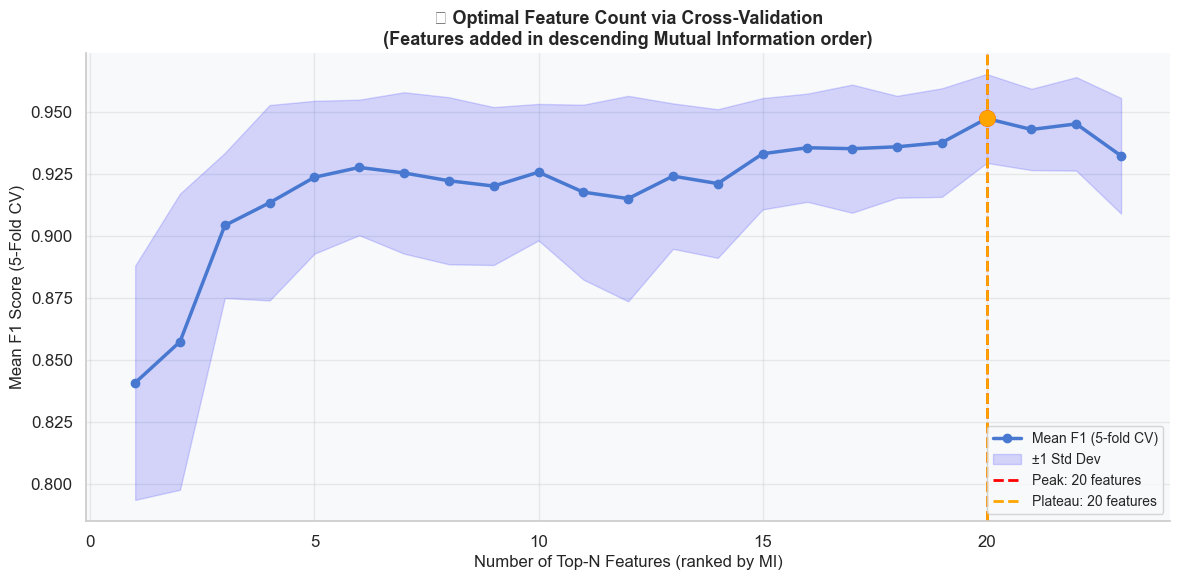


✅ Optimal feature set: 20 features
   ['perimeter_worst', 'area_worst', 'concave points_mean', 'concave points_worst', 'perimeter_mean', 'concavity_mean', 'area_mean', 'area_se', 'concavity_worst', 'perimeter_se', 'radius_se', 'compactness_worst', 'compactness_mean', 'concave points_se', 'texture_worst', 'concavity_se', 'smoothness_worst', 'texture_mean', 'symmetry_worst', 'smoothness_mean']


In [23]:
print("⏳ Running cross-validation over feature subsets (proxy model: Random Forest)...")
print("   Features are added in descending order of Mutual Information score\n")

# Feature order from MI ranking (score_df is already sorted by MI_Score)
mi_ranked_feats = score_df['Feature'].tolist()

# Use only features present in selected_features (some may have been dropped)
mi_ranked_feats = [f for f in mi_ranked_feats if f in selected_features]

cv       = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
proxy_rf = RandomForestClassifier(n_estimators=100, max_depth=8,
                                   n_jobs=-1, random_state=SEED)

X_cv_full = df_transformed[mi_ranked_feats].values
y_cv      = df_transformed[TARGET_COL].map({'B': 0, 'M': 1}).values.astype(int)

cv_results = []
for k in range(1, len(mi_ranked_feats) + 1):
    X_k    = X_cv_full[:, :k]
    scores = cross_val_score(proxy_rf, X_k, y_cv, cv=cv,
                              scoring='f1', n_jobs=-1)
    cv_results.append({'n_features': k, 'mean_f1': scores.mean(),
                       'std_f1': scores.std()})
    if k % 5 == 0 or k == len(mi_ranked_feats):
        print(f"  Top-{k:2d} features → F1 = {scores.mean():.4f} ± {scores.std():.4f}")

cv_df = pd.DataFrame(cv_results)

# Find optimal point
optimal_n = cv_df.loc[cv_df['mean_f1'].idxmax(), 'n_features']
plateau_n = cv_df[cv_df['mean_f1'] >= cv_df['mean_f1'].max() - 0.005]['n_features'].min()

print(f"\n📍 Peak F1 at   : Top-{optimal_n} features  (F1 = {cv_df.loc[cv_df['mean_f1'].idxmax(), 'mean_f1']:.4f})")
print(f"📍 Plateau start: Top-{plateau_n} features  (within 0.005 of peak)")
print(f"   → Recommended: use top-{plateau_n} features (efficient plateau)")

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cv_df['n_features'], cv_df['mean_f1'],
        'b-o', linewidth=2.5, markersize=6, label='Mean F1 (5-fold CV)')
ax.fill_between(cv_df['n_features'],
                cv_df['mean_f1'] - cv_df['std_f1'],
                cv_df['mean_f1'] + cv_df['std_f1'],
                alpha=0.15, color='blue', label='±1 Std Dev')
ax.axvline(optimal_n, color='red', linestyle='--', linewidth=2,
           label=f'Peak: {optimal_n} features')
ax.axvline(plateau_n, color='orange', linestyle='--', linewidth=2,
           label=f'Plateau: {plateau_n} features')
ax.scatter([optimal_n], [cv_df.loc[cv_df['n_features'] == optimal_n, 'mean_f1'].values[0]],
           color='red', s=120, zorder=5)
ax.scatter([plateau_n], [cv_df.loc[cv_df['n_features'] == plateau_n, 'mean_f1'].values[0]],
           color='orange', s=120, zorder=5)
ax.set_xlabel('Number of Top-N Features (ranked by MI)', fontsize=12)
ax.set_ylabel('Mean F1 Score (5-Fold CV)', fontsize=12)
ax.set_title('🎯 Optimal Feature Count via Cross-Validation\n'
             '(Features added in descending Mutual Information order)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.4)
plt.tight_layout(); plt.show()

# Set optimal feature set for training
OPTIMAL_N       = plateau_n
optimal_features = mi_ranked_feats[:OPTIMAL_N]
print(f"\n✅ Optimal feature set: {OPTIMAL_N} features")
print(f"   {optimal_features}")

## Section 15: Preprocessing with Stratified Split, SMOTE and Model-Aware Scaling

**Pipeline design:**
- **Stratified split** first (preserves class ratio in both train and test)
- **SMOTE applied only on training set**: test set must represent the true (imbalanced) distribution
- **Scaling is model-aware**:
  - RF and XGBoost: unscaled data (tree splits are rank-invariant)
  - SVM and ANN: StandardScaler (required, both are sensitive to feature magnitude)

In [24]:
print("=" * 65)
print("🏋️  PREPROCESSING PIPELINE")
print("=" * 65)

# Use the optimal feature set
X_all = df_transformed[optimal_features].values
y_all = df_transformed[TARGET_COL].map({'B': 0, 'M': 1}).values.astype(int)

print(f"\n[1] Feature set  : {len(optimal_features)} features (top-{OPTIMAL_N} by MI, CV-validated)")
print(f"    Dataset shape : {X_all.shape}  |  "
      f"Benign={sum(y_all==0)}, Malignant={sum(y_all==1)}")

# Stratified split
def stratified_split(X, y, test_size=0.25, rs=42):
    np.random.seed(rs)
    train_idx, test_idx = [], []
    for cls in np.unique(y):
        idx = np.where(y == cls)[0]
        np.random.shuffle(idx)
        n_t = int(len(idx) * test_size)
        test_idx.extend(idx[:n_t]); train_idx.extend(idx[n_t:])
    ti, vi = np.array(train_idx), np.array(test_idx)
    np.random.shuffle(ti); np.random.shuffle(vi)
    return X[ti], X[vi], y[ti], y[vi]

X_train_raw, X_test_raw, y_train_raw, y_test = stratified_split(X_all, y_all)
print(f"\n[2] Train/Test split (75/25 stratified):")
print(f"    Train → Benign: {sum(y_train_raw==0)}, Malignant: {sum(y_train_raw==1)}, Total: {len(y_train_raw)}")
print(f"    Test  → Benign: {sum(y_test==0)},  Malignant: {sum(y_test==1)},  Total: {len(y_test)}")

# SMOTE (training only)
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_raw, y_train_raw)
print(f"\n[3] SMOTE (train only):")
print(f"    Before → Benign: {sum(y_train_raw==0)}, Malignant: {sum(y_train_raw==1)}")
print(f"    After  → Benign: {sum(y_train_res==0)}, Malignant: {sum(y_train_res==1)}")

# Model-aware scaling
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_res)   # fit ONLY on train
X_test_sc  = scaler.transform(X_test_raw)

# Tree-based models use unscaled data
X_train_tree = X_train_res
X_test_tree  = X_test_raw

N_FEATURES = X_train_sc.shape[1]
print(f"\n[4] Data ready:")
print(f"    RF & XGBoost → X_train_tree {X_train_tree.shape} (unscaled)")
print(f"    SVM & ANN    → X_train_sc   {X_train_sc.shape}   (StandardScaler)")
print("\n✅ Preprocessing complete!")

🏋️  PREPROCESSING PIPELINE

[1] Feature set  : 20 features (top-20 by MI, CV-validated)
    Dataset shape : (569, 20)  |  Benign=357, Malignant=212

[2] Train/Test split (75/25 stratified):
    Train → Benign: 268, Malignant: 159, Total: 427
    Test  → Benign: 89,  Malignant: 53,  Total: 142

[3] SMOTE (train only):
    Before → Benign: 268, Malignant: 159
    After  → Benign: 268, Malignant: 268

[4] Data ready:
    RF & XGBoost → X_train_tree (536, 20) (unscaled)
    SVM & ANN    → X_train_sc   (536, 20)   (StandardScaler)

✅ Preprocessing complete!


## Section 16: XGBoost Training (GPU, L1+L2 Regularization)

**Regularization parameters used:**
- `reg_alpha`: (L1/Lasso): encourages sparse feature weights; drives weak features toward zero
- `reg_lambda`: (L2/Ridge): penalizes large weights; prevents any single feature from dominating
- `gamma`: minimum loss reduction required for a node split (structural regularization)
- `min_child_weight`: minimum sum of instance weights in a leaf (prevents overfitting on small groups)

**Data input**: unscaled Box-Cox transformed features (tree-based, scale invariant)

In [25]:
print("=" * 60)
print(f"⚡  XGBoost [device={XGB_DEVICE.upper()}, unscaled data]")
print("=" * 60)

t0 = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    gamma             = 0.1,        # structural regularization
    reg_alpha         = 0.1,        # L1
    reg_lambda        = 1.0,        # L2
    min_child_weight  = 3,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    device            = XGB_DEVICE,
    random_state      = SEED,
    verbosity         = 0
)
xgb_model.fit(X_train_tree, y_train_res,
              eval_set=[(X_test_tree, y_test)], verbose=False)
xgb_time = time.time() - t0

y_pred_xgb = xgb_model.predict(X_test_tree)
y_prob_xgb = xgb_model.predict_proba(X_test_tree)[:, 1]
print(f"✅ {xgb_time:.2f}s  Acc={accuracy_score(y_test, y_pred_xgb)*100:.2f}%  "
      f"F1={f1_score(y_test, y_pred_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=['Benign', 'Malignant']))

⚡  XGBoost [device=CUDA, unscaled data]
✅ 2.41s  Acc=95.07%  F1=0.9346
              precision    recall  f1-score   support

      Benign       0.97      0.96      0.96        89
   Malignant       0.93      0.94      0.93        53

    accuracy                           0.95       142
   macro avg       0.95      0.95      0.95       142
weighted avg       0.95      0.95      0.95       142



In [26]:
# Save XGBoost model (.json: XGBoost native format)
import os

xgb_path = os.path.join(MODELS_DIR, 'xgboost_model.json')
xgb_model.save_model(xgb_path)
xgb_sz   = os.path.getsize(xgb_path) / 1024

print(f"{'='*55}")
print(f"  XGBoost model saved  (.json)")
print(f"  Path   : {os.path.abspath(xgb_path)}")
print(f"  Size   : {xgb_sz:.1f} KB")
print(f"  Device : {XGB_DEVICE}  |  Trees : {xgb_model.n_estimators}")
print(f"{'='*55}")
print("  Reload example:")
print("    import xgboost as xgb")
print("    model = xgb.XGBClassifier()")
print(f"    model.load_model('{xgb_path}')")

  XGBoost model saved  (.json)
  Path   : c:\Users\Sem 6\Multimodal Biomedical Data Analysis\5023231017_Jeremia Christ Immanuel Manalu_Assignment 1_MBDA\saved_models\xgboost_model.json
  Size   : 195.8 KB
  Device : cuda  |  Trees : 300
  Reload example:
    import xgboost as xgb
    model = xgb.XGBClassifier()
    model.load_model('./saved_models\xgboost_model.json')


## Section 17: Random Forest Training (Implicit Regularization)

**Regularization in RF (implicit — no explicit L1/L2):**
- `max_depth`: limits tree growth (prevents memorizing training noise)
- `min_samples_leaf`: each leaf must contain ≥N samples (prevents overly-specific splits)
- `max_features='sqrt'`: each split considers only √(n_features) features, introduces diversity, prevents any one feature from dominating

**Data input**: unscaled (tree-based, scale invariant)

In [27]:
print("=" * 60)
if CUML_AVAILABLE:
    print("🌲  Random Forest [cuML — GPU, unscaled data]")
else:
    print("🌲  Random Forest [sklearn — CPU, unscaled data]")
print("=" * 60)

t0 = time.time()
if CUML_AVAILABLE:
    rf_model = cuRF(n_estimators=300, max_depth=10,
                    max_features='sqrt', random_state=SEED)
else:
    rf_model = RandomForestClassifier(
        n_estimators      = 300,
        max_depth         = 10,
        min_samples_split = 5,
        min_samples_leaf  = 2,
        max_features      = 'sqrt',
        class_weight      = 'balanced',
        oob_score         = True,
        n_jobs            = -1,
        random_state      = SEED
    )
rf_model.fit(X_train_tree, y_train_res)
rf_time = time.time() - t0

y_pred_rf = rf_model.predict(X_test_tree)
y_prob_rf  = rf_model.predict_proba(X_test_tree)[:, 1]
print(f"✅ {rf_time:.2f}s  Acc={accuracy_score(y_test, y_pred_rf)*100:.2f}%  "
      f"F1={f1_score(y_test, y_pred_rf):.4f}")
if not CUML_AVAILABLE and hasattr(rf_model, 'oob_score_'):
    print(f"   OOB Score: {rf_model.oob_score_*100:.2f}%")
print(classification_report(y_test, y_pred_rf, target_names=['Benign', 'Malignant']))

🌲  Random Forest [sklearn — CPU, unscaled data]
✅ 0.47s  Acc=95.07%  F1=0.9346
   OOB Score: 97.20%
              precision    recall  f1-score   support

      Benign       0.97      0.96      0.96        89
   Malignant       0.93      0.94      0.93        53

    accuracy                           0.95       142
   macro avg       0.95      0.95      0.95       142
weighted avg       0.95      0.95      0.95       142



In [28]:
# Save Random Forest model (.pkl via joblib)
import joblib, os

rf_path = os.path.join(MODELS_DIR, 'random_forest_model.pkl')
joblib.dump(rf_model, rf_path, compress=3)
rf_sz   = os.path.getsize(rf_path) / 1024

n_est   = rf_model.n_estimators if hasattr(rf_model, 'n_estimators') else 'N/A'
oob     = (f"{rf_model.oob_score_*100:.2f}%"
           if hasattr(rf_model, 'oob_score_') else 'N/A')

print(f"{'='*55}")
print(f"  Random Forest model saved  (.pkl)")
print(f"  Path        : {os.path.abspath(rf_path)}")
print(f"  Size        : {rf_sz:.1f} KB")
print(f"  Estimators  : {n_est}  |  OOB Score : {oob}")
print(f"{'='*55}")
print("  Reload example:")
print("    import joblib")
print(f"    rf = joblib.load('{rf_path}')")

  Random Forest model saved  (.pkl)
  Path        : c:\Users\Sem 6\Multimodal Biomedical Data Analysis\5023231017_Jeremia Christ Immanuel Manalu_Assignment 1_MBDA\saved_models\random_forest_model.pkl
  Size        : 190.4 KB
  Estimators  : 300  |  OOB Score : 97.20%
  Reload example:
    import joblib
    rf = joblib.load('./saved_models\random_forest_model.pkl')


## Section 18: SVM Training (C-regularization, REQUIRES scaling)

**Regularization in SVM:**
- `C` parameter = inverse regularization strength. Small C → large margin, more misclassifications tolerated → stronger regularization. Large C → fits training data tightly → weaker regularization
- The RBF kernel implicitly maps features to a higher-dimensional space, reducing the impact of linear collinearity

**Data input**: StandardScaled (REQUIRED, RBF kernel uses Euclidean distance, which is scale-dependent)

In [29]:
print("=" * 60)
if CUML_AVAILABLE:
    print("🎯  SVM [cuML — GPU, SCALED data]")
else:
    print("🎯  SVM [sklearn — CPU, SCALED data]")
print("   Data: StandardScaler applied (required for RBF kernel)")
print("=" * 60)

t0 = time.time()
if CUML_AVAILABLE:
    svm_model = cuSVC(C=10.0, kernel='rbf', gamma='scale',
                       probability=True, random_state=SEED)
else:
    svm_model = SVC(
        C            = 10.0,
        kernel       = 'rbf',
        gamma        = 'scale',    # = 1 / (n_features * X.var())
        class_weight = 'balanced',
        probability  = True,
        random_state = SEED
    )
svm_model.fit(X_train_sc, y_train_res)
svm_time = time.time() - t0

y_pred_svm = svm_model.predict(X_test_sc)
y_prob_svm  = svm_model.predict_proba(X_test_sc)[:, 1]
print(f"✅ {svm_time:.2f}s  Acc={accuracy_score(y_test, y_pred_svm)*100:.2f}%  "
      f"F1={f1_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm, target_names=['Benign', 'Malignant']))

🎯  SVM [sklearn — CPU, SCALED data]
   Data: StandardScaler applied (required for RBF kernel)
✅ 0.02s  Acc=95.77%  F1=0.9434
              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97        89
   Malignant       0.94      0.94      0.94        53

    accuracy                           0.96       142
   macro avg       0.95      0.95      0.95       142
weighted avg       0.96      0.96      0.96       142



In [30]:
# Save SVM model (.pkl via joblib)
import joblib, os

svm_path = os.path.join(MODELS_DIR, 'svm_model.pkl')
joblib.dump(svm_model, svm_path, compress=3)
svm_sz   = os.path.getsize(svm_path) / 1024

print(f"{'='*55}")
print(f"  SVM model saved  (.pkl)")
print(f"  Path   : {os.path.abspath(svm_path)}")
print(f"  Size   : {svm_sz:.1f} KB")
print(f"  Kernel : RBF  |  C={svm_model.C}  |  gamma=scale")
print(f"{'='*55}")
print("  Reload example:")
print("    import joblib")
print(f"    svm = joblib.load('{svm_path}')")

  SVM model saved  (.pkl)
  Path   : c:\Users\Sem 6\Multimodal Biomedical Data Analysis\5023231017_Jeremia Christ Immanuel Manalu_Assignment 1_MBDA\saved_models\svm_model.pkl
  Size   : 10.6 KB
  Kernel : RBF  |  C=10.0  |  gamma=scale
  Reload example:
    import joblib
    svm = joblib.load('./saved_models\svm_model.pkl')


## Section 19: ANN Training (PyTorch GPU, Explicit Regularization)

**Regularization in ANN (must be declared explicitly):**
- `weight_decay=1e-4`: in AdamW → L2 weight regularization applied to all linear layers
- `Dropout(p)` → randomly zeros p% of neurons during training → prevents co-adaptation → implicit ensemble effect
- `BatchNorm1d` → normalizes layer inputs → reduces internal covariate shift → smoother gradient flow, acts as mild regularizer
- Gradient clipping (`max_norm=1.0`) → prevents exploding gradients

**Data input**: StandardScaled (REQUIRED, gradient descent converges poorly with unnormalized features; BatchNorm does not replace input normalization)

In [31]:
print("=" * 60)
print(f"🧠  ANN [PyTorch — {str(DEVICE).upper()}, SCALED data]")
print("   Regularization: weight_decay (L2) + Dropout + BatchNorm + Grad Clipping")
print("=" * 60)

class BreastCancerANN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.30),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.GELU(),
            nn.Dropout(0.20),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1)    # raw logit → BCEWithLogitsLoss
        )
    def forward(self, x): return self.net(x)

X_tr_t = torch.FloatTensor(X_train_sc).to(DEVICE)
X_te_t = torch.FloatTensor(X_test_sc).to(DEVICE)
y_tr_t = torch.FloatTensor(y_train_res).unsqueeze(1).to(DEVICE)
y_te_t = torch.FloatTensor(y_test).unsqueeze(1).to(DEVICE)

cc          = np.bincount(y_train_res)
sample_w    = (1.0 / cc)[y_train_res]
sampler     = WeightedRandomSampler(torch.FloatTensor(sample_w),
                                     len(sample_w), replacement=True)
loader      = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                          batch_size=32, sampler=sampler)

pos_weight  = torch.tensor([cc[0] / cc[1]], dtype=torch.float32).to(DEVICE)
criterion   = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

ann_model   = BreastCancerANN(N_FEATURES).to(DEVICE)
optimizer   = optim.AdamW(ann_model.parameters(), lr=1e-3,
                           weight_decay=1e-4)   # L2 reg here
scheduler   = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150, eta_min=1e-5)

print(ann_model)
print(f"\nTotal parameters: {sum(p.numel() for p in ann_model.parameters()):,}")

EPOCHS = 20
train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_loss = float('inf'); best_state = None
t0 = time.time()

for ep in range(EPOCHS):
    ann_model.train()
    ep_loss, correct, total_n = 0, 0, 0
    for Xb, yb in loader:
        optimizer.zero_grad()
        out  = ann_model(Xb)
        loss = criterion(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(ann_model.parameters(), max_norm=1.0)
        optimizer.step()
        ep_loss += loss.item()
        correct += (torch.sigmoid(out) >= 0.5).float().eq(yb).sum().item()
        total_n += yb.size(0)
    train_losses.append(ep_loss / len(loader)); train_accs.append(correct / total_n)

    ann_model.eval()
    with torch.no_grad():
        vl     = ann_model(X_te_t)
        vl_loss = criterion(vl, y_te_t).item()
        vl_acc  = (torch.sigmoid(vl) >= 0.5).float().eq(y_te_t).float().mean().item()
    val_losses.append(vl_loss); val_accs.append(vl_acc)
    scheduler.step()

    is_best = vl_loss < best_val_loss
    if is_best:
        best_val_loss = vl_loss
        best_state    = copy.deepcopy(ann_model.state_dict())

    # Print every epoch — compact single-line format
    best_tag = "  <-- BEST" if is_best else ""
    print(f"  Epoch [{ep+1:3d}/{EPOCHS}]  "
          f"Train Loss={train_losses[-1]:.4f}  Acc={train_accs[-1]:.4f}  |  "
          f"Val Loss={vl_loss:.4f}  Acc={vl_acc:.4f}  |  "
          f"LR={scheduler.get_last_lr()[0]:.2e}"
          + best_tag)

ann_time = time.time() - t0
ann_model.load_state_dict(best_state); ann_model.eval()
with torch.no_grad():
    y_prob_ann = torch.sigmoid(ann_model(X_te_t)).cpu().numpy().flatten()
y_pred_ann = (y_prob_ann >= 0.5).astype(int)

print(f"\n✅ {ann_time:.2f}s  Acc={accuracy_score(y_test, y_pred_ann)*100:.2f}%  "
      f"F1={f1_score(y_test, y_pred_ann):.4f}")
print(classification_report(y_test, y_pred_ann, target_names=['Benign', 'Malignant']))

🧠  ANN [PyTorch — CUDA, SCALED data]
   Regularization: weight_decay (L2) + Dropout + BatchNorm + Grad Clipping
BreastCancerANN(
  (net): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): GELU(approximate='none')
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): GELU(approximate='none')
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): GELU(approximate='none')
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=16, bias=True)
    (13): ReLU()
    (14): Linear(in_features=16, out_features=1, bias=True)
  )
)

Total parameters: 14,017
  Epoch 

In [32]:
# Save ANN model (.pth)
import os

ann_path = os.path.join(MODELS_DIR, 'ann_model.pth')
torch.save(
    {
        'model_state_dict' : best_state,
        'input_dim'        : N_FEATURES,
        'optimal_features' : optimal_features,
        'scaler_mean'      : scaler.mean_.tolist(),
        'scaler_scale'     : scaler.scale_.tolist(),
        'best_val_loss'    : best_val_loss,
        'epochs_trained'   : EPOCHS,
        'lambda_dict'      : lambda_dict,
        'epsilon_dict'     : epsilon_dict,
    },
    ann_path
)
ann_sz = os.path.getsize(ann_path) / 1024

print(f"{'='*55}")
print(f"  ANN model saved  (.pth)")
print(f"  Path   : {os.path.abspath(ann_path)}")
print(f"  Size   : {ann_sz:.1f} KB")
print(f"  Saved  : model weights, input_dim, feature list,")
print(f"           scaler params, Box-Cox lambdas & epsilons")
print(f"{'='*55}")
print("  Reload example:")
print("    ckpt  = torch.load('ann_model.pth')")
print("    model = BreastCancerANN(ckpt['input_dim'])")
print("    model.load_state_dict(ckpt['model_state_dict'])")
print("    model.eval()")

  ANN model saved  (.pth)
  Path   : c:\Users\Sem 6\Multimodal Biomedical Data Analysis\5023231017_Jeremia Christ Immanuel Manalu_Assignment 1_MBDA\saved_models\ann_model.pth
  Size   : 68.8 KB
  Saved  : model weights, input_dim, feature list,
           scaler params, Box-Cox lambdas & epsilons
  Reload example:
    ckpt  = torch.load('ann_model.pth')
    model = BreastCancerANN(ckpt['input_dim'])
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()


## Section 20: ANN Learning Curves

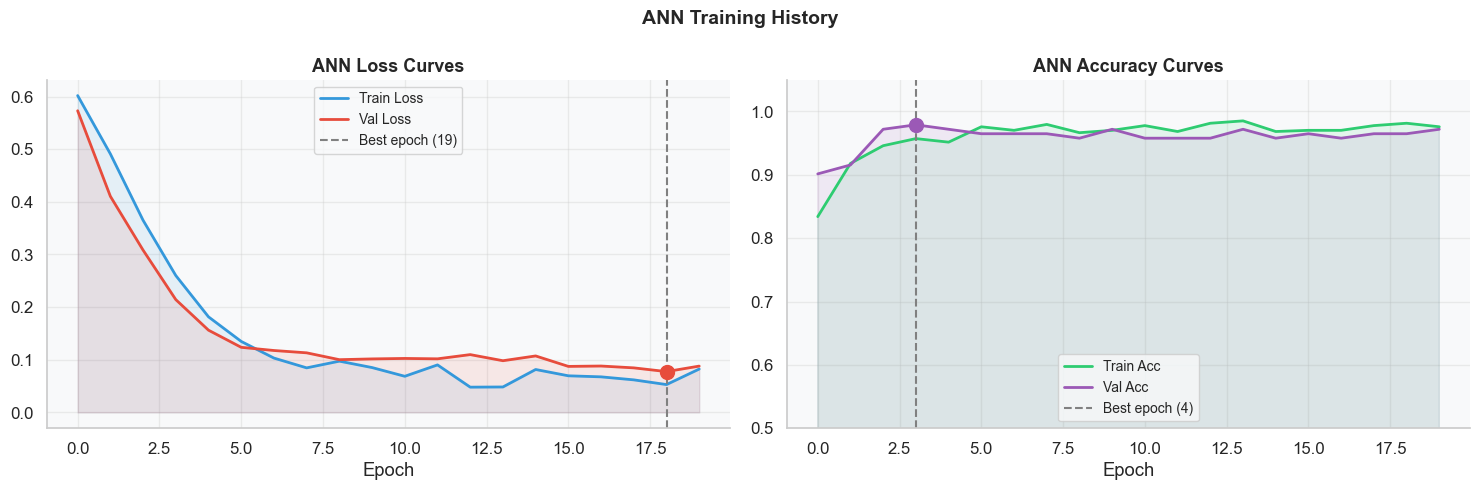

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, y1, y2, lbl1, lbl2, title, c1, c2 in [
    (axes[0], train_losses, val_losses, 'Train Loss', 'Val Loss',
     'Loss Curves', '#3498db', '#e74c3c'),
    (axes[1], train_accs, val_accs, 'Train Acc', 'Val Acc',
     'Accuracy Curves', '#2ecc71', '#9b59b6')
]:
    ax.plot(y1, color=c1, linewidth=2, label=lbl1)
    ax.plot(y2, color=c2, linewidth=2, label=lbl2)
    ax.fill_between(range(EPOCHS), y1, alpha=0.1, color=c1)
    ax.fill_between(range(EPOCHS), y2, alpha=0.1, color=c2)
    best_ep = (np.argmin(y2) if 'Loss' in lbl2 else np.argmax(y2))
    ax.axvline(best_ep, color='gray', linestyle='--', linewidth=1.5,
               label=f'Best epoch ({best_ep+1})')
    ax.scatter([best_ep], [y2[best_ep]], s=100, color=c2, zorder=5)
    ax.set_title(f'ANN {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.legend(fontsize=10)
    if 'Acc' in lbl1: ax.set_ylim(0.5, 1.05)

fig.suptitle('ANN Training History', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Section 21: Model Evaluation with Confusion Matrices, ROC and PR Curves

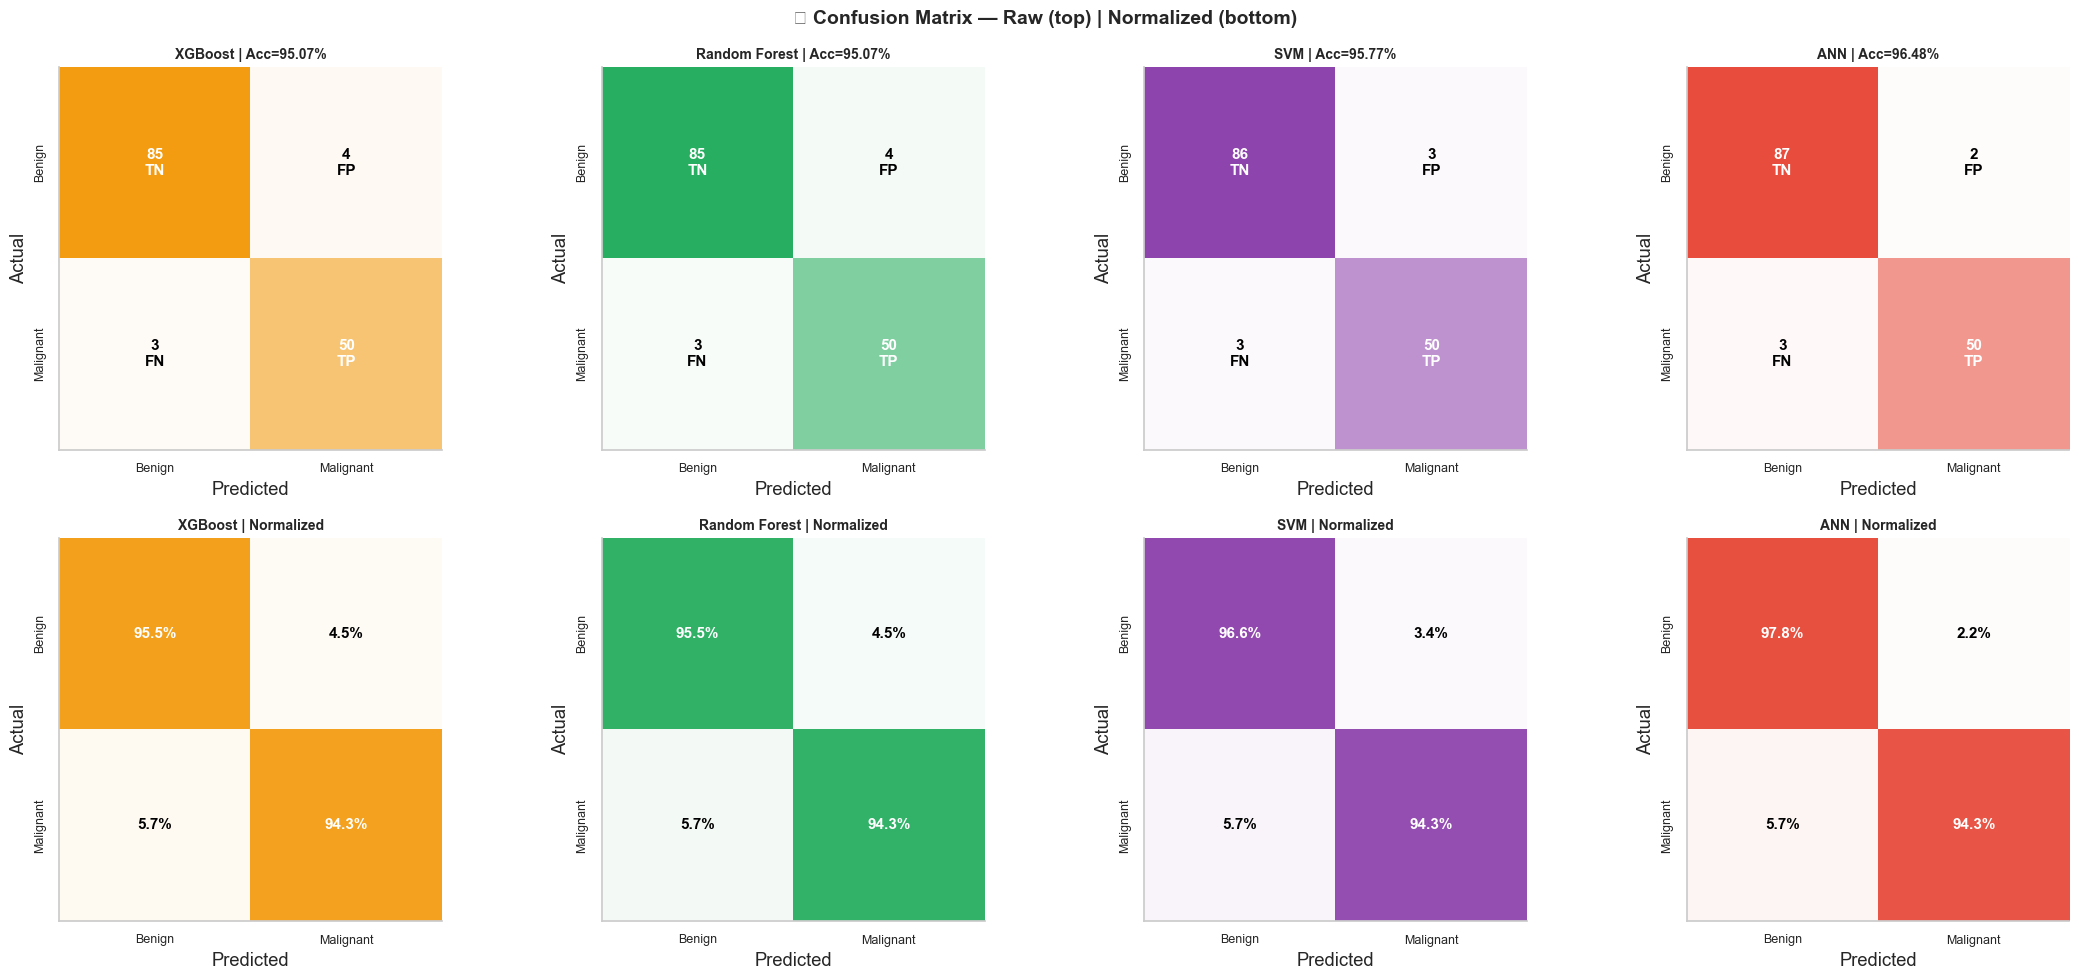

In [34]:
models_eval = [
    ('XGBoost',       y_pred_xgb, y_prob_xgb, '#f39c12'),
    ('Random Forest', y_pred_rf,  y_prob_rf,  '#27ae60'),
    ('SVM',           y_pred_svm, y_prob_svm, '#8e44ad'),
    ('ANN',           y_pred_ann, y_prob_ann, '#e74c3c'),
]
model_colors  = [m[3] for m in models_eval]
model_markers = ['o', 's', '^', 'D']

# Confusion matrices
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
lmap = {(0,0):'TN', (0,1):'FP', (1,0):'FN', (1,1):'TP'}

for col, (name, y_pred, y_prob, color) in enumerate(models_eval):
    cm_m = confusion_matrix(y_test, y_pred)
    acc  = accuracy_score(y_test, y_pred)
    cmap_c = LinearSegmentedColormap.from_list('c', ['#ffffff', color])

    for row_i, (data, sfx) in enumerate([
        (cm_m, f'Acc={acc*100:.2f}%'),
        (cm_m.astype(float) / cm_m.sum(axis=1, keepdims=True), 'Normalized')
    ]):
        ax = axes[row_i, col]
        ax.imshow(data, cmap=cmap_c, interpolation='nearest',
                  vmin=0, vmax=(1.0 if row_i == 1 else None))
        ax.grid(False) 
        ax.set_xticks([0,1]); ax.set_yticks([0,1])
        ax.set_xticklabels(['Benign','Malignant'], fontsize=9)
        ax.set_yticklabels(['Benign','Malignant'], fontsize=9, rotation=90, va='center')
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        ax.set_title(f'{name} | {sfx}', fontsize=10, fontweight='bold')
        thresh = data.max() / 2.0
        for r in range(2):
            for c in range(2):
                val_str = (f'{data[r,c]:.1%}' if row_i == 1
                           else f'{int(data[r,c])}\n{lmap[(r,c)]}')
                ax.text(c, r, val_str, ha='center', va='center',
                        fontsize=11, fontweight='bold',
                        color='white' if data[r,c] > thresh else 'black')

fig.suptitle('📊 Confusion Matrix — Raw (top) | Normalized (bottom)',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

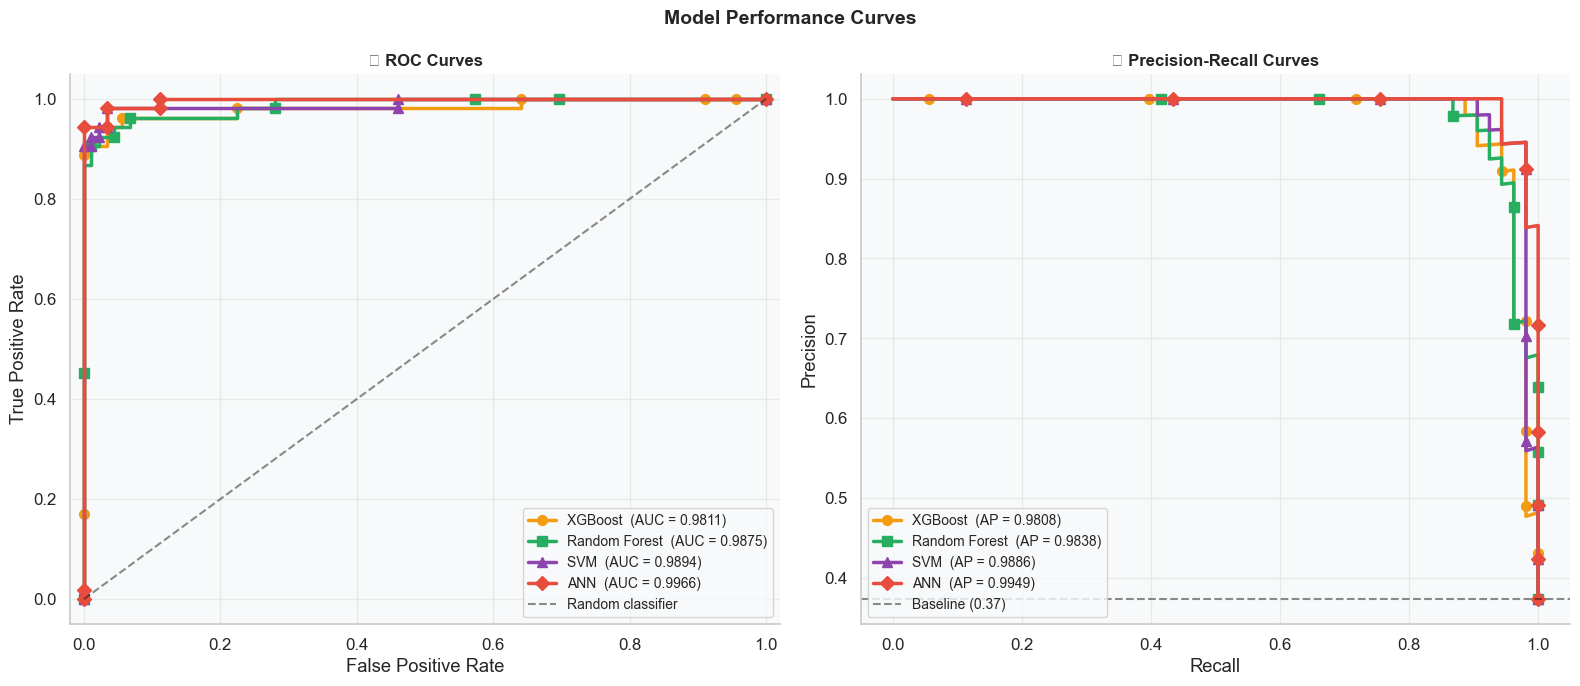

✅ Evaluation complete.


In [35]:
# ROC + PR Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
baseline = sum(y_test == 1) / len(y_test)

for (name, y_pred, y_prob, _), color, marker in zip(models_eval, model_colors, model_markers):
    fpr, tpr, _    = roc_curve(y_test, y_prob)
    roc_auc        = auc(fpr, tpr)
    prec, rec, _   = precision_recall_curve(y_test, y_prob)
    ap             = average_precision_score(y_test, y_prob)

    axes[0].plot(fpr, tpr, color=color, linewidth=2.5, marker=marker,
                 markevery=max(1, len(fpr)//8), markersize=7,
                 label=f'{name}  (AUC = {roc_auc:.4f})')
    axes[1].plot(rec, prec, color=color, linewidth=2.5, marker=marker,
                 markevery=max(1, len(rec)//8), markersize=7,
                 label=f'{name}  (AP = {ap:.4f})')

axes[0].plot([0,1],[0,1],'k--',linewidth=1.5,alpha=0.5,label='Random classifier')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('📈 ROC Curves', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10, loc='lower right'); axes[0].set_xlim(-0.02, 1.02)

axes[1].axhline(baseline, color='k', linestyle='--', linewidth=1.5, alpha=0.5,
                label=f'Baseline ({baseline:.2f})')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('📉 Precision-Recall Curves', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10, loc='lower left')

fig.suptitle('Model Performance Curves', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()
print("✅ Evaluation complete.")

## Section 22: Feature Importance (XGBoost + RF)

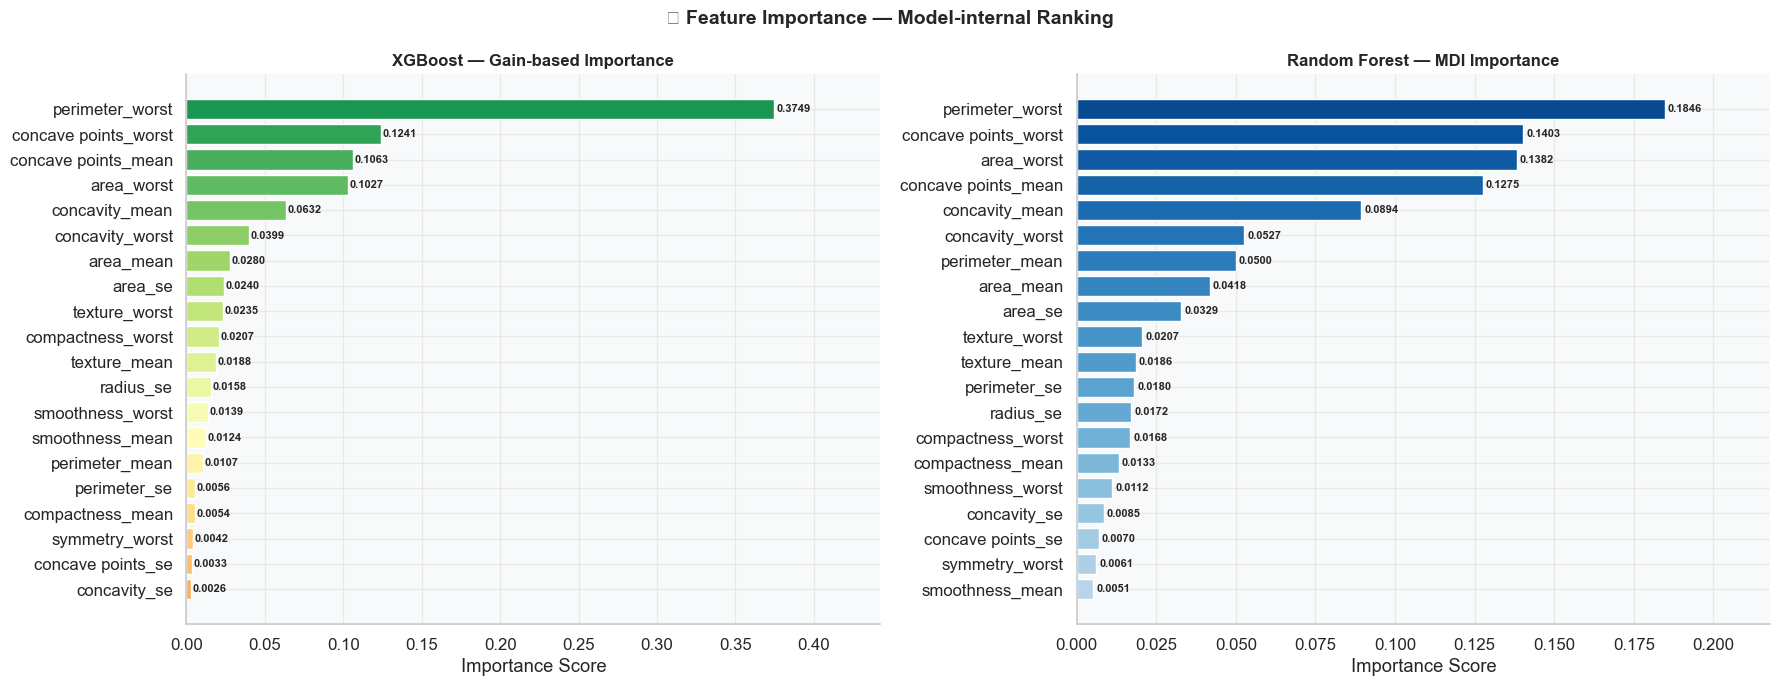

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, (model_obj, name, cmap_name) in zip(axes, [
    (xgb_model, 'XGBoost — Gain-based Importance', 'RdYlGn'),
    (rf_model,  'Random Forest — MDI Importance',  'Blues')
]):
    if hasattr(model_obj, 'feature_importances_'):
        fi = pd.Series(model_obj.feature_importances_,
                       index=optimal_features).sort_values(ascending=True)
        cmap_fi = plt.cm.get_cmap(cmap_name)
        bars = ax.barh(fi.index, fi.values,
                       color=cmap_fi(np.linspace(0.3, 0.9, len(fi))),
                       edgecolor='white')
        for bar, v in zip(bars, fi.values):
            ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                    f'{v:.4f}', va='center', fontsize=8, fontweight='bold')
        ax.set_title(name, fontsize=12, fontweight='bold')
        ax.set_xlabel('Importance Score')
        ax.set_xlim(0, fi.max() * 1.18)

fig.suptitle('🌟 Feature Importance — Model-internal Ranking',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Section 23: Final Model Comparison

🏆 MODEL COMPARISON SUMMARY


,Scaling,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Avg Precision,Sensitivity,Specificity,Train Time
Model,,,,,,,,,,
XGBoost,No,0.9507,0.9259,0.9434,0.9346,0.9811,0.9808,0.9434,0.9551,2.41s
Random Forest,No,0.9507,0.9259,0.9434,0.9346,0.9875,0.9838,0.9434,0.9551,0.47s
SVM,Yes (StandardScaler),0.9577,0.9434,0.9434,0.9434,0.9894,0.9886,0.9434,0.9663,0.02s
ANN,Yes (StandardScaler),0.9648,0.9615,0.9434,0.9524,0.9966,0.9949,0.9434,0.9775,2.07s


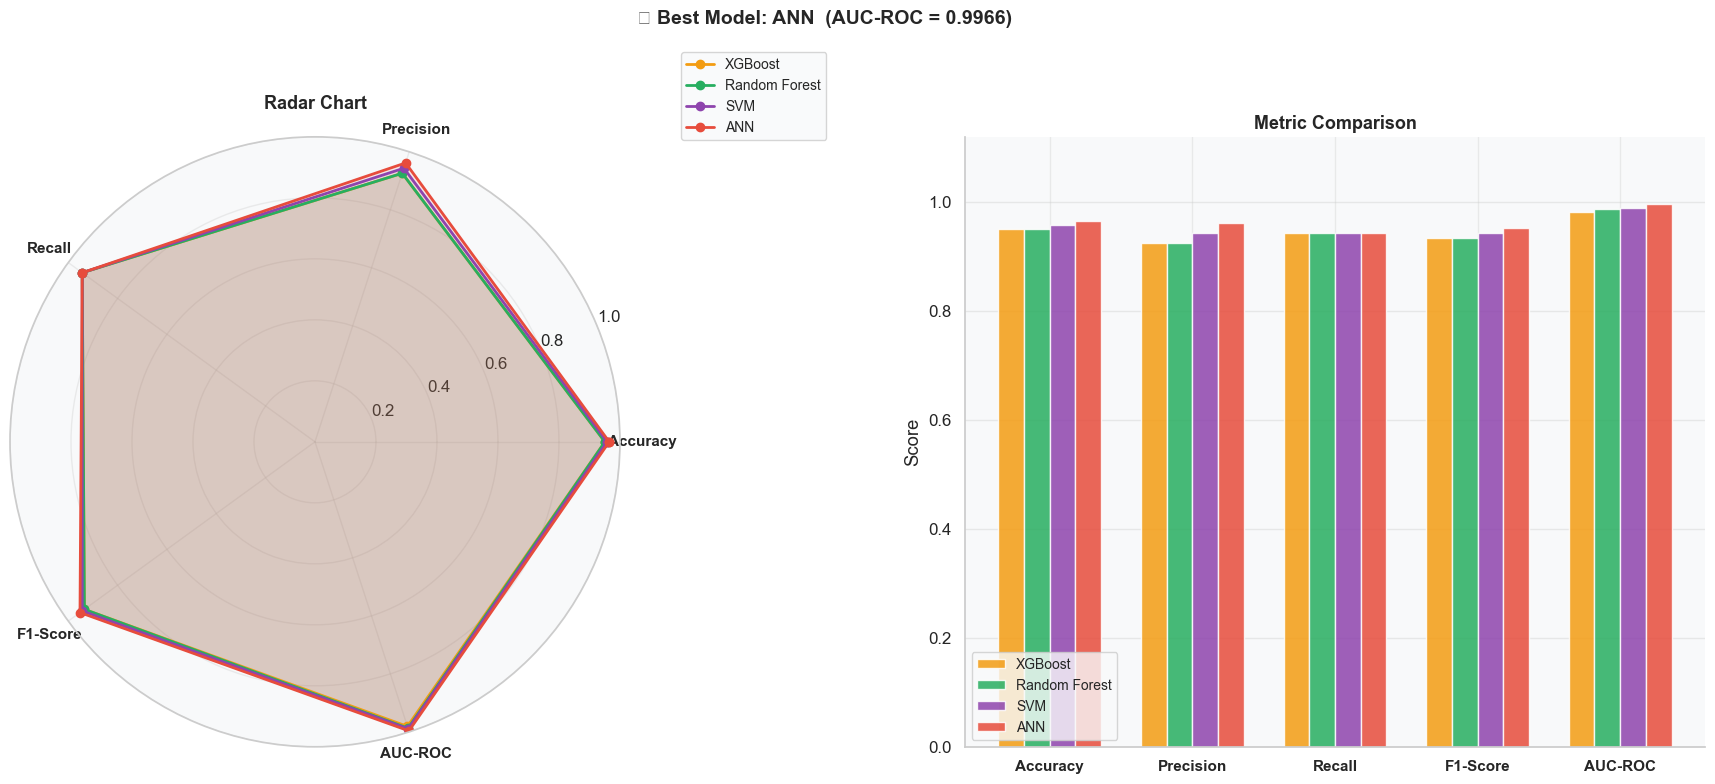


🥇 Best Model: ANN
   AUC-ROC     : 0.9966
   F1-Score    : 0.9524
   Sensitivity : 0.9434
   Specificity : 0.9775

✅ MBDA Assignment 1 Pipeline v3 complete!


In [37]:
timing = {'XGBoost': xgb_time, 'Random Forest': rf_time,
           'SVM': svm_time, 'ANN': ann_time}

results = []
for name, y_pred, y_prob, _ in models_eval:
    cm_m     = confusion_matrix(y_test, y_pred)
    TP, TN   = cm_m[1,1], cm_m[0,0]
    FP, FN   = cm_m[0,1], cm_m[1,0]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    results.append({
        'Model'       : name,
        'Scaling'     : 'No'  if name in ['XGBoost','Random Forest'] else 'Yes (StandardScaler)',
        'Accuracy'    : accuracy_score(y_test, y_pred),
        'Precision'   : precision_score(y_test, y_pred),
        'Recall'      : recall_score(y_test, y_pred),
        'F1-Score'    : f1_score(y_test, y_pred),
        'AUC-ROC'     : auc(fpr, tpr),
        'Avg Precision': average_precision_score(y_test, y_prob),
        'Sensitivity' : TP / (TP + FN) if (TP+FN) > 0 else 0,
        'Specificity' : TN / (TN + FP) if (TN+FP) > 0 else 0,
        'Train Time'  : timing[name]
    })

res_df = pd.DataFrame(results).set_index('Model')
print("🏆 MODEL COMPARISON SUMMARY")
display(res_df.style
    .background_gradient(cmap='YlGn',   subset=['Accuracy','F1-Score','AUC-ROC','Avg Precision'])
    .background_gradient(cmap='RdYlGn', subset=['Sensitivity','Specificity'])
    .background_gradient(cmap='RdYlGn_r', subset=['Train Time'])
    .format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}',
              'F1-Score':'{:.4f}','AUC-ROC':'{:.4f}','Avg Precision':'{:.4f}',
              'Sensitivity':'{:.4f}','Specificity':'{:.4f}','Train Time':'{:.2f}s'})
)

# Radar + Bar
metrics_r = ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']
angles    = [n/len(metrics_r)*2*np.pi for n in range(len(metrics_r))] + [0]
fig       = plt.figure(figsize=(18, 8))

ax_r = fig.add_subplot(121, polar=True)
for (name,_,_,_), color in zip(models_eval, model_colors):
    vals = [res_df.loc[name, m] for m in metrics_r] + [res_df.loc[name, metrics_r[0]]]
    ax_r.plot(angles, vals, 'o-', linewidth=2, color=color, label=name)
    ax_r.fill(angles, vals, alpha=0.10, color=color)
ax_r.set_xticks(angles[:-1]); ax_r.set_xticklabels(metrics_r, fontsize=11, fontweight='bold')
ax_r.set_ylim(0, 1)
ax_r.set_title('Radar Chart', fontsize=13, fontweight='bold', pad=20)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)

ax_b = fig.add_subplot(122)
x_pos = np.arange(len(metrics_r))
bw    = 0.18
for i, (name,_,_,_) in enumerate(models_eval):
    ax_b.bar(x_pos + i*bw, [res_df.loc[name, m] for m in metrics_r],
             bw, label=name, color=model_colors[i], alpha=0.85, edgecolor='white')
ax_b.set_xticks(x_pos + bw*1.5); ax_b.set_xticklabels(metrics_r, fontsize=11, fontweight='bold')
ax_b.set_ylabel('Score'); ax_b.legend(fontsize=10, loc='lower left')
ax_b.set_ylim(0, 1.12); ax_b.grid(axis='y', alpha=0.4)
ax_b.set_title('Metric Comparison', fontsize=13, fontweight='bold')

best_m = res_df['AUC-ROC'].idxmax()
fig.suptitle(f'🏆 Best Model: {best_m}  (AUC-ROC = {res_df.loc[best_m,"AUC-ROC"]:.4f})',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\n🥇 Best Model: {best_m}")
print(f"   AUC-ROC     : {res_df.loc[best_m,'AUC-ROC']:.4f}")
print(f"   F1-Score    : {res_df.loc[best_m,'F1-Score']:.4f}")
print(f"   Sensitivity : {res_df.loc[best_m,'Sensitivity']:.4f}")
print(f"   Specificity : {res_df.loc[best_m,'Specificity']:.4f}")
print("\n✅ MBDA Assignment 1 Pipeline v3 complete!")

## Section 24: Saved Models Summary

In [38]:
# List all saved model files
import os, glob

print("=" * 60)
print("  SAVED MODELS DIRECTORY")
print(f"  {os.path.abspath(MODELS_DIR)}")
print("=" * 60)

model_files = sorted(glob.glob(os.path.join(MODELS_DIR, '*')))
if model_files:
    print(f"  {'File':<35} {'Size':>10}")
    print("  " + "-" * 46)
    for fp in model_files:
        sz  = os.path.getsize(fp)
        szs = f"{sz/1024:.1f} KB" if sz < 1e6 else f"{sz/1e6:.2f} MB"
        print(f"  {os.path.basename(fp):<35} {szs:>10}")
    print("  " + "-" * 46)
    total = sum(os.path.getsize(f) for f in model_files)
    print(f"  {'TOTAL':<35} {total/1024:.1f} KB")
else:
    print("  No model files found.")
print("=" * 60)
print("\n  Format reference:")
print("  .json  → XGBoost native  (load via xgb.XGBClassifier().load_model)")
print("  .pkl   → joblib pickle   (load via joblib.load)")
print("  .pth   → PyTorch state   (load via torch.load + model.load_state_dict)")

  SAVED MODELS DIRECTORY
  c:\Users\Sem 6\Multimodal Biomedical Data Analysis\5023231017_Jeremia Christ Immanuel Manalu_Assignment 1_MBDA\saved_models
  File                                      Size
  ----------------------------------------------
  ann_model.pth                          68.8 KB
  random_forest_model.pkl               190.4 KB
  svm_model.pkl                          10.6 KB
  xgboost_model.json                    195.8 KB
  ----------------------------------------------
  TOTAL                               465.6 KB

  Format reference:
  .json  → XGBoost native  (load via xgb.XGBClassifier().load_model)
  .pkl   → joblib pickle   (load via joblib.load)
  .pth   → PyTorch state   (load via torch.load + model.load_state_dict)
